In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import multivariate_normal, poisson, norm, expon, chi2, multinomial
from scipy.optimize import curve_fit
from numpy.polynomial.polynomial import polyfit
from scipy.stats import linregress
from itertools import groupby
import glob
from numba import njit, prange
import time
import wandb
import datetime
import subprocess

from tqdm import tqdm
import time

import glob

from itertools import product


import jax
import jax.numpy as jnp
import optax
from typing import Dict, Callable, Tuple
from functools import partial
import itertools

import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import r2_score


from matplotlib.colors import PowerNorm

1
[5.77927908e+02 6.08163165e-12 5.76494835e-12 5.69012302e-12
 5.58071350e-12 5.49424765e-12 5.45725189e-12 5.31670115e-12
 5.06092414e-12 5.02536542e-12 4.97738706e-12 4.64816109e-12
 4.35668999e-12 4.23694792e-12 3.85566342e-12 3.75064977e-12
 3.47196275e-12 3.33359520e-12 3.08692462e-12 2.99330462e-12
 2.75337943e-12 2.75312598e-12 2.28668577e-12 2.19246627e-12
 1.90987570e-12 1.87206415e-12 1.40623574e-12 1.27059213e-12
 9.99115536e-13 8.03073250e-13 5.37443845e-13 4.10327655e-13
 2.23369274e-13 1.41416550e-13 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.77177178e-14 5.77177178e-14 5.77177178e-14
 5.77177178e-14 5.7717

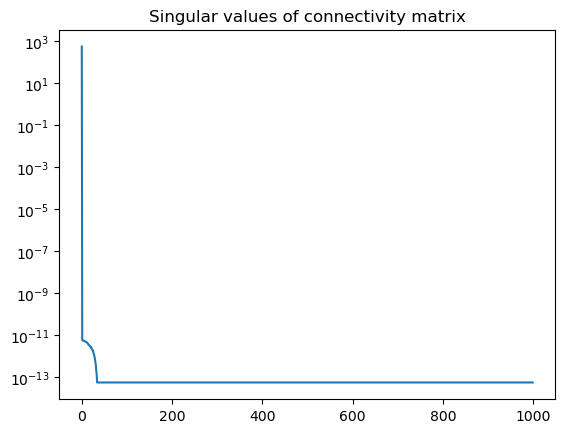

In [2]:
import numpy as np

N=1000
MSH=1

def mean_structure(N, MSH):
    mu = np.linspace(-MSH, MSH, N)
    M = mu[:, None] * np.ones((1, N))
    return M

M = mean_structure(N, MSH)

rank_M = np.linalg.matrix_rank(M)

print(rank_M)

u, s, vt = np.linalg.svd(M)

print(s)

plt.plot(s)
plt.yscale('log')
plt.title("Singular values of connectivity matrix")
plt.show()

# Here I will make an attempt of implementing the FORCE learning method for a rate based recurrent neural network

link to Ingrosso's tutorial: 
https://github.com/WouterKroot/ingrosso_rnn/blob/main/recurrent_force.ipynb 

In [2]:
def euler_rate_network(network, x0, t, W, I, tau, activation):
    x = np.zeros((len(t), len(x0)))
    x[0] = x0
    h = t[1] - t[0]
    for i in range(1, len(t)):
        x[i] = x[i-1] + h*network(activation, x[i-1], W, I[i-1], tau)
    return x

def weight_matrix_fast(p, N, MSH, gain, rng_weights):
    
    mus = np.linspace(-MSH, MSH, N)

    # Generate full matrix of normal random numbers in one call
    W = rng_weights.normal(
        loc=mus[:, None],             # broadcast mus over columns
        scale=gain/np.sqrt(p*N),
        size=(N, N)
    )

    mask = rng_weights.random(W.shape) < p #rng_weights.random generates numbers in [0,1) so this line acts as a filter for introducing sparsity. if p = 1 than no filtering happen because all generated numbers are below 1
    W *= mask
    
    # Remove self-connections
    np.fill_diagonal(W, 0)
    return W

def connection_matrix_fast(p, N, MSH, gain, rng_weights):
    
    mus = np.linspace(-MSH, MSH, N)

    # Generate full matrix of normal random numbers in one call
    J = rng_weights.normal(
        loc=mus[:, None],             # broadcast mus over columns
        scale=1,
        size=(N, N)
    )

    # mask = rng_weights.random(J.shape) < p
    # J *= mask
    # J *= (1/np.sqrt(p*N))
    
    mask = rng_weights.random(J.shape) < p #rng_weights.random generates numbers in [0,1) so this line acts as a filter for introducing sparsity. if p = 1 than no filtering happen because all generated numbers are below 1
    J *= mask
    #J -= J.mean()
    J *= (gain/np.sqrt(p*N))

    #setting diagonal values to 0
    np.fill_diagonal(J, 0)
    
    return J

@njit(fastmath=True)
def rate_network_numba(X, J, I, tau):
    return (-X + J @ np.tanh(X) + I)/tau

@njit(fastmath=True)
def euler_rate_network_numba_full_trajectory(W, tau, dt, t_steps, x0, I):
    N = len(x0)
    x = np.zeros((t_steps, N), dtype=x0.dtype)
    x[0, :] = x0 # Explicitly set the first row

    X = np.copy(x0)

    for i in range(1, t_steps):
        # select input (time varying or constant)
        if I.ndim == 2:
            Ii = I[i-1, :]
        else: 
            Ii = I
        
        X = X + dt * rate_network_numba(X, W, Ii, tau)

        x[i, :] = X # Explicitly assign the 1D array X to the 2D slice x[i, :]

    return x # x is always 2D



def show(name, var):
    try:
        shape = var.shape
    except AttributeError:
        shape = "no .shape attribute"
    try:
        length = len(var)
    except TypeError:
        length = "no len()"
    print(f"{name:10s} | shape: {shape} | len: {length}")


def create_complex_target(running_time, dt, freq=1/60, amps=None):
    """
    Create your complex target function
    
    Args:
        running_time: Time array
        dt: Time step
        freq: Base frequency
        amps: Amplitudes for harmonics [amp1, amp2, ..., amp6]
    """
    if amps is None:
        #amps = [0.3, 0.5, 0.7, 0.2, 0.1, 0.9]
        amps = [0.7, 0.35, 0.1166, 0.2333]
        
    # convertion_ratio = 1000
    # Time = int(len(running_time) * dt)
    # xs = np.arange(0, Time, dt)
    
    freqs = [freq * i for i in range(1, (len(amps)+1))]
    
    #Target = sum(amp * np.sin(2*np.pi*f*xs/convertion_ratio) 
    #             for amp, f in zip(amps, freqs))
    
    Target = sum(amp * np.sin(np.pi*f*running_time)
                 for amp, f in zip(amps, freqs))

    #Sussillo's equivalent way: Target = (amp/1.0)*np.sin(1.0*np.pi*freq*running_time) + (amp/2.0)*np.sin(2.0*np.pi*freq*running_time) + (amp/6.0)*np.sin(3.0*np.pi*freq*running_time) + (amp/3.0)*np.sin(4.0*np.pi*freq*running_time)
   
    Target /= 1.5

    
    return Target

def random_search(param_ranges: Dict[str, Tuple], gain, HSM,
                                   n_iterations: int = 30,
                                   n_trials: int = 3,
                                   train_time: float = 10000,
                                   test_time: float = 5000,
                                   verbose: bool = True):
    """
    Random search over hyperparameters (more efficient than grid search)
    
    Args:
        param_ranges: Dictionary of parameter names to (min, max) tuples
                     e.g., {'eta': (0.01, 0.5), 'alpha': (1.0, 50.0)}
        n_iterations: Number of random configurations to try
        n_trials: Number of trials per configuration
        train_time: Training duration (ms)
        test_time: Testing duration (ms)
        verbose: Print progress
        
    Returns:
        List of result dictionaries sorted by performance
    """
    # Fixed parameters
    N = 1000
    p = 1.0
    #gain = 1.5
    dt = 0.1
    tau = 10.0

    alpha = 1.0
    
    results = []
    
    for i in range(n_iterations):
        # Sample random parameters
        params = {}
        for param_name, (min_val, max_val) in param_ranges.items():
            # if param_name in ['Dt']:
            #     # Sample on log scale for Dt
            #     params[param_name] = 10 ** np.random.uniform(np.log10(min_val), np.log10(max_val))
            # else:
            params[param_name] = np.random.uniform(min_val, max_val)
        
        if verbose:
            print(f"\n{'='*60}")
            print(f"Iteration {i+1}/{n_iterations}: {params}")
            print(f"{'='*60}")
        
        trial_maes = []
        trial_train_maes = []
        
        for trial in range(n_trials):
            # Create trainer
            trainer = FORCETrainer(
                N=N,
                p=p,
                gain=gain,
                HSM=HSM,
                tau=tau,
                dt=dt,
                Dt=params.get('Dt', 2.0),
                #alpha=params.get('alpha', 10.0),
                alpha=alpha,
                eta=params.get('eta', 0.1),
                weights_seed=trial,
                initialisation_seed=trial #can be changed
            )
            
            # Create target
            running_time = np.arange(0, train_time , dt)
            target_train = create_complex_target(running_time, dt)
            
            # Train
            train_results = trainer.train(
                target_train, 
                running_time,
                verbose=False
            )
            
            # Calculate training MAE
            train_mae = np.mean(np.abs(train_results['all_z_out'] - target_train))
            trial_train_maes.append(train_mae)
            
            # Test
            test_running_time = np.arange(0, test_time, dt)
            target_test = create_complex_target(test_running_time, dt)
            test_results = trainer.test(
                target_test,
                test_running_time,
                verbose=False
            )
            
            trial_maes.append(test_results['mae'])
            
            if verbose:
                print(f"  Trial {trial+1}/{n_trials}: Train MAE={train_mae:.6f}, Test MAE={test_results['mae']:.6f}")
        
        result = {
            **params,
            'test_maes': np.array(trial_maes),
            'train_maes': np.array(trial_train_maes),
            'mean_test_mae': np.mean(trial_maes),
            'std_test_mae': np.std(trial_maes),
            'mean_train_mae': np.mean(trial_train_maes),
            'std_train_mae': np.std(trial_train_maes),
            'best_test_mae': np.min(trial_maes),
            'worst_test_mae': np.max(trial_maes)
        }
        results.append(result)
        
        if verbose:
            print(f"  Average: Train={result['mean_train_mae']:.6f}, Test={result['mean_test_mae']:.6f} ± {result['std_test_mae']:.6f}")
    
    # Sort by mean test MAE
    results.sort(key=lambda x: x['mean_test_mae'])
    
    return results


def gains_combined_sorted_FORCE_optimized(foldername):
    # Step 2: Initialize empty lists
    all_Etas = []
    all_Dts = []
    all_Gains = []
    all_mean_mae = []
    all_std_mae = []
    all_Weights_Seeds = []
    #all_Initialisation_Seeds = []
    #all_Bounds = []
    
    # Step 3: Load and append data from each file
    for file in files:
        data = np.load(file)
        all_Etas.extend(data["Etas"])
        all_Dts.extend(data["Dts"])
        all_Gains.extend(data["Gains"])
        all_mean_mae.extend(data["mean_mae"])
        all_std_mae.extend(data["std_mae"])
        all_Weights_Seeds.extend(data["Weights_Seeds"])
        #all_Initialisation_Seeds.extend(data["Initialisation_Seeds"])
        #all_Bounds.extend(data["Bounds"])
        print(f"Loaded {file}: {len(data['Etas'])} entries")
    
    # Step 4: Convert to NumPy arrays
    Etas = np.array(all_Etas)
    Dts = np.array(all_Dts)
    Gains = np.array(all_Gains)
    mean_mae = np.array(all_mean_mae)
    std_mae = np.array(all_std_mae)
    Weights_Seeds = np.array(all_Weights_Seeds)
    #Initialisation_Seeds = np.array(all_Initialisation_Seeds)
    #Bounds = np.array(all_Bounds)
    
    # Step 5: Save combined file
    np.savez("results_combined.npz", Etas=Etas, Dts=Dts, Gains=Gains, mean_mae=mean_mae, std_mae=std_mae, Weights_Seeds=Weights_Seeds)
    #np.savez("results_combined.npz", LLEs=LLEs, Seeds=Seeds, Bounds=Bounds)
    print(f"Saved combined results to 'Optimized_parameters_results_combined.npz'")
    
    # Step 1: Get sorting indices for Seeds
    #sort_idx = np.lexsort((Bounds, Initialisation_Seeds, Weights_Seeds, Gains))
    sort_idx = np.lexsort((Weights_Seeds, Gains))
    
    # Step 2: Apply sorting to all arrays
    Etas_sorted = Etas[sort_idx]
    Dts_sorted = Dts[sort_idx]
    Gains_sorted = Gains[sort_idx]
    mean_mae_sorted = mean_mae[sort_idx]
    std_mae_sorted = std_mae[sort_idx]
    Weights_Seeds_sorted = Weights_Seeds[sort_idx]
    #Initialisation_Seeds_sorted = Initialisation_Seeds[sort_idx]
    #Bounds_sorted = Bounds[sort_idx]

    return Etas_sorted, Dts_sorted, Gains_sorted, mean_mae_sorted, std_mae_sorted, Weights_Seeds_sorted


def manually_combine_individual_results(foldername):
    """
    Manually combine individual result_*.npz files
    (use this if the cluster script didn't auto-combine)
    """
    import glob
    import os
    
    # Find all result files
    pattern = os.path.join(foldername, "result_*.npz")
    result_files = glob.glob(pattern)
    
    print(f"Found {len(result_files)} result files in {foldername}")
    
    if len(result_files) == 0:
        print("No result files found!")
        return None
    
    # Collect all results
    all_etas = []
    all_Dts = []
    all_gains = []
    all_MSHs = []
    all_seeds = []
    all_mean_maes = []
    all_std_maes = []
    
    for filepath in result_files:
        try:
            data = np.load(filepath)
            all_etas.append(float(data['eta']))
            all_Dts.append(float(data['Dt']))
            all_gains.append(float(data['gain']))
            all_MSHs.append(float(data['MSH']))
            all_seeds.append(int(data['weights_seed']))
            all_mean_maes.append(float(data['mean_test_mae']))
            all_std_maes.append(float(data['std_test_mae']))
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
    
    # Convert to arrays
    all_etas = np.array(all_etas)
    all_Dts = np.array(all_Dts)
    all_gains = np.array(all_gains)
    all_MSHs = np.array(all_MSHs)
    all_seeds = np.array(all_seeds)
    all_mean_maes = np.array(all_mean_maes)
    all_std_maes = np.array(all_std_maes)
    
    # Sort by Gain → MSH → Seed
    sort_idx = np.lexsort((all_seeds, all_MSHs, all_gains))
    
    results = {
        'Etas': all_etas[sort_idx],
        'Dts': all_Dts[sort_idx],
        'Gains': all_gains[sort_idx],
        'MSHs': all_MSHs[sort_idx],
        'Weights_Seeds': all_seeds[sort_idx],
        'mean_maes': all_mean_maes[sort_idx],
        'std_maes': all_std_maes[sort_idx]
    }
    
    # Save
    output_path = os.path.join(foldername, "results_combined_sorted.npz")
    np.savez(output_path, **results)
    print(f"Saved combined results to {output_path}")
    
    return results

def load_combined_FORCE_results(foldername):
    """
    Load the already-combined and sorted results file
    
    Args:
        foldername: Folder containing results_combined_sorted.npz
        
    Returns:
        Dictionary with sorted arrays
    """
    import os
    
    filepath = os.path.join(foldername, "results_combined_sorted.npz")
    
    if not os.path.exists(filepath):
        raise FileError(f"Combined results file not found: {filepath}")
    
    data = np.load(filepath)
    
    results = {
        'Etas': data['Etas'],
        'Dts': data['Dts'],
        'Gains': data['Gains'],
        'MSHs': data['MSHs'],
        'Weights_Seeds': data['Weights_Seeds'],
        'mean_maes': data['mean_maes'],
        'std_maes': data['std_maes']
    }
    
    print(f"Loaded {len(results['Etas'])} entries from {filepath}")
    print(f"  Gains range: {results['Gains'].min():.1f} - {results['Gains'].max():.1f}")
    print(f"  MSHs range: {results['MSHs'].min():.1f} - {results['MSHs'].max():.1f}")
    
    return results


def merge_summary_files(folder_path, filename, name_Rsquareds_type, output_path = None, output_filename=None):
    """
    Merge multiple summary .npz files, ensuring correct parameter coupling and removing duplicates.
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing summary files
    filename : str
        name of the file, e.g. : filename = "first_period_test_Rsquared_summary_*.npz"
    name_Rsquareds_type : str
        name of type of R^2, e.g. : name_Rsquareds_type = 'first_period_test_Rsquareds'
        
    output_filename : str, optional
        Name for merged output file. If None, generates timestamp-based name.
    
    Returns:
    --------
    str : Path to merged summary file
    """

    if output_path is None:
        output_path = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\merged files"

    
    # Find all summary files
    pattern = os.path.join(folder_path, filename)
    summary_files = glob.glob(pattern)
    
    if len(summary_files) == 0:
        raise ValueError(f"No summary files found in {folder_path}")
    
    print(f"Found {len(summary_files)} summary files to merge:")
    for f in summary_files:
        print(f"  - {os.path.basename(f)}")
    
    # Lists to collect all data
    all_Rsquareds = []
    all_gains = []
    all_MSHs = []
    all_weights_seeds = []
    
    # These should be the same across all files
    etas_value = None
    Dts_value = None
    
    # Load and concatenate all files
    for filepath in summary_files:
        data = np.load(filepath)
        
        # Get the parameter arrays from this file
        file_gains = data['gains']
        file_MSHs = data['MSHs']
        file_weights_seeds = data['weights_seeds']
        file_Rsquareds = data[name_Rsquareds_type]
        
        # Store eta and Dt (should be same across all files)
        if etas_value is None:
            etas_value = data['etas']
            Dts_value = data['Dts']
        
        # Reconstruct the parameter combinations
        # The order matches: product(gains, weight_seeds, MSHs)
        for gain in file_gains:
            for weight_seed in file_weights_seeds:
                for msh in file_MSHs:
                    all_gains.append(gain)
                    all_weights_seeds.append(weight_seed)
                    all_MSHs.append(msh)
        
        # The Rsquareds are already in the correct flattened order
        all_Rsquareds.extend(file_Rsquareds)
    
    # Convert to numpy arrays
    all_Rsquareds = np.array(all_Rsquareds)
    all_gains = np.array(all_gains)
    all_MSHs = np.array(all_MSHs)
    all_weights_seeds = np.array(all_weights_seeds)
    
    print(f"\nTotal configurations before deduplication: {len(all_Rsquareds)}")
    
    # Remove duplicates based on (gain, MSH, weight_seed)
    unique_configs = {}
    
    for i in range(len(all_gains)):
        # Create key from parameters (rounded for floating point comparison)
        config_key = (
            round(all_gains[i], 6),
            round(all_MSHs[i], 6),
            int(all_weights_seeds[i])
        )
        
        # Keep first occurrence of each unique configuration
        if config_key not in unique_configs:
            unique_configs[config_key] = i
    
    # Get indices of unique configurations
    unique_indices = sorted(unique_configs.values())
    
    duplicate_count = len(all_Rsquareds) - len(unique_indices)
    if duplicate_count > 0:
        print(f"  Removed {duplicate_count} duplicate configurations")
    
    # Extract unique configurations
    all_Rsquareds = all_Rsquareds[unique_indices]
    all_gains = all_gains[unique_indices]
    all_MSHs = all_MSHs[unique_indices]
    all_weights_seeds = all_weights_seeds[unique_indices]
    
    print(f"Total configurations after deduplication: {len(all_Rsquareds)}")
    
    # Create sorting key: primary by gain, secondary by MSH, tertiary by weight_seed
    sort_indices = np.lexsort((all_weights_seeds, all_MSHs, all_gains))
    
    # Apply sorting to all arrays
    all_Rsquareds_sorted = all_Rsquareds[sort_indices]
    all_gains_sorted = all_gains[sort_indices]
    all_MSHs_sorted = all_MSHs[sort_indices]
    all_weights_seeds_sorted = all_weights_seeds[sort_indices]
    
    # Print summary statistics
    print(f"\nMerged data summary:")
    print(f"  Total unique configurations: {len(all_Rsquareds_sorted)}")
    print(f"  Unique gains: {len(np.unique(all_gains_sorted))} values from {np.min(all_gains_sorted):.2f} to {np.max(all_gains_sorted):.2f}")
    print(f"  Unique MSHs: {len(np.unique(all_MSHs_sorted))} values from {np.min(all_MSHs_sorted):.2f} to {np.max(all_MSHs_sorted):.2f}")
    print(f"  Unique etas: {etas_value}")
    print(f"  Unique Dts: {Dts_value}")
    print(f"  Unique weight_seeds: {np.unique(all_weights_seeds_sorted)}")
    
    # Generate output filename
    if output_filename is None:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        output_filename = f"{name_Rsquareds_type}_merged_{timestamp}.npz"
    
    output_filepath = os.path.join(output_path, output_filename)
    
    # Save merged and sorted data
    np.savez(
        output_filepath,
        **{name_Rsquareds_type: all_Rsquareds_sorted},
        gains=all_gains_sorted,
        MSHs=all_MSHs_sorted,
        etas=etas_value,
        Dts=Dts_value,
        weights_seeds=all_weights_seeds_sorted
    )
    
    print(f"\n✓ Saved merged summary to: {output_filepath}")
    
    # Verification: print first few and last few entries
    print("\nFirst 5 configurations (sorted by gain, then MSH, then weight_seed):")
    for i in range(min(5, len(all_gains_sorted))):
        print(f"  G={all_gains_sorted[i]:.3f}, MSH={all_MSHs_sorted[i]:.3f}, "
              f"W={all_weights_seeds_sorted[i]}, R²={all_Rsquareds_sorted[i]:.6f}")
    
    print("\nLast 5 configurations:")
    for i in range(max(0, len(all_gains_sorted)-5), len(all_gains_sorted)):
        print(f"  G={all_gains_sorted[i]:.3f}, MSH={all_MSHs_sorted[i]:.3f}, "
              f"W={all_weights_seeds_sorted[i]}, R²={all_Rsquareds_sorted[i]:.6f}")
    
    return output_filepath

# def merge_summary_files(folder_path, filename, name_Rsquareds_type, output_path=None, output_filename=None):
#     """
#     Merge multiple summary .npz files, ensuring correct parameter coupling and removing duplicates.
    
#     Parameters:
#     -----------
#     folder_path : str
#         Path to folder containing summary files
#     filename : str
#         name of the file, e.g. : filename = "first_period_test_Rsquared_summary_*.npz"
#     name_Rsquareds_type : str
#         name of type of R^2, e.g. : name_Rsquareds_type = 'first_period_test_Rsquareds'
#     output_path : str, optional
#         Path where to save merged file. If None, uses folder_path
#     output_filename : str, optional
#         Name for merged output file. If None, generates timestamp-based name.
    
#     Returns:
#     --------
#     str : Path to merged summary file
#     """
    
#     if output_path is None:
#         output_path = folder_path
    
#     # Find all summary files
#     pattern = os.path.join(folder_path, filename)
#     summary_files = glob.glob(pattern)
    
#     if len(summary_files) == 0:
#         raise ValueError(f"No summary files found in {folder_path}")
    
#     print(f"Found {len(summary_files)} summary files to merge:")
#     for f in summary_files:
#         print(f"  - {os.path.basename(f)}")
    
#     # Lists to collect all data
#     all_Rsquareds = []
#     all_gains = []
#     all_MSHs = []
#     all_weights_seeds = []
    
#     # These should be the same across all files
#     etas_value = None
#     Dts_value = None
    
#     # Load and concatenate all files
#     for filepath in summary_files:
#         data = np.load(filepath)
        
#         # Get the parameter arrays from this file
#         file_gains = data['gains']
#         file_MSHs = data['MSHs']
#         file_weights_seeds = data['weights_seeds']
#         file_Rsquareds = data[name_Rsquareds_type]
        
#         print(f"\nProcessing {os.path.basename(filepath)}:")
#         print(f"  gains: {len(file_gains)} values")
#         print(f"  MSHs: {len(file_MSHs)} values")
#         print(f"  weight_seeds: {len(file_weights_seeds)} values")
#         print(f"  Rsquareds: {len(file_Rsquareds)} values")
        
#         # Store eta and Dt (should be same across all files)
#         if etas_value is None:
#             etas_value = data['etas']
#             Dts_value = data['Dts']
        
#         # Calculate expected number of combinations
#         expected_combinations = len(file_gains) * len(file_weights_seeds) * len(file_MSHs)
#         print(f"  Expected combinations: {expected_combinations}")
        
#         # Check if the R² array length matches expectations
#         if len(file_Rsquareds) != expected_combinations:
#             raise ValueError(
#                 f"Mismatch in {os.path.basename(filepath)}: "
#                 f"Expected {expected_combinations} R² values "
#                 f"({len(file_gains)} gains × {len(file_weights_seeds)} seeds × {len(file_MSHs)} MSHs), "
#                 f"but found {len(file_Rsquareds)}"
#             )
        
#         # Reconstruct the parameter combinations
#         # The order matches: product(gains, weight_seeds, MSHs)
#         idx = 0
#         for gain in file_gains:
#             for weight_seed in file_weights_seeds:
#                 for msh in file_MSHs:
#                     all_gains.append(gain)
#                     all_weights_seeds.append(weight_seed)
#                     all_MSHs.append(msh)
#                     all_Rsquareds.append(file_Rsquareds[idx])
#                     idx += 1
    
#     # Convert to numpy arrays
#     all_Rsquareds = np.array(all_Rsquareds)
#     all_gains = np.array(all_gains)
#     all_MSHs = np.array(all_MSHs)
#     all_weights_seeds = np.array(all_weights_seeds)
    
#     print(f"\n{'='*60}")
#     print(f"Total configurations before deduplication: {len(all_Rsquareds)}")
#     print(f"  all_gains: {len(all_gains)}")
#     print(f"  all_MSHs: {len(all_MSHs)}")
#     print(f"  all_weights_seeds: {len(all_weights_seeds)}")
#     print(f"  all_Rsquareds: {len(all_Rsquareds)}")
    
#     # Verify all arrays have the same length
#     if not (len(all_Rsquareds) == len(all_gains) == len(all_MSHs) == len(all_weights_seeds)):
#         raise ValueError("Array length mismatch after loading files!")
    
#     # Remove duplicates based on (gain, MSH, weight_seed)
#     unique_configs = {}
    
#     for i in range(len(all_gains)):
#         # Create key from parameters (rounded for floating point comparison)
#         config_key = (
#             round(all_gains[i], 6),
#             round(all_MSHs[i], 6),
#             int(all_weights_seeds[i])
#         )
        
#         # Keep first occurrence of each unique configuration
#         if config_key not in unique_configs:
#             unique_configs[config_key] = i
    
#     # Get indices of unique configurations
#     unique_indices = sorted(unique_configs.values())
    
#     duplicate_count = len(all_Rsquareds) - len(unique_indices)
#     if duplicate_count > 0:
#         print(f"  Removed {duplicate_count} duplicate configurations")
    
#     # Extract unique configurations
#     all_Rsquareds = all_Rsquareds[unique_indices]
#     all_gains = all_gains[unique_indices]
#     all_MSHs = all_MSHs[unique_indices]
#     all_weights_seeds = all_weights_seeds[unique_indices]
    
#     print(f"Total configurations after deduplication: {len(all_Rsquareds)}")
    
#     # Create sorting key: primary by gain, secondary by MSH, tertiary by weight_seed
#     sort_indices = np.lexsort((all_weights_seeds, all_MSHs, all_gains))
    
#     # Apply sorting to all arrays
#     all_Rsquareds_sorted = all_Rsquareds[sort_indices]
#     all_gains_sorted = all_gains[sort_indices]
#     all_MSHs_sorted = all_MSHs[sort_indices]
#     all_weights_seeds_sorted = all_weights_seeds[sort_indices]
    
#     # Print summary statistics
#     print(f"\n{'='*60}")
#     print(f"Merged data summary:")
#     print(f"  Total unique configurations: {len(all_Rsquareds_sorted)}")
#     print(f"  Unique gains: {len(np.unique(all_gains_sorted))} values from {np.min(all_gains_sorted):.2f} to {np.max(all_gains_sorted):.2f}")
#     print(f"  Unique MSHs: {len(np.unique(all_MSHs_sorted))} values from {np.min(all_MSHs_sorted):.2f} to {np.max(all_MSHs_sorted):.2f}")
#     print(f"  Unique etas: {etas_value}")
#     print(f"  Unique Dts: {Dts_value}")
#     print(f"  Unique weight_seeds: {np.unique(all_weights_seeds_sorted)}")
    
#     # Generate output filename
#     if output_filename is None:
#         timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#         output_filename = f"{name_Rsquareds_type}_merged_{timestamp}.npz"
    
#     output_filepath = os.path.join(output_path, output_filename)
    
#     # Save merged and sorted data
#     np.savez(
#         output_filepath,
#         **{name_Rsquareds_type: all_Rsquareds_sorted},
#         gains=all_gains_sorted,
#         MSHs=all_MSHs_sorted,
#         etas=etas_value,
#         Dts=Dts_value,
#         weights_seeds=all_weights_seeds_sorted
#     )
    
#     print(f"\n✓ Saved merged summary to: {output_filepath}")
    
#     # Verification: print first few and last few entries
#     print("\nFirst 5 configurations (sorted by gain, then MSH, then weight_seed):")
#     for i in range(min(5, len(all_gains_sorted))):
#         print(f"  G={all_gains_sorted[i]:.3f}, MSH={all_MSHs_sorted[i]:.3f}, "
#               f"W={all_weights_seeds_sorted[i]}, R²={all_Rsquareds_sorted[i]:.6f}")
    
#     print("\nLast 5 configurations:")
#     for i in range(max(0, len(all_gains_sorted)-5), len(all_gains_sorted)):
#         print(f"  G={all_gains_sorted[i]:.3f}, MSH={all_MSHs_sorted[i]:.3f}, "
#               f"W={all_weights_seeds_sorted[i]}, R²={all_Rsquareds_sorted[i]:.6f}")
    
#     return output_filepath

def create_averages_performance_files(folder_path, MSHs, gains, Dt=0.2, eta=1, n_weight_seeds=np.array([9]), output_filename=None):
    """
    Uses idx* individual .npz files, and merges them into two summary files for averages during and after training
    ensuring correct parameter coupling and removing duplicates.
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing individual result files
    MSHs : array
        Array of MSH values used in the experiment
    gains : array
        Array of gain values used in the experiment
    Dt : float
        Delta t parameter
    eta : float
        Eta parameter
    n_weight_seeds : array
        Array of weight seeds used
    output_filename : str, optional
        Name for merged output file. If None, generates timestamp-based name.
    
    Returns:
    --------
    tuple : Paths to (training summary file, testing summary file)
    """
    
    # Get all idx*.npz files
    files = glob.glob(os.path.join(folder_path, "idx*.npz"))
    
    if len(files) == 0:
        raise ValueError(f"No idx*.npz files found in {folder_path}")
    
    # Sorting them by idx number
    files.sort(key=lambda f: int(os.path.basename(f).split('_')[0][3:]))
    
    print(f"Found {len(files)} individual result files")
    
    averages_train_Rsquared = []
    averages_test_Rsquared = []
    
    for i, filepath in enumerate(files):
        data = np.load(filepath)
        
        # Process training R²
        Rsquareds_train = data['Rsquareds_train']
        
        if len(Rsquareds_train) > 0:
            Rsquared_average_train = np.mean(Rsquareds_train)
            averages_train_Rsquared.append(Rsquared_average_train)
        else:
            print(f"  Warning [{i}]: No complete periods in train data for {os.path.basename(filepath)}")
            Rsquared_average_train = np.nan
            averages_train_Rsquared.append(Rsquared_average_train)
        
        # Process testing R²
        Rsquareds_test = data['Rsquareds_test_all_periods']
        
        if len(Rsquareds_test) > 0:
            Rsquared_average_test = np.mean(Rsquareds_test)
            averages_test_Rsquared.append(Rsquared_average_test)
        else:
            print(f"  Warning [{i}]: No complete periods in test data for {os.path.basename(filepath)}")
            Rsquared_average_test = np.nan
            averages_test_Rsquared.append(Rsquared_average_test)  # ✓ FIX: Added this line!
    
    print(f"\nCollected {len(averages_train_Rsquared)} training averages")
    print(f"Collected {len(averages_test_Rsquared)} testing averages")
    
    # Calculate expected number based on parameter combinations
    expected_count = len(gains) * len(n_weight_seeds) * len(MSHs)
    print(f"Expected: {expected_count} = {len(gains)} gains × {len(n_weight_seeds)} seeds × {len(MSHs)} MSHs")
    
    if len(averages_train_Rsquared) != expected_count:
        print(f"WARNING: Mismatch between number of files ({len(files)}) and expected combinations ({expected_count})")
    
    # Save training averages summary
    summary_averages_during_training_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\summaries_averages",
        f"summary_averages_during_training_filepath_MSHs={MSHs}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")
    
    np.savez(
        summary_averages_during_training_filepath,
        averages_training_Rsquareds=np.array(averages_train_Rsquared),
        gains=gains,
        MSHs=MSHs,
        etas=eta,
        Dts=Dt,
        weights_seeds=n_weight_seeds)
    
    print(f"\n✓ Saved training summary to: {os.path.basename(summary_averages_during_training_filepath)}")
    
    # Save testing averages summary
    summary_averages_after_training_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\summaries_averages",
        f"summary_averages_after_training_filepath_MSHs={MSHs}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")
    
    np.savez(
        summary_averages_after_training_filepath,
        averages_testing_Rsquareds=np.array(averages_test_Rsquared),
        gains=gains,
        MSHs=MSHs,
        etas=eta,
        Dts=Dt,
        weights_seeds=n_weight_seeds)
    
    print(f"✓ Saved testing summary to: {os.path.basename(summary_averages_after_training_filepath)}")
    
    return summary_averages_during_training_filepath, summary_averages_after_training_filepath

# Steps to take:

RLS-FORCE is derived from the following cost function:

$$C = \sum^1_{k=0} \frac{1}{2}e^2_{(k)} = \sum^1_{k=0} \frac{1}{2}(f^{target}_{(k)} - (\vec{W}^{out})^T\vec{r}_{(k)})^2 + \frac{\alpha}{2}||\vec{W}^{out}||^2$$

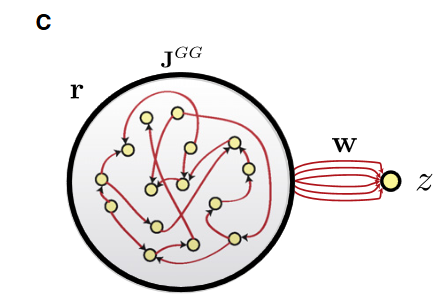

1. $z(t) = \vec{w}^T\vec{r}(t)$, readout unit $z(t)$ at time $t$, which is the weights coming from the network to the output neurons times the activation functions of the neurons in the network to the output. 

In first-order reduced and controlled error or FORCE learning you hold the feedback signal close to its desired value. Because the method requires tight control of a small (first-order) error. A learning algorithm that is suitable FORCE learning has to rapidly reduce the magnitude of the difference between the actual and desired output to a small value, and keep it small while searching for and eventually finding a set of fixed readout weights that can maintain a small error without further modification. 

2. $e_-(t) = \vec{w}^T(t-\Delta t)\vec{r}(t) - f(t)$, is the error between readout unit $z(t-\Delta t)$ and the target output $f(t)$ before the weight update or at the previous weight update (i.e. interval time $\Delta t$ the weight gets updated) the weight gets updated.
 
Then the error gets calculated again at time $t$ which is at the next weight update time interval $\Delta t$ (i.e. $t-\Delta t + \Delta t = t$)

3. $e_+(t) = \vec{w}(t)\vec{r}(t) - f(t)$

It needs to be the case that:

4. $|e_+(t)|<|e_-(t)|$, in order to let the system learn to become closer to the target output $f(t)$

Eventually over time we want to achieve that the $e_+(t)$ and $e_-(t)$ are the same, so that the learning can stop, i.e.:

5. $\frac{e_+(t)}{e_-(t)} \rightarrow 1$

FORCE learning is unusual in that the magnitudes of these errors are small throughout the learning process, although similarly reduced over time. This is done by making a large reduction in size at the time of the first weight update and then maintaining small error throughout the trianing while slowly decreasing over time. 

To do this they use the recursive least-squares (RLS) algorithm (could use different algorithms)

6. $\vec{w}(t) = \vec{w}(t - \Delta t) - e_-(t)\vec{P}(t)\vec{r}(t)$

7. 
with $\vec{P}(t)$ (a matrix with multiple learning rates) being a NxN matrix that is updated at the same time as the weights according to the rule:

8. $\vec{P}(t) = \vec{P}(t - \Delta t) -  \frac{\vec{P}(t- \Delta t) \vec{r}(t) \vec{r}^T(t) \vec{P}(t- \Delta t)}{1 + \vec{r}^T(t) \vec{P}(t- \Delta t) \vec{r}(t)}$

Which is initialized by the value:

9. $\vec{P}(0) = \frac{\vec{I}}{\alpha}$, with $\vec{I}$ being the identity matrix and $\alpha$ is a constant parameter.

$\vec{P}$ is a running estimate of the inverse of the correlation matrix of the network rates $\vec{r}$ plus a regularization terms:

10. $\vec{P} = (\sum_t \vec{r}(t)\vec{r}^T(t) + \alpha \vec{I})^{-1}$



## New update rules accroding to research guide B2

1. for outgoing weights from J to z:
$$\mathbf{w}(t) = \mathbf{w}(t - \Delta t) -  \frac{\mathbf{P}(t) \mathbf{r}(t) e^T_-(t)}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$

2. Correlation matrix update stays the same
$$\mathbf{P}(t) = \mathbf{P}(t - \Delta t) -  \frac{\mathbf{P}(t- \Delta t) \mathbf{r}(t) \mathbf{r}^T(t) \mathbf{P}(t- \Delta t)}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$

3. Update rule for generator network or reservoir RNN connection matrix J: 
$$\mathbf{J}_{GG}(t) = \mathbf{J}_{GG}(t - \Delta t) - \frac{\mathbf{1}_{N \times M} e_-(t) \mathbf{r}^T(t) \mathbf{P}(t)}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$

3.1 Corrected version of update rule 3.:
$$\mathbf{J}_{GG}(t) = \mathbf{J}_{GG}(t - \Delta t) - \frac{\mathbf{P}(t) \mathbf{r}(t) e_-^T(t) \mathbf{1}_{M \times N}}{1 + \mathbf{r}^T(t) \mathbf{P}(t- \Delta t) \mathbf{r}(t)}$$


# FORCE trainer class

In [6]:
class FORCETrainer:
    """
    FORCE trainer using YOUR update rule and parameters
    Optimizes over: eta, alpha, Dt, tau
    """
    
    def __init__(self, N=1000, p=1.0, gain=1.5, HSM=0, 
                 tau=1, dt=0.1, Dt=2.0, alpha=1.0, eta=0.1,
                 weights_seed=1, initialisation_seed=1):
        """
        Initialize with your original parameters
        
        Args:
            N: Number of neurons
            p: Connection probability
            gain: Gain parameter
            HSM: Mean shift for connection matrix
            tau: Time constant (ms) - OPTIMIZE THIS
            dt: Integration time step (ms)
            Dt: Learning update interval (ms) - OPTIMIZE THIS
            alpha: RLS forgetting factor - OPTIMIZE THIS
            eta: Learning rate for J updates - OPTIMIZE THIS
            weights_seed: Seed for weight initialization
            initialisation_seed: Seed for state initialization
        """
        self.N = N
        self.p = p
        self.gain = gain
        self.HSM = HSM
        self.tau = tau
        self.dt = dt
        self.Dt = Dt
        self.alpha = alpha
        self.eta = eta
        
        # Initialize random number generators
        weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed))
        initialisation_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed, initialisation_seed))
        #initialisation_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, initialisation_seed))
        self.rng_weights = np.random.default_rng(weights_seq)
        self.rng_initialisation = np.random.default_rng(initialisation_seq)
        
        # Initialize network
        self._init_network()
    
    def _init_network(self):
        """Initialize network weights and state - your original method"""
        #self.J = connection_matrix_fast(self.p, self.N, self.HSM, self.gain, self.rng_weights)
        self.J = weight_matrix_fast(self.p, self.N, self.HSM, self.gain, self.rng_weights)
        self.I = np.zeros((self.N, 1))
        self.x = 0.5 * self.rng_initialisation.normal(0, 1, size=(self.N, 1))
        self.r = np.tanh(self.x)
        
        # Readout weights
        self.w_out = self.rng_initialisation.normal(loc=0, scale=1/(np.sqrt(self.p*self.N)), size=(self.N, 1))
        mask = self.rng_initialisation.random(self.w_out.shape) < self.p
        self.w_out *= mask
        self.w_out -= self.w_out.mean()
        self.w_out *= (1/(np.sqrt(self.p*self.N)))

        # self.w_out = self.rng_initialisation.normal(loc=0, scale=1/(np.sqrt(0.1*self.N)), size=(self.N, 1))
        # mask = self.rng_initialisation.random(self.w_out.shape) < 0.1
        # self.w_out *= mask
        # self.w_out -= self.w_out.mean()
        # self.w_out *= (1/(np.sqrt(0.1*self.N)))
        
        # RLS matrix
        self.P = np.identity(self.N) / self.alpha

        #to save initial copies
        self.J_initial = self.J.copy()
        self.w_out_initial = self.w_out.copy()

    
    def train(self, target, running_time, learn_start=500, verbose=True):
    # def train(self, target, running_time, learn_start=500, 
    #           J_train_end=15000, w_train_end=30000, verbose=True):
        
        """
        Train network using FORCE learning - your original structure
        
        Args:
            target: Target signal array
            running_time: Time array (ms)
            learn_start: When to start learning (ms)
            J_train_end: When to stop J learning (ms)
            w_train_end: When to stop w_out learning (ms)
            verbose: Show progress bar
            
        Returns:
            dict with training results
        """
        total_time_steps = len(running_time)
        self.total_time_steps = total_time_steps
        
        learn_every = int(self.Dt / self.dt)
        learn_start_idx = int(learn_start / self.dt)
        #J_train_end_idx = int(J_train_end / self.dt)
        #w_train_end_idx = int(w_train_end / self.dt)
        
        # Storage
        z_out = []
        z_time = []
        all_z_out = []
        
        # State
        x = self.x.copy()
        r = self.r.copy()
        J = self.J.copy()
        w_out = self.w_out.copy()
        P = self.P.copy()
 
        iterator = tqdm(range(total_time_steps)) if verbose else range(total_time_steps)
        
        for t in iterator:
            # YOUR ORIGINAL UPDATE RULE
            x += (self.dt / self.tau) * (-x + J @ r + self.I)
            r = np.tanh(x)
            
            # Compute output at every step
            z = (w_out.T @ r)[0, 0]
            # z = (w_out.T @ r)
            
            all_z_out.append(z)
            
            # Learning updates
            if t >= learn_start_idx and t % learn_every == 0:
                # Error (keep as array for proper broadcasting)
                target_idx = t - learn_start_idx

                # Safety check (important!)
                if target_idx < len(target):
                    e_min = z - target[target_idx]#to let the target start at the same time as the learning
                    e_min_arr = np.array([[e_min]])  # Shape (1, 1)
                    
                    # RLS update
                    Pr = P @ r  # Shape (N, 1)
                    rTPr = (r.T @ Pr)[0, 0]
                    normalizer = 1.0 / (1.0 + rTPr)
                    
                    # Update readout weights
                
                    delta_w = -normalizer * (Pr * e_min)  # Shape (N, 1)
                    # maybe: delta_w = -normalizer * (Pr @ e_min.T)
                    
                    w_out += delta_w
                    
                    # Update P matrix
                    P -= normalizer * (Pr @ Pr.T)
                    
                    # Update internal weights with eta
                    
                    J += self.eta * (np.ones((self.N, 1)) @ delta_w.T)
    
                    
                    # z_out.append(z)
                    # z_time.append(running_time[t])
        
        # Store trained parameters
        self.J_trained = J.copy()
        self.w_out_trained = w_out.copy()
        self.x_final = x.copy()
        self.r_final = r.copy()
        
        return {
            # 'z_out': np.array(z_out),
            # 'z_time': np.array(z_time),
            'all_z_out': np.array(all_z_out),
            'running_time': running_time,
            'total_time_steps': total_time_steps
        }
    
    def test(self, target, test_time, from_final_state=True, verbose=True):
        """
        Test trained network
        
        Args:
            target: Target signal for testing
            test_time: Time array for testing
            from_final_state: Start from final training state (True) or random (False)
            verbose: Show progress bar
        """
        # Initialize state
        if from_final_state:
            x_test = self.x_final.copy()
            r_test = self.r_final.copy()
        else:
            x_test = 0.5 * self.rng_initialisation.normal(size=(self.N, 1))
            r_test = np.tanh(x_test)
        
        z_tests = []
        
        iterator = tqdm(range(len(test_time))) if verbose else range(len(test_time))
        
        for i in iterator:
            # YOUR ORIGINAL UPDATE RULE
            x_test += (self.dt / self.tau) * (-x_test + self.J_trained @ r_test + self.I)
            r_test = np.tanh(x_test)
            
            z_test = (self.w_out_trained.T @ r_test)[0, 0]
            z_tests.append(z_test)
        
        z_tests = np.array(z_tests)
        mae = np.mean(np.abs(z_tests - target[:len(z_tests)]))
        
        return {
            'z_out': z_tests,
            'test_time': test_time,
            'mae': mae
        }


# Training and testing with eta = 1 and Dt = 0.2 

## For running big blocks for the heatmap

In [30]:
MSHs = np.arange(0, 5.2, 0.2)
print(MSHs)
print(len(MSHs))
gains = np.arange(0, 10.2, 0.2)
print(gains)
print(len(gains))

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5. ]
26
[ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10. ]
51


In [13]:
MSHs = np.arange(2.6, 4.2, 0.2)
#MSHs = np.arange(3.6, 4.6, 0.2)
print(MSHs)


[2.6 2.8 3.  3.2 3.4 3.6 3.8 4. ]


In [21]:
initialisation_seed = np.array([0])
print(initialisation_seed[0])

0


  gain=1.4, weights_seed=9, MSH=0.01


100%|██████████| 14400/14400 [00:06<00:00, 2116.26it/s]


  First period train R^2: 0.996609
  Average train R^2: 0.945177
  First period test R^2: -1.257556
  Average test R^2: -0.958389
✓ Saved to: idx000_gain1.4_MSH0.01_w_seed9_i_seed0_20260325_120919.npz
  gain=1.4, weights_seed=9, MSH=0.005


100%|██████████| 14400/14400 [00:06<00:00, 2269.43it/s]


  First period train R^2: 0.999583
  Average train R^2: 0.998568
  First period test R^2: 0.994329
  Average test R^2: 0.997173
✓ Saved to: idx001_gain1.4_MSH0.005_w_seed9_i_seed0_20260325_121202.npz


NameError: name 'gains' is not defined

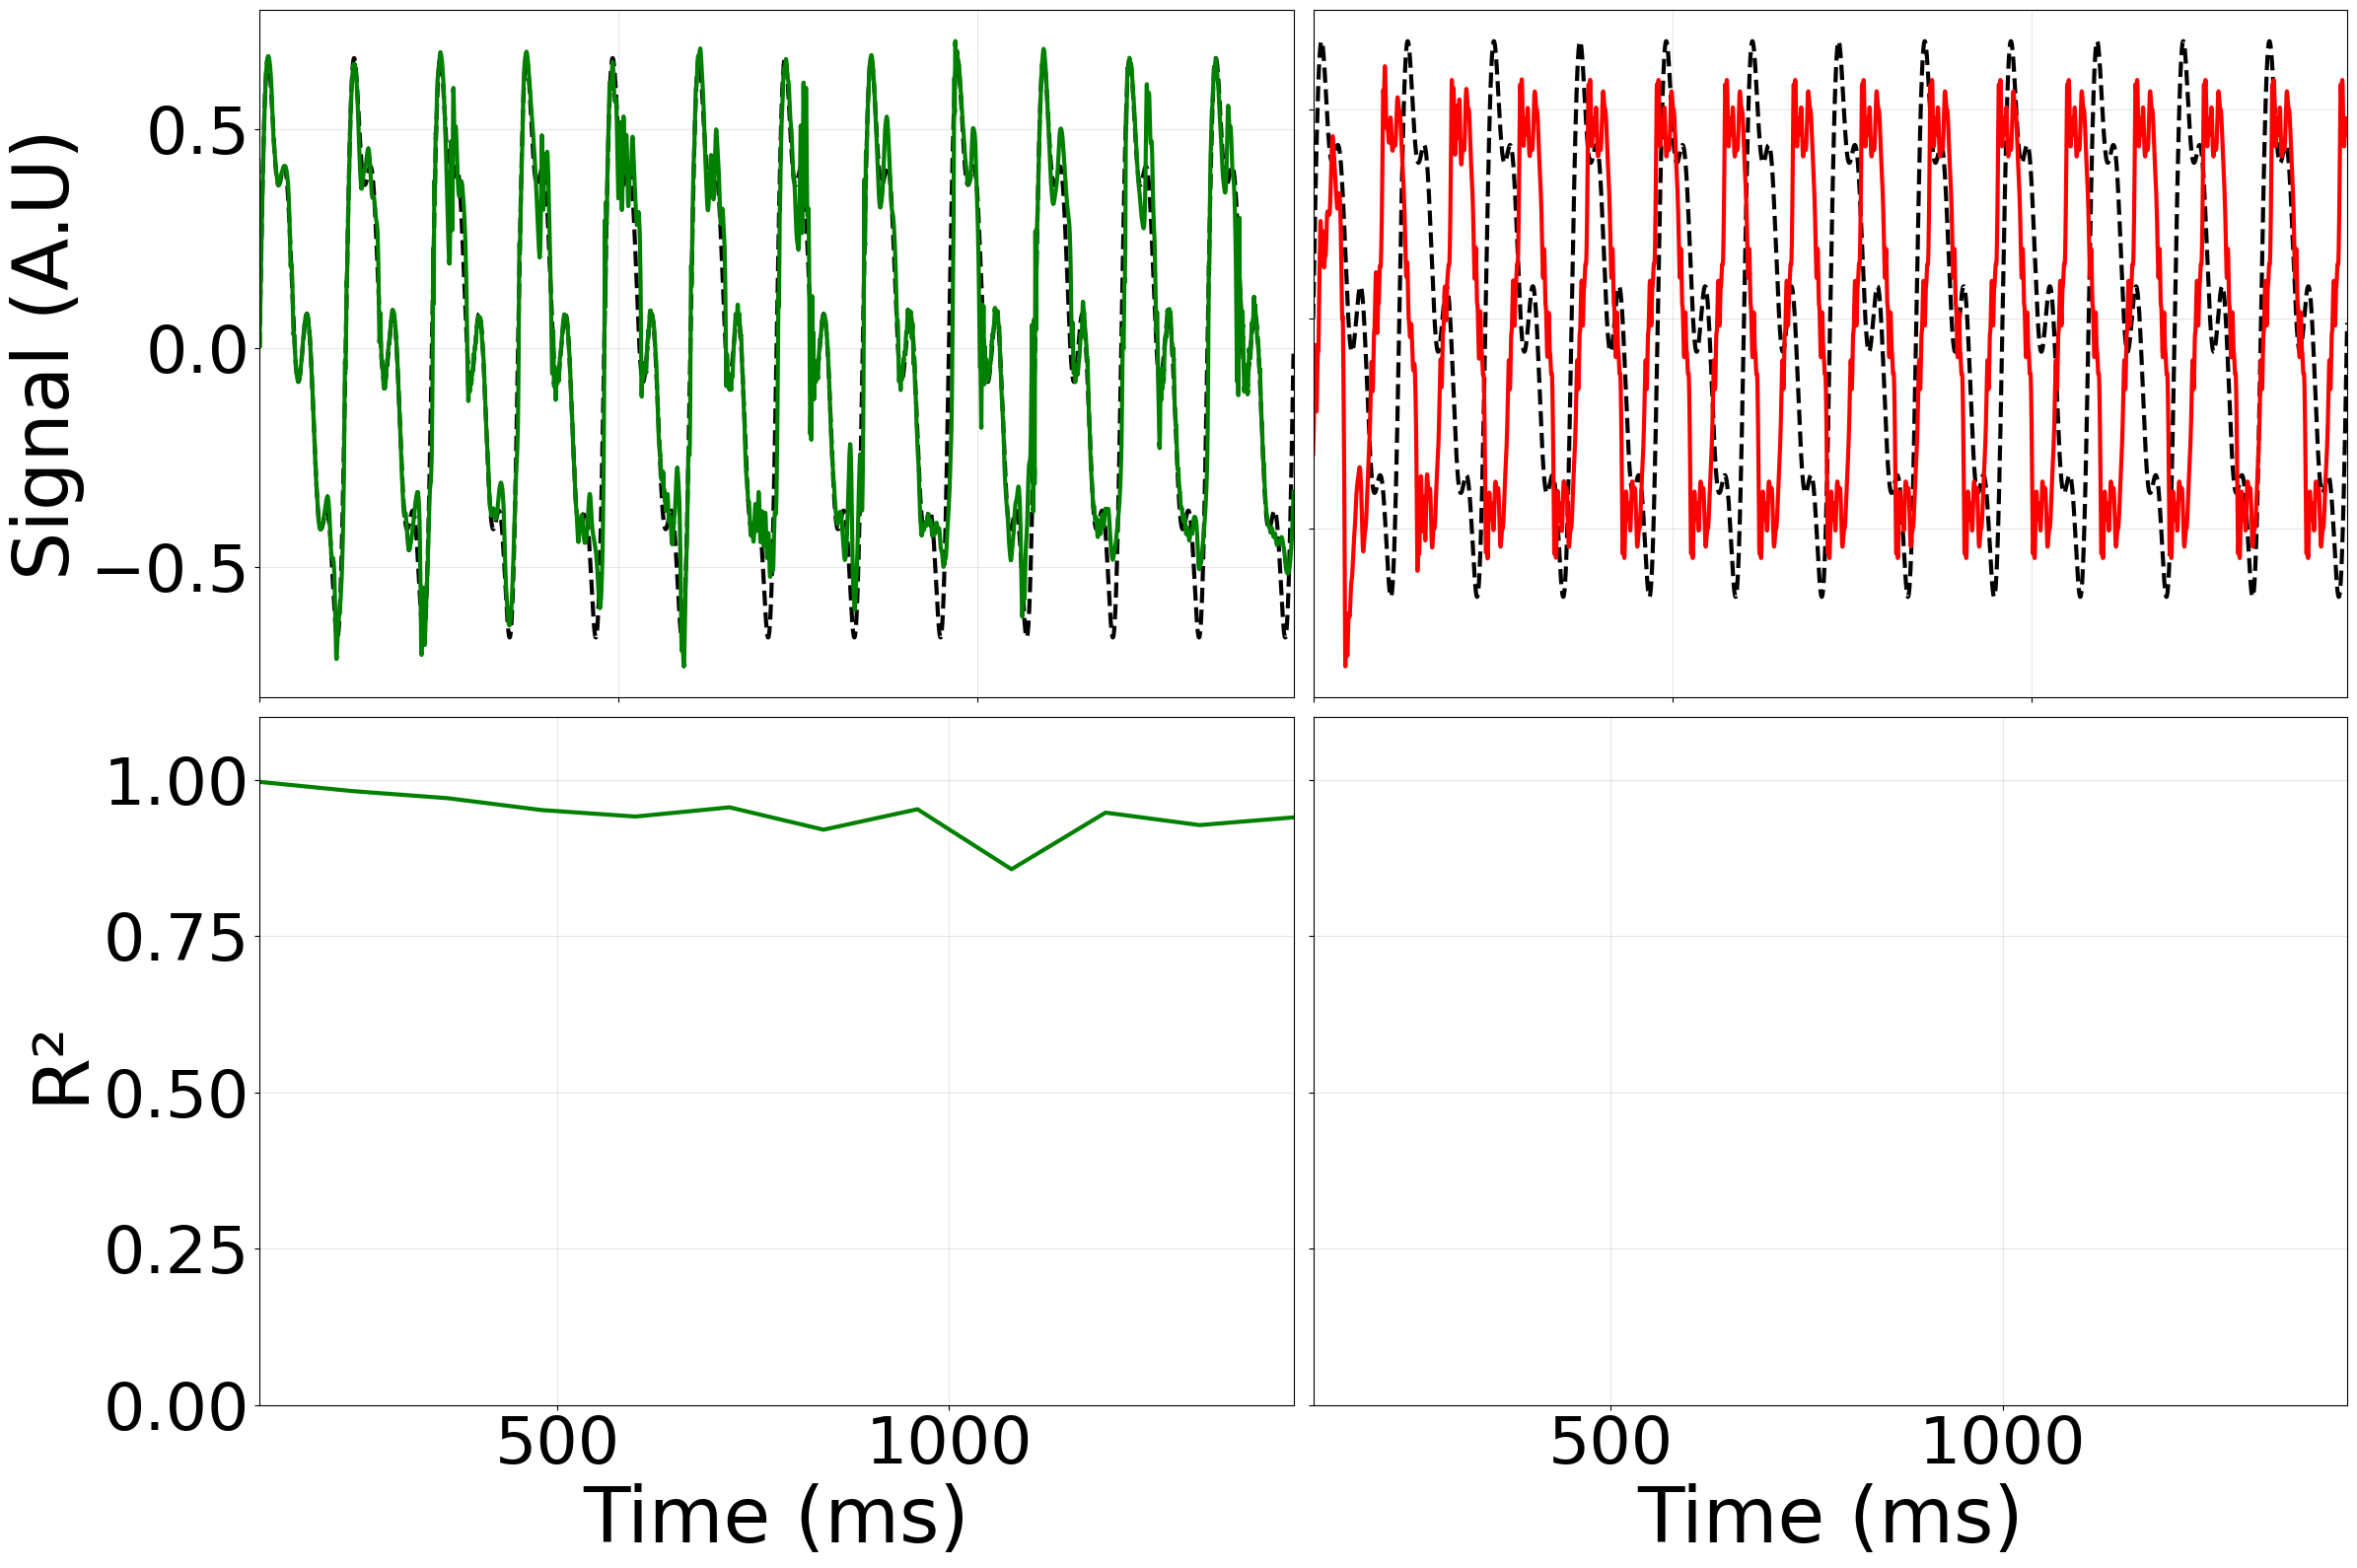

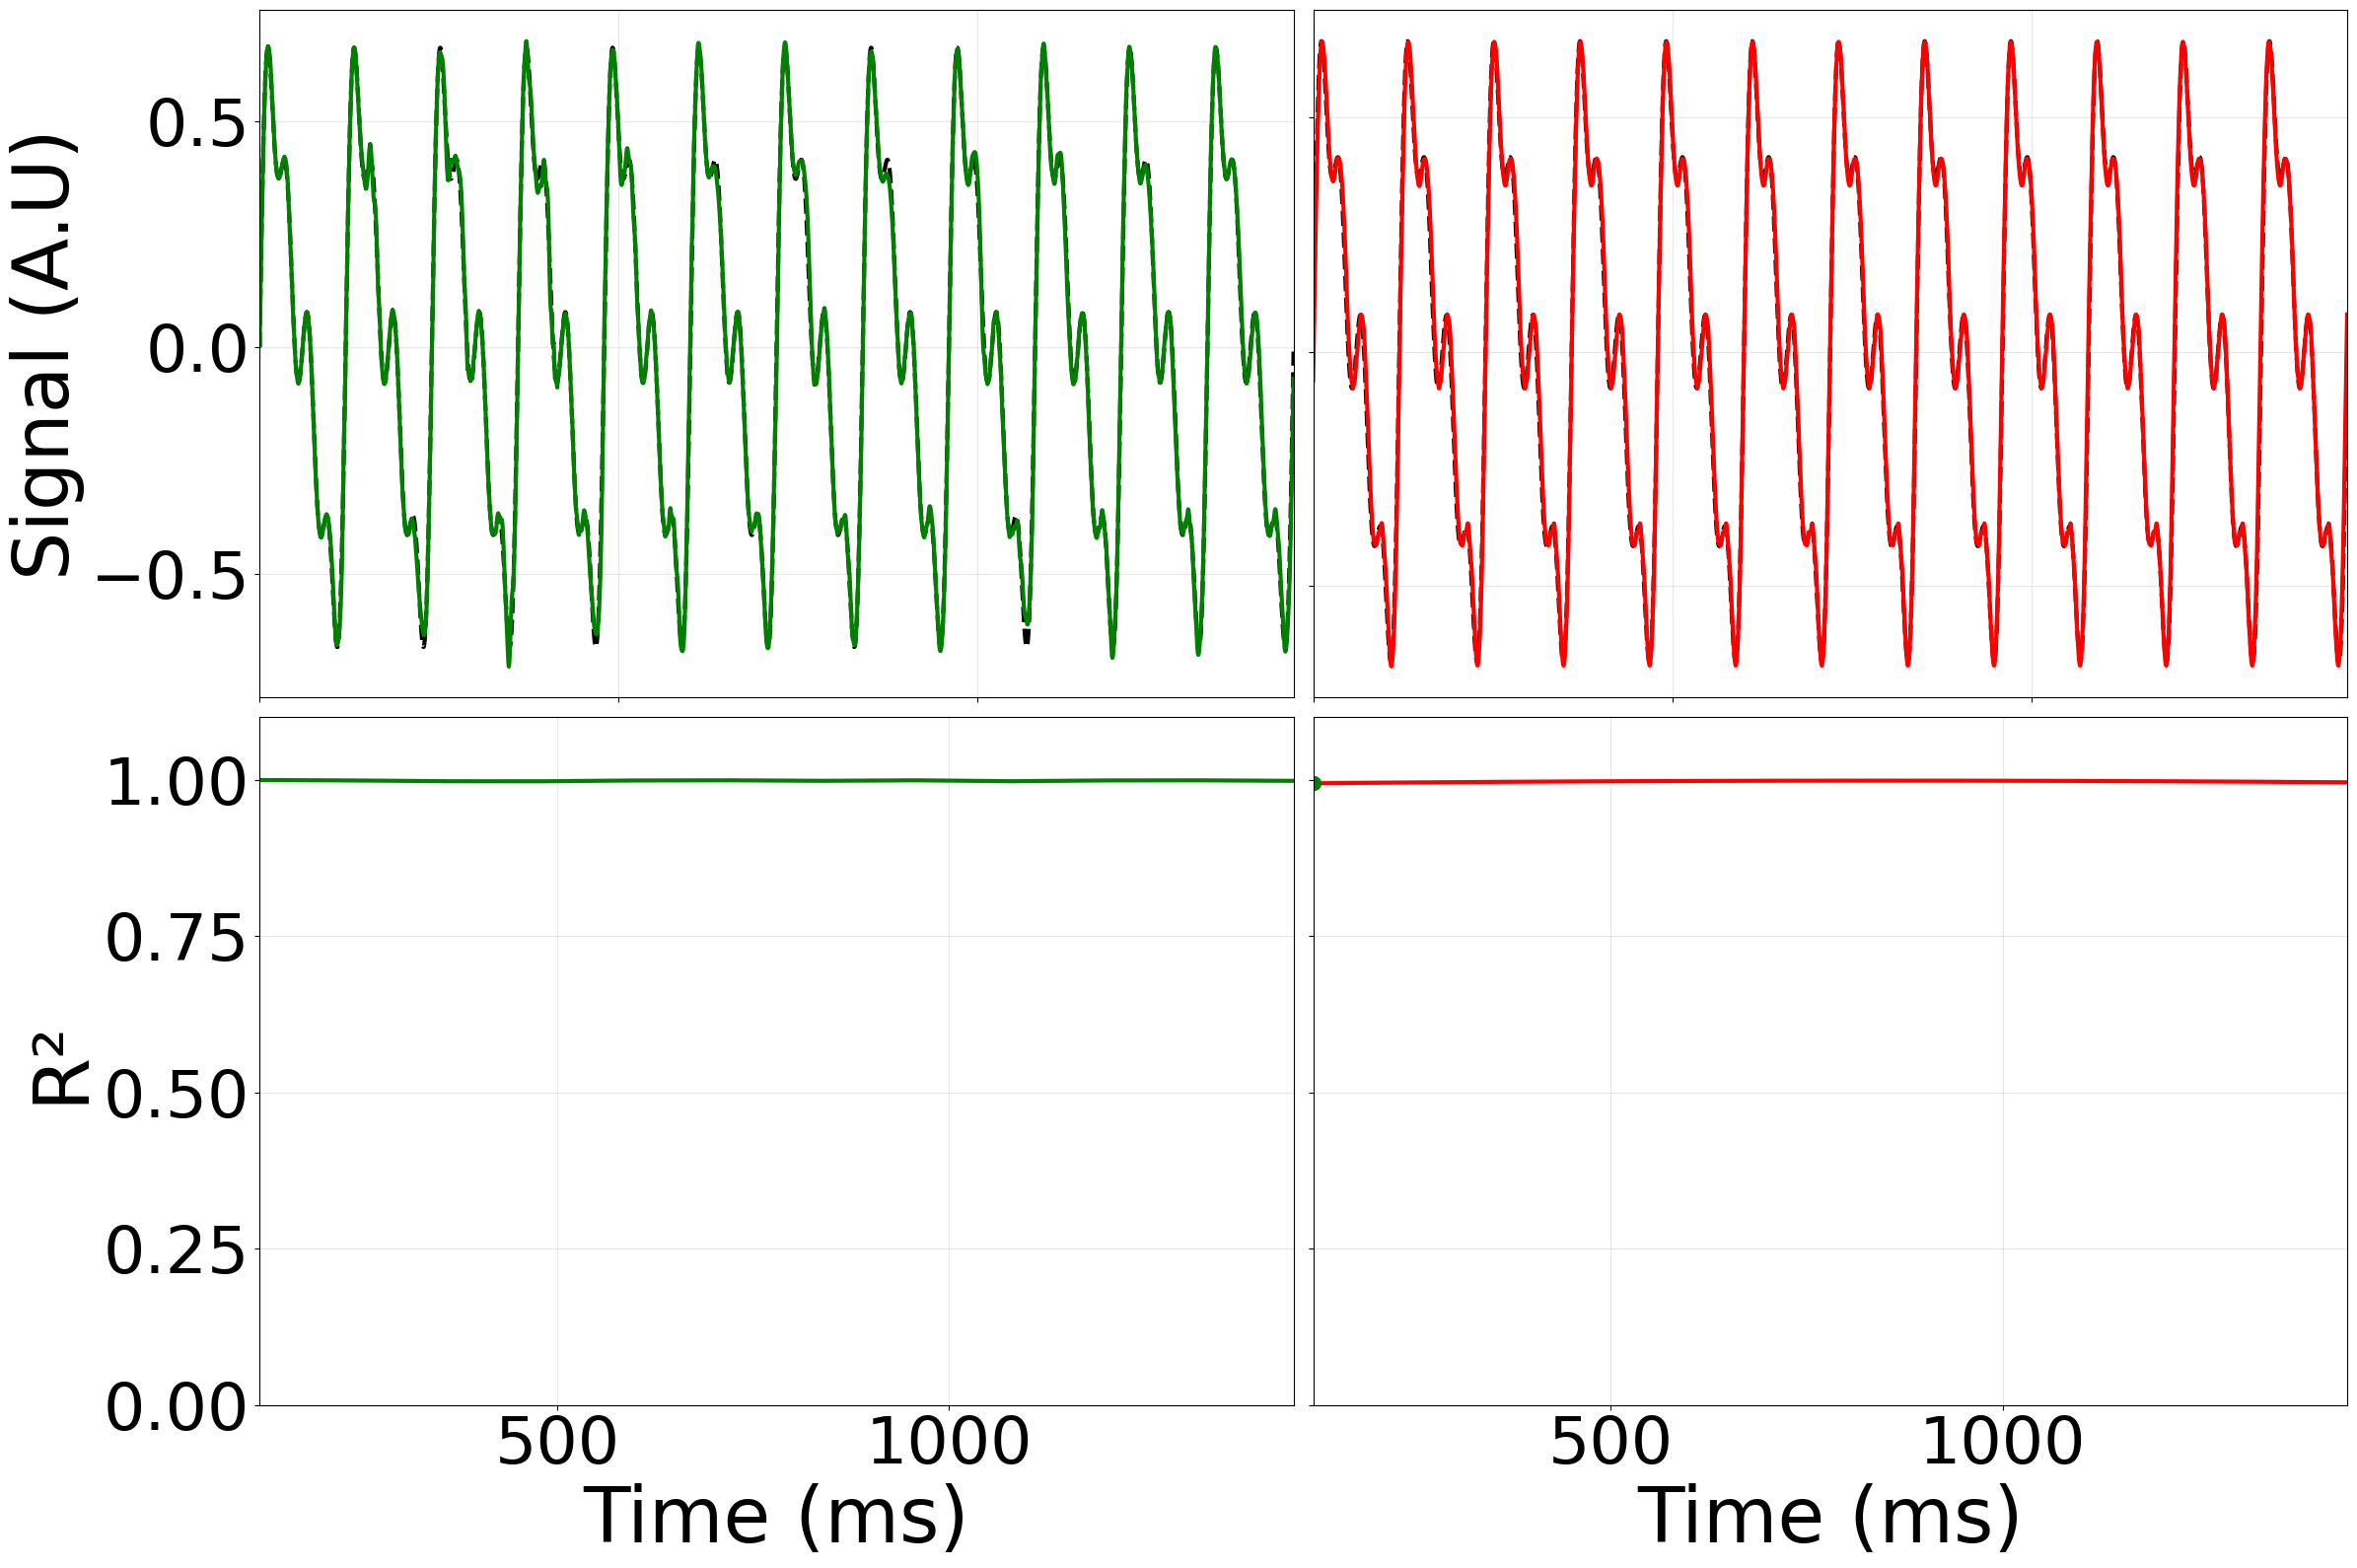

In [46]:
# Fixed parameters according to Sussillo's code


# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 64,
    'axes.labelsize': 56,        # x/y labels
    'xtick.labelsize': 48,       # x ticks
    'ytick.labelsize': 48,       # y ticks
    'legend.fontsize': 20,       # legend text
    'figure.titlesize': 32,      # suptitle (global title)
    'legend.title_fontsize': 28  # legend title
})




Dt = 0.2
eta = 1
dt = 0.1
alpha = 1.0
tau = 1.0
N = 1000
p = 1.0
learn_start = 0 ################CHECK########################
learn_start_idx = int(learn_start / dt)
initialisation_seed = np.array([0])

# Parameter ranges
# n_weight_seeds = range(1, 2)

#change n_sets for test
#n_seeds = 1 
n_weight_seeds = np.array([9])
# n_init_seeds = 0
# MSHs = np.arange(0, 5.2, 0.2)
# MSHs = np.arange(0, 0.4, 0.2)
#MSHs = np.arange(2.6, 4.2, 0.2)
# MSHs = np.array([0.000, 0.001, 0.002, ])
# #MSHs = np.arange(3.6, 4.6, 0.2)
# #MSHs = np.arange(4.6, 5.0, 0.2)
# #MSHs = np.array([0.0,0.2,0.4])

# #MSHs = np.arange(0.4, 1.6, 0.2)
# gains = np.array([1.2, 1.4, 1.6, 1.8, 2.0])
# #gains = np.arange(0, 10.2, 0.2)

# Grok_factor = 50


# tasks = list(product(gains, n_weight_seeds, MSHs))



#for working with tuples combinations of gains and MSHs
# gain_MSH_combos = [
#     (2, 0.013),
#     (2, 0.018),
#     (1.8, 0.007),
#     (1.8, 0.011),
#     (1.8, 0.015),
#     (1.6, 0.001),
#     (1.6, 0.005),
#     (1.6, 0.010),
#     (1.4, 0.000),
#     (1.4, 0.004),
#     (1.4, 0.005),
#     (1.2, 0.000),
#     (1.2, 0.001),
#     (1.2, 0.002),  
# ]

gain_MSH_combos = [
    # (2, 0.013),
    # (2, 0),
    # (1.6, 0),  
    # (1.6, 0.005),
    (1.4, 0.01),
    (1.4, 0.005),
]

tasks = [
    (gain, seed, MSH)
    for gain, MSH in gain_MSH_combos
    for seed in n_weight_seeds
]

# Storage for first-period test Rsquareds (across all configurations)
all_first_period_test_Rsquared = []
all_first_period_training_Rsquared = []

averages_training_Rsquared = []
averages_testing_Rsquared = []

# Process each task and save immediately
for task_idx, (gain, weights_seed, MSH) in enumerate(tasks):
    print(f"  gain={gain}, weights_seed={weights_seed}, MSH={MSH}")
    
    # Test best configuration
    start = time.time()


    trainer = FORCETrainer(
        N=N,
        p=p,
        gain=gain,
        HSM=MSH,
        tau=tau,
        dt=dt,
        Dt=Dt,
        alpha=alpha,
        eta=eta,
        weights_seed=weights_seed,
        initialisation_seed=initialisation_seed
    )



    #Train
    train_time = 1440 + learn_start  #######################CHECK THIS############################
    running_time = np.arange(0, train_time, dt)
    target_train = create_complex_target(running_time, dt)
    train_zs = trainer.train(target_train, running_time, learn_start, verbose=True)

    # Shift target for plotting
    # target_shifted = np.full_like(target_train, np.nan)
    # target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]

    #Test
    after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
    test_time_arr = np.arange(0, after_training_time, dt)
    target_test = create_complex_target(test_time_arr, dt, 1/60)
    test_zs = trainer.test(target_test, test_time_arr, verbose=True)

    # def create_complex_target(running_time, dt, freq=1/60, amps=None):
    steps_per_period = 1200  # 20000 steps #######################CHECK THIS############################
    period_time = np.arange(learn_start, train_time, dt)


    # Rsquared during training (all periods)
    Rsquareds_train = []
    Rsquareds_time_train = []

    for idx in range(0, len(period_time), steps_per_period):
        time_per_period = running_time[idx:idx+steps_per_period]
        target_per_period = target_train[idx:idx+steps_per_period]
        z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_train.append(Rsquared)
            Rsquareds_time_train.append(end_time_step)
            
    # Rsquared_average_training = np.mean(Rsquareds_train)
    # Extract ONLY the first period train Rsquared for saving
    if len(Rsquareds_train) > 0:
        Rsquared_first_period = Rsquareds_train[0]
        Rsquared_average_training = np.mean(Rsquareds_train)
        print(f"  First period train R^2: {Rsquared_first_period:.6f}")
        all_first_period_training_Rsquared.append(Rsquared_first_period)

        print(f"  Average train R^2: {Rsquared_average_training:.6f}")
        averages_training_Rsquared.append(Rsquared_average_training)
        
    else:
        print(f"  Warning: No complete periods in test data")
        Rsquared_average_training = np.nan
        averages_training_Rsquared.append(Rsquared_average_training)
        
        Rsquared_first_period = np.nan
        all_first_period_training_Rsquared.append(Rsquared_first_period)
       

    # Rsquared after training (ALL periods for plotting)
    Rsquareds_test = []
    Rsquareds_time_test = []

    for idx in range(0, len(test_time_arr), steps_per_period):
        time_per_period = test_time_arr[idx:idx+steps_per_period]
        target_per_period = target_test[idx:idx+steps_per_period]
        z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_test.append(Rsquared)
            Rsquareds_time_test.append(end_time_step)

    
    # Extract ONLY the first period test Rsquared for saving
    if len(Rsquareds_test) > 0:
        Rsquared_first_period = Rsquareds_test[0]
        Rsquared_average_testing = np.mean(Rsquareds_test)
        print(f"  First period test R^2: {Rsquared_first_period:.6f}")
        all_first_period_test_Rsquared.append(Rsquared_first_period)
        print(f"  Average test R^2: {Rsquared_average_testing:.6f}")
        averages_testing_Rsquared.append(Rsquared_average_testing)

    else:
        print(f"  Warning: No complete periods in test data")
        Rsquared_average_testing = np.nan
        averages_testing_Rsquared.append(Rsquared_average_testing)
        
        Rsquared_first_period = np.nan
        all_first_period_test_Rsquared.append(Rsquared_first_period)



    #######################CHECK THIS FILE PATH############################
    filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Zoomed HSM 0-0.1 performance plots"
    os.makedirs(filepath, exist_ok=True)

    # filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests"
    # os.makedirs(filepath, exist_ok=True)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    filename = f"idx{task_idx:03d}_gain{gain:.1f}_MSH{MSH}_w_seed{weights_seed}_i_seed{initialisation_seed[0]}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        MSH=MSH,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
    
        # Save ONLY first period test Rsquared
        first_period_test_Rsquared=Rsquared_first_period,
        # Also save all training Rsquareds (for all periods)
        Rsquareds_train=np.array(Rsquareds_train),
        Rsquareds_time_train=np.array(Rsquareds_time_train),
        # Save all test Rsquareds (for all periods) - for reference
        Rsquareds_test_all_periods=np.array(Rsquareds_test),
        Rsquareds_time_test_all_periods=np.array(Rsquareds_time_test),
        
        Rsquared_average_training = Rsquared_average_training,
        Rsquared_average_testing = Rsquared_average_testing
    )



    print(f"✓ Saved to: {filename}")

    # ############## Plotting training and testing trajectories
    # fig, axes = plt.subplots(4, 1, figsize=(12, 24))

    # # Training
    # # axes[0].plot(running_time, target_shifted, 'k--', linewidth=2, label='Target')
    # axes[0].plot(running_time, target_train, 'k--', linewidth=2, label='Target')
    # axes[0].plot(running_time, train_zs['all_z_out'], 'g', linewidth=2, label='RNN output')
    # axes[0].set_xlabel('Time (ms)')
    # axes[0].set_ylabel('Signal (A.U)')
    # #axes[0].set_title(f'Training: gain={gain:.1f}, MSH={MSH}, W_seed={weights_seed}, I_seed={initialisation_seed}')
    # #axes[0].legend(bbox_to_anchor = (1.10,1))
    # axes[0].grid(True, alpha=0.3)
    # # axes[0].set_xlim(0, learn_start)
    # # axes[0].set_ylim(-0.1, 0.1)

    # # Testing
    # axes[1].plot(test_time_arr, target_test, 'k--', linewidth=2, label='Target')
    # axes[1].plot(test_time_arr, test_zs['z_out'], 'r', linewidth=2, label='RNN output')
    # axes[1].set_xlabel('Time (ms)')
    # axes[1].set_ylabel('Signal (A.U)')
    # #axes[1].set_title(f'Testing (1st period R^2: {Rsquared_first_period:.6f})')
    # #axes[1].legend()
    # axes[1].grid(True, alpha=0.3)

    # #Rsquared during training plot (ALL periods)

    # axes[2].plot(Rsquareds_time_train, Rsquareds_train, 'b-', linewidth=2, label='R^2 per period')
    # axes[2].set_xlabel('Time (ms)')
    # axes[2].set_ylabel('R^2')
    # #axes[2].legend()
    # #axes[2].set_title(f'R^2 During Training: gain={gain:.1f}, MSH={MSH}')
    # axes[2].grid(True, alpha=0.3)



    # #Rsquared after training plot (ALL periods)

    # axes[3].plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=2, label='R^2 per period')
    # # Highlight the first period
    # if len(Rsquareds_test) > 0:
    #     axes[3].plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10, 
    #             label=f'1st period: {Rsquared_first_period:.6f}')
    # axes[3].set_xlabel('Time (ms)')
    # axes[3].set_ylabel('R^2')
    # #axes[3].legend()
    # #axes[3].set_title(f'R^2 After Training: gain={gain:.1f}, MSH={MSH}')
    # axes[3].grid(True, alpha=0.3)

    # plt.tight_layout()

    fig, axes = plt.subplots(2, 2, figsize=(24, 16))

    # --- Top-left: Training trajectory ---
    ax = axes[0, 0]
    ax.plot(running_time, target_train, 'k--', linewidth=3, label='Target')
    ax.plot(running_time, train_zs['all_z_out'], 'g', linewidth=3, label='RNN output')
    ax.set_ylabel('Signal (A.U)')
    ax.tick_params(axis='x', labelbottom=False)
    ax.xaxis.label.set_visible(False)
    ax.grid(True, alpha=0.3)
    
    # --- Top-right: Testing trajectory ---
    ax = axes[0, 1]
    ax.plot(test_time_arr, target_test, 'k--', linewidth=3, label='Target')
    ax.plot(test_time_arr, test_zs['z_out'], 'r', linewidth=3, label='RNN output')
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.grid(True, alpha=0.3)
    
    # --- Bottom-left: R² during training ---
    ax = axes[1, 0]
    ax.plot(Rsquareds_time_train, Rsquareds_train, 'g-', linewidth=3)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('R²')
    ax.grid(True, alpha=0.3)
    
    # --- Bottom-right: R² after training ---
    ax = axes[1, 1]
    ax.plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=3)
    if len(Rsquareds_test) > 0:
        ax.plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10,
                label=f'1st period: {Rsquared_first_period:.6f}')
    ax.set_xlabel('Time (ms)')
    ax.tick_params(axis='y', labelleft=False)
    ax.yaxis.label.set_visible(False)
    ax.grid(True, alpha=0.3)

    # Match x-axis tick range across top row
    x_min_top = min(running_time[0], test_time_arr[0])
    x_max_top = max(running_time[-1], test_time_arr[-1])
    axes[0, 0].set_xlim(x_min_top, x_max_top)
    axes[0, 1].set_xlim(x_min_top, x_max_top)
    
    # Match x-axis tick range across bottom row
    x_min_bot = min(Rsquareds_time_train[0], Rsquareds_time_test[0])
    x_max_bot = max(Rsquareds_time_train[-1], Rsquareds_time_test[-1])
    axes[1, 0].set_xlim(x_min_bot, x_max_bot)
    axes[1, 1].set_xlim(x_min_bot, x_max_bot)
    
    # Fix y-axis to [0, 1] for bottom row
    axes[1, 0].set_ylim(0, 1.1)
    axes[1, 1].set_ylim(0, 1.1)
  
    plt.tight_layout()
    
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    Combined_plots_train_test_Rsquared_filename = f"gain{gain:.1f}_MSH{MSH}_W_seed{weights_seed}_time{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    Combined_plots_train_test_Rsquared_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis",
    Combined_plots_train_test_Rsquared_filename)

    # Combined_plots_train_test_Rsquared_filename = f"gain{gain:.1f}_MSH{MSH:.1f}_Dt{Dt:.1f}_eta{eta:.1f}_W_seed{weights_seed}_time{timestamp}.png"
    # #######################CHECK THIS FILE PATH############################
    # Combined_plots_train_test_Rsquared_filepath = os.path.join(
    # r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
    # Combined_plots_train_test_Rsquared_filename)

    
    plt.savefig(Combined_plots_train_test_Rsquared_filepath, dpi=300, bbox_inches='tight')



summary_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
    f"first_period_test_R^2_summary_MSHs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
#     f"first_period_test_Rsquared_summary_MSHs={MSHs}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

np.savez(
    summary_filepath,
    first_period_test_Rsquareds=np.array(all_first_period_test_Rsquared),
    gains=gains,
    MSHs=MSHs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)



summary_first_period_training_filepath = os.path.join(
r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
f"first_period_training_R^2_summary_MSHs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_first_period_training_filepath = os.path.join(
# r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
# f"first_period_training_Rsquared_summary_MSHs={MSHs}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")


np.savez(
    summary_first_period_training_filepath,
    first_period_training_Rsquareds=np.array(all_first_period_training_Rsquared),
    gains=gains,
    MSHs=MSHs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)



summary_averages_during_training_filepath = os.path.join(
r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
f"summary_averages_during_training_filepath_MSHs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_averages_during_training_filepath = os.path.join(
# r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
# f"summary_averages_during_training_filepath_MSHs={MSHs}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

np.savez(
    summary_averages_during_training_filepath,
    averages_training_Rsquareds=np.array(averages_training_Rsquared),
    gains=gains,
    MSHs=MSHs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)


summary_averages_after_training_filepath = os.path.join(
r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance plots thesis\summary files zoomed in",
f"summary_averages_after_training_filepath_MSHs_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")

# summary_averages_after_training_filepath = os.path.join(
# r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\tests",
# f"summary_averages_after_training_filepath_MSHs={MSHs}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz")


np.savez(
    summary_averages_after_training_filepath,
    averages_testing_Rsquareds=np.array(averages_testing_Rsquared),
    gains=gains,
    MSHs=MSHs,
    etas=eta,
    Dts=Dt,
    weights_seeds= n_weight_seeds)

print(f"Job complete")

## for testing individual cases

100%|██████████| 14400/14400 [00:05<00:00, 2757.07it/s]


  First period test Rsquared: -0.740429


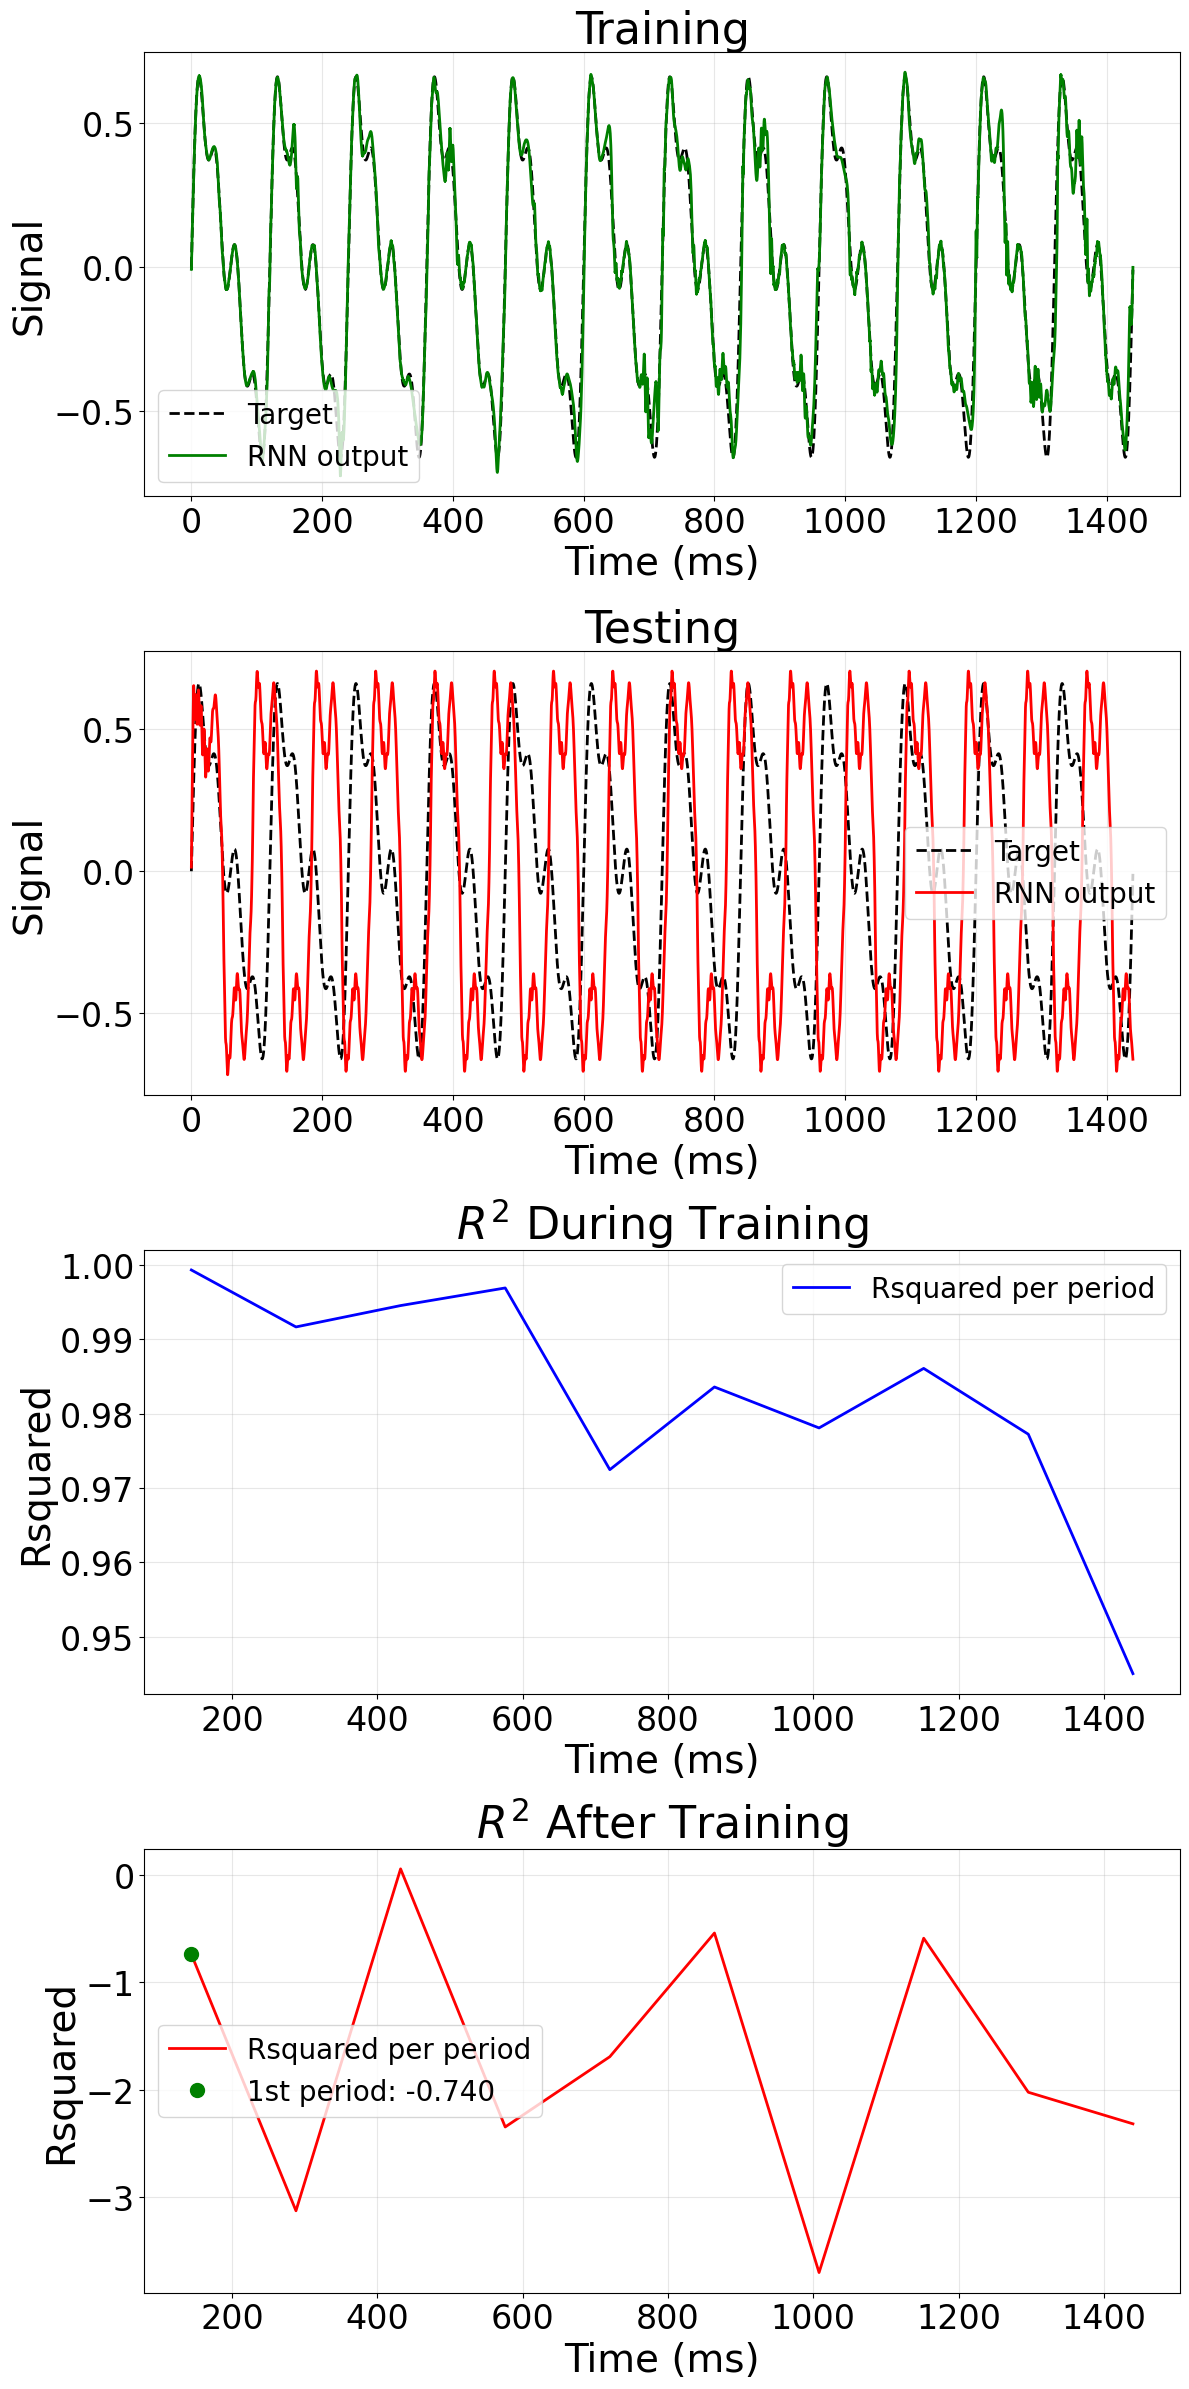


First Period Test Rsquared Summary:
  Mean: -0.740429
  Std:  0.000000
  Min:  -0.740429 (best)
  Max:  -0.740429 (worst)


100%|██████████| 14400/14400 [00:05<00:00, 2543.05it/s]


  First period test Rsquared: -1.065665


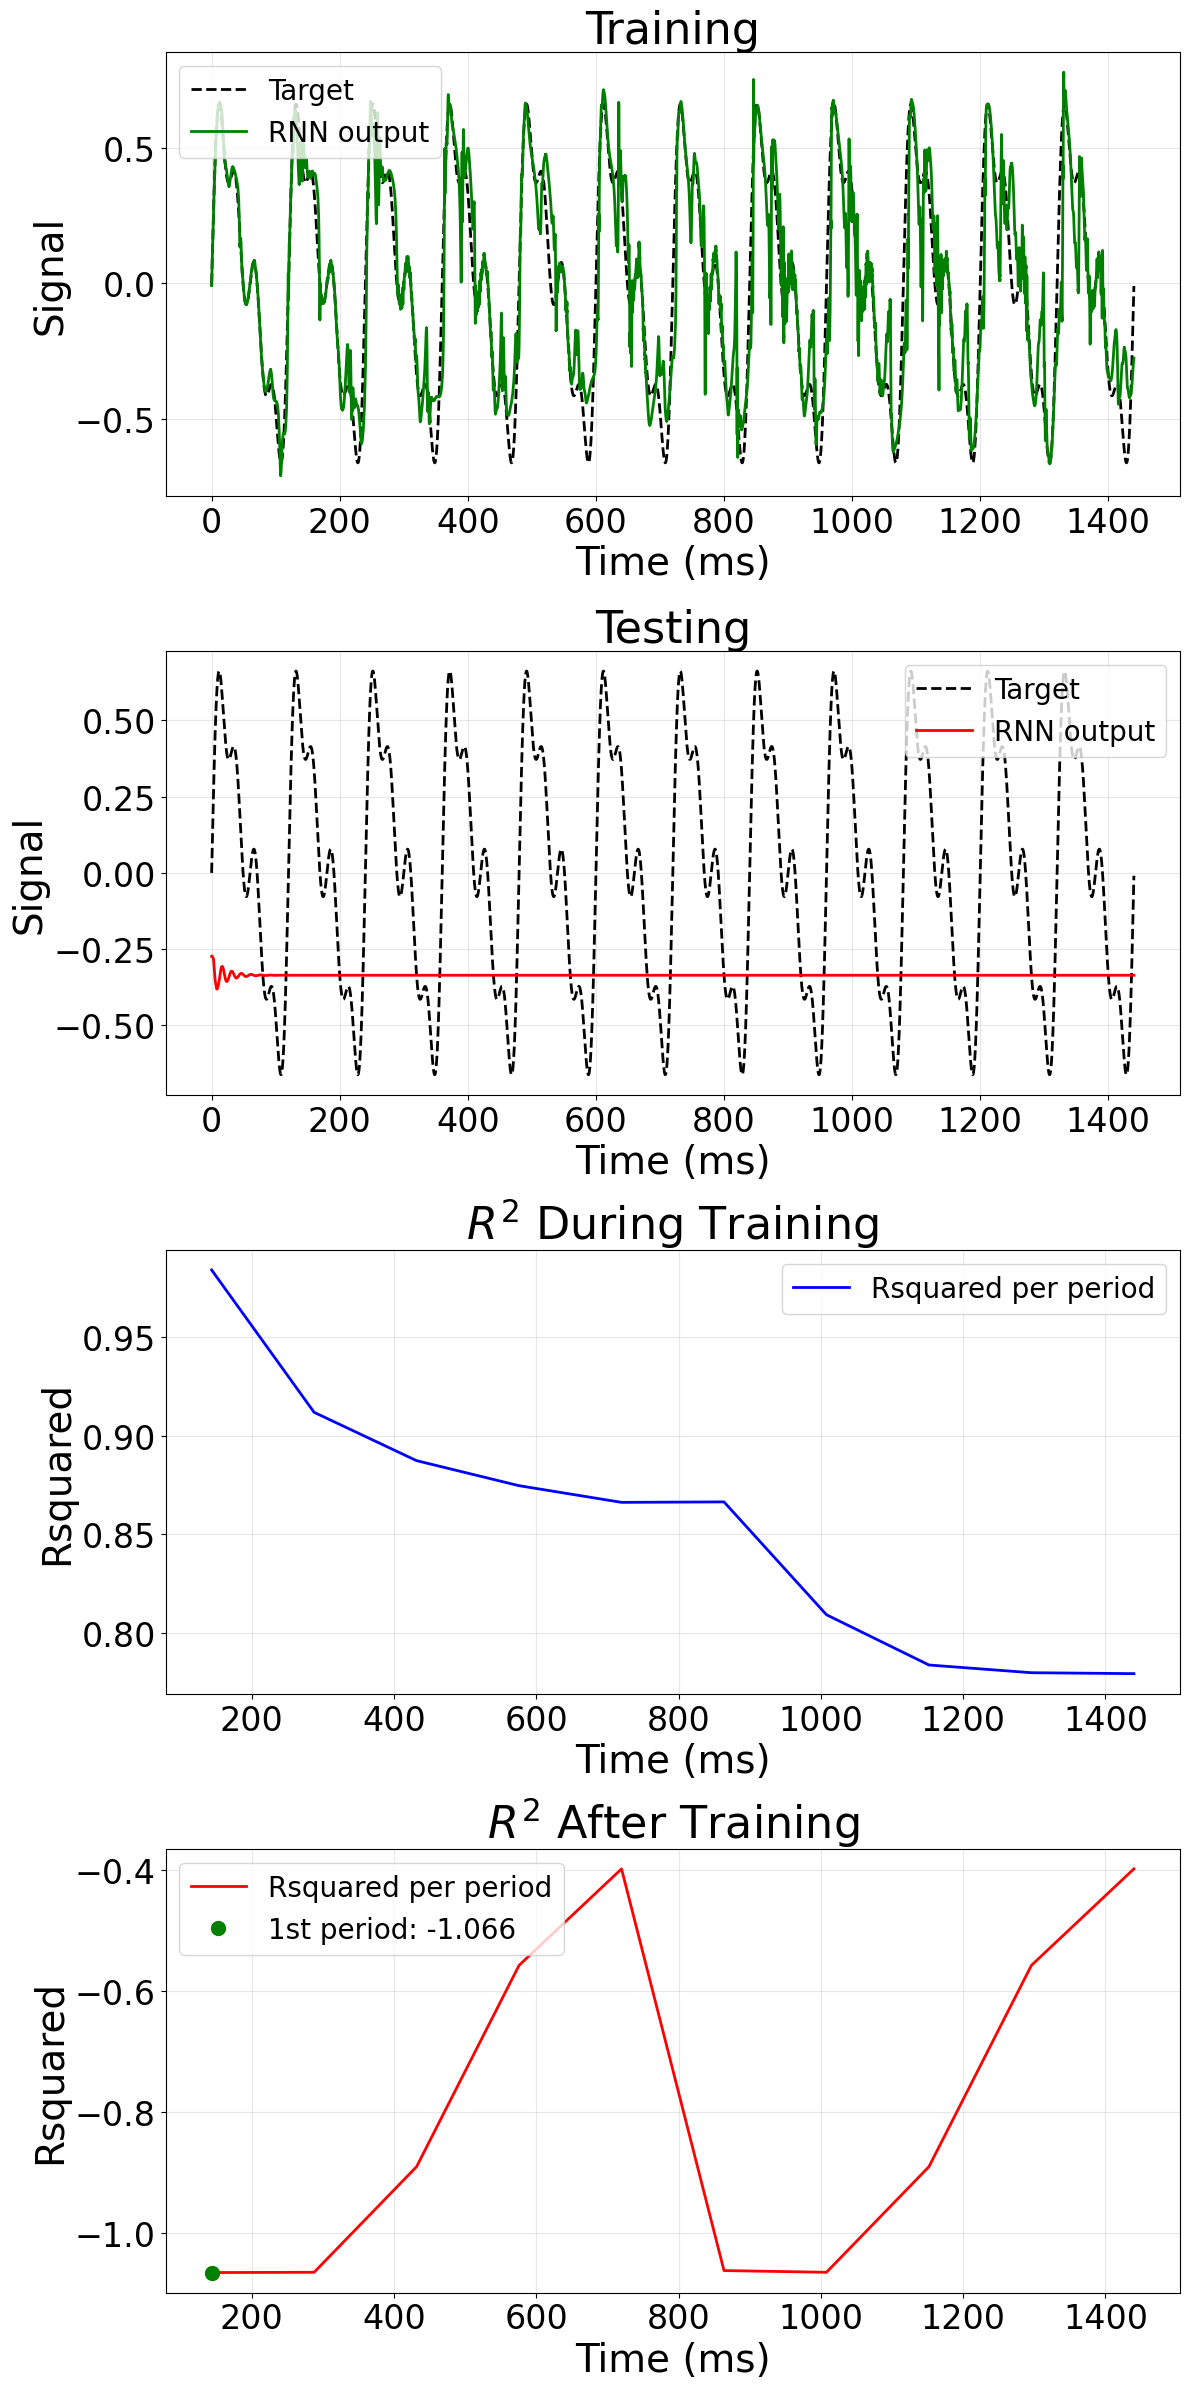


First Period Test Rsquared Summary:
  Mean: -0.903047
  Std:  0.162618
  Min:  -1.065665 (best)
  Max:  -0.740429 (worst)


100%|██████████| 14400/14400 [00:05<00:00, 2503.97it/s]


  First period test Rsquared: -1.037290


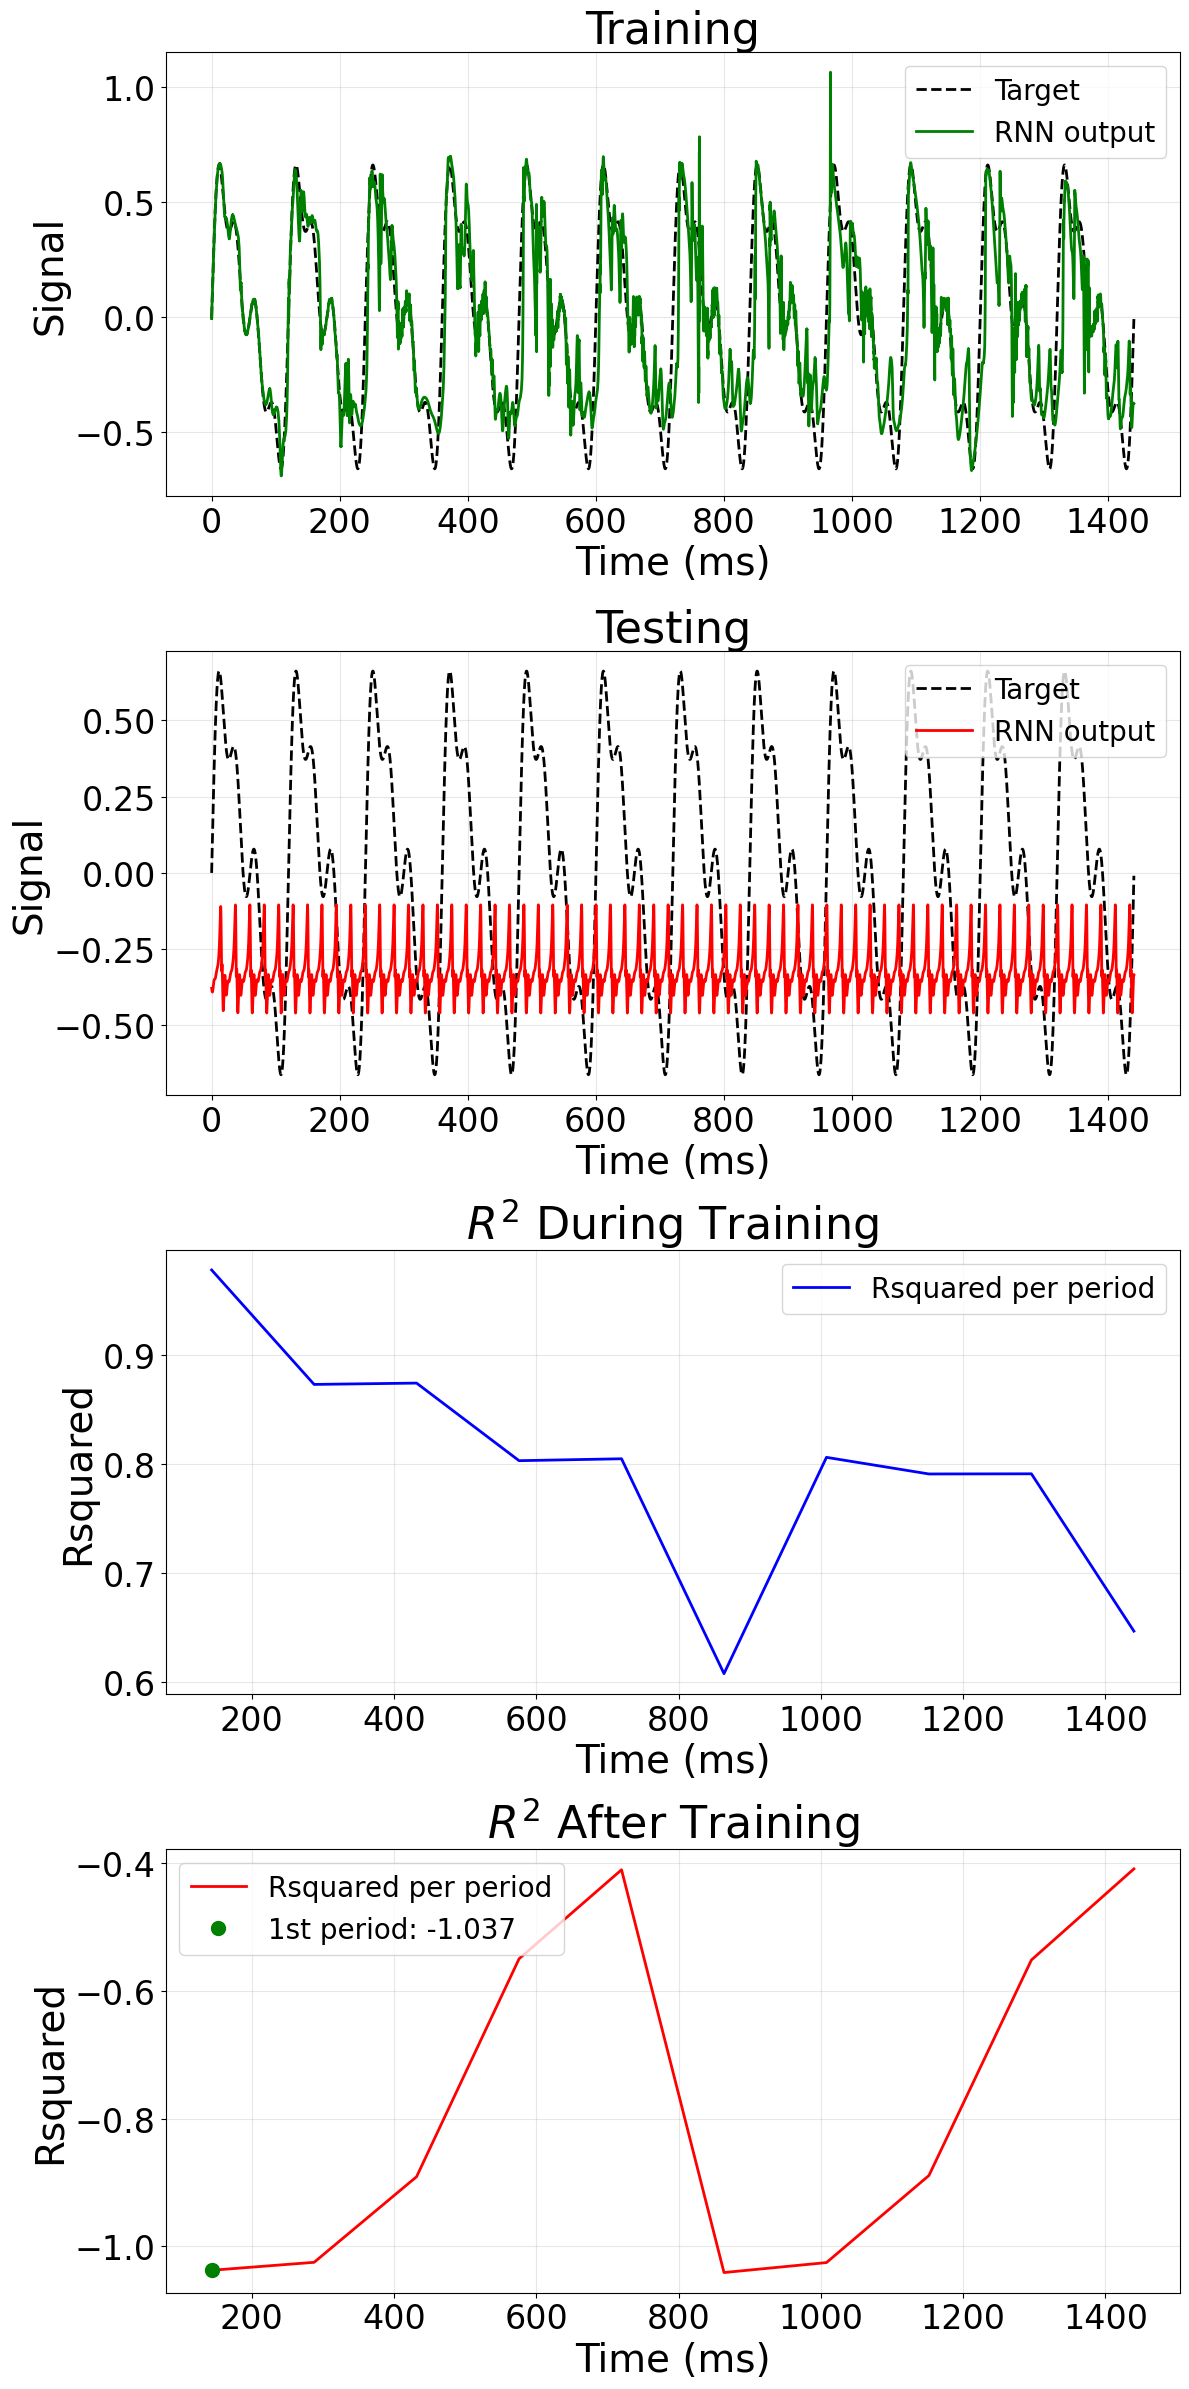


First Period Test Rsquared Summary:
  Mean: -0.947795
  Std:  0.147087
  Min:  -1.065665 (best)
  Max:  -0.740429 (worst)


In [91]:
import matplotlib.pyplot as plt

# Reset to avoid old notebook settings interfering
plt.rcdefaults()

# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 32,
    'axes.labelsize': 28,        # x/y labels
    'xtick.labelsize': 24,       # x ticks
    'ytick.labelsize': 24,       # y ticks
    'legend.fontsize': 20,       # legend text
    'figure.titlesize': 32,      # suptitle (global title)
    'legend.title_fontsize': 28  # legend title
})

# Storage for first-period test Rsquareds (across all configurations)
all_first_period_test_Rsquared = []


dt = 0.1

learn_start = 0
learn_start_idx = int(learn_start / dt)


Dt = 0.2
eta = 1
# MSH = 0
# gain = 1.6
# MSHs = np.array([0.00, 0.01, 0.02])
# MSHs =  np.array([0.00, 0.04, 0.05])
MSHs = np.array([0.01, 0.05, 0.10])
# MSHs =  np.array([0.07, 0.11, 0.15])
# MSHs = np.array([0.13, 0.18])

# gains = np.array([1.2])
#gains = np.array([1.4])
gains = np.array([1.6])
# gains = np.array([1.8])
# gains = np.array([2.0])
dt = 0.1
alpha = 1.0
tau = 1.0
N = 1000
p = 1.0
weights_seed = 9
initialisation_seed = 1


# print(f"\n{'='*60}")
# print(f"  gain={gain}, MSH={MSH}, seed={weights_seed}")
# print(f"  eta={eta}, Dt={Dt}")
# print(f"{'='*60}")

for gain in gains:
    for MSH in MSHs: 
        # Create trainer with parameters from this configuration
        trainer = FORCETrainer(
            N=N,
            p=p,
            gain=gain,
            HSM=MSH,
            tau=tau,
            dt=dt,
            Dt=Dt,
            alpha=alpha,
            eta=eta,
            weights_seed=weights_seed,
            initialisation_seed=initialisation_seed
        )
        
        
        
        #Train
        train_time = 1440 + learn_start  #######################CHECK THIS############################
        running_time = np.arange(0, train_time, dt)
        target_train = create_complex_target(running_time, dt)
        train_zs = trainer.train(target_train, running_time, learn_start, verbose=True)
        
        # Shift target for plotting
        # target_shifted = np.full_like(target_train, np.nan)
        # target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
        
        #Test
        after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
        test_time_arr = np.arange(0, after_training_time, dt)
        target_test = create_complex_target(test_time_arr, dt, 1/60)
        test_zs = trainer.test(target_test, test_time_arr, verbose=True)
        
        # def create_complex_target(running_time, dt, freq=1/60, amps=None):
        steps_per_period = 1440  # 20000 steps #######################CHECK THIS############################
        time = np.arange(learn_start, train_time, dt)
        
        
        # Rsquared during training (all periods)
        Rsquareds_train = []
        Rsquareds_time_train = []
        
        for idx in range(0, len(time), steps_per_period):
            time_per_period = running_time[idx:idx+steps_per_period]
            target_per_period = target_train[idx:idx+steps_per_period]
            z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
            
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
                sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
                Rsquared = 1 - (sum_SS_res/sum_SS_tot)
                Rsquareds_train.append(Rsquared)
                Rsquareds_time_train.append(end_time_step)
        
        # Rsquared after training (ALL periods for plotting)
        Rsquareds_test = []
        Rsquareds_time_test = []
        
        for idx in range(0, len(test_time_arr), steps_per_period):
            time_per_period = test_time_arr[idx:idx+steps_per_period]
            target_per_period = target_test[idx:idx+steps_per_period]
            z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
            
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
                sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
                Rsquared = 1 - (sum_SS_res/sum_SS_tot)
                Rsquareds_test.append(Rsquared)
                Rsquareds_time_test.append(end_time_step)
        
        # Extract ONLY the first period test Rsquared for saving
        if len(Rsquareds_test) > 0:
            Rsquared_first_period = Rsquareds_test[0]
            print(f"  First period test Rsquared: {Rsquared_first_period:.6f}")
            all_first_period_test_Rsquared.append(Rsquared_first_period)
        else:
            print(f"  Warning: No complete periods in test data")
            Rsquared_first_period = np.nan
            all_first_period_test_Rsquared.append(Rsquared_first_period)
        
        
        
        ############## Plotting training and testing trajectories
        fig, axes = plt.subplots(4, 1, figsize=(12, 24))
        
        # Training
        # axes[0].plot(running_time, target_shifted, 'k--', linewidth=2, label='Target')
        axes[0].plot(running_time, target_train, 'k--', linewidth=2, label='Target')
        axes[0].plot(running_time, train_zs['all_z_out'], 'g', linewidth=2, label='RNN output')
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_ylabel('Signal')
        axes[0].set_title(f'Training')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        # axes[0].set_xlim(0, learn_start)
        # axes[0].set_ylim(-0.00001, 0.00001)
        
        # Testing
        axes[1].plot(test_time_arr, target_test, 'k--', linewidth=2, label='Target')
        axes[1].plot(test_time_arr, test_zs['z_out'], 'r', linewidth=2, label='RNN output')
        axes[1].set_xlabel('Time (ms)')
        axes[1].set_ylabel('Signal')
        axes[1].set_title(f'Testing')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        #Rsquared during training plot (ALL periods)
        
        axes[2].plot(Rsquareds_time_train, Rsquareds_train, 'b-', linewidth=2, label='Rsquared per period')
        axes[2].set_xlabel('Time (ms)')
        axes[2].set_ylabel('Rsquared')
        axes[2].legend()
        axes[2].set_title(f'$R^2$ During Training')
        axes[2].grid(True, alpha=0.3)
        
        
        
        #Rsquared after training plot (ALL periods)
        
        axes[3].plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=2, label='Rsquared per period')
        # Highlight the first period
        if len(Rsquareds_test) > 0:
            axes[3].plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10, 
                     label=f'1st period: {Rsquared_first_period:.3f}')
        axes[3].set_xlabel('Time (ms)')
        axes[3].set_ylabel('Rsquared')
        axes[3].legend()
        axes[3].set_title(f'$R^2$ After Training')
        axes[3].grid(True, alpha=0.3)
        
        # legend_kwargs = dict(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
        # axes[0].legend(**legend_kwargs)
        # axes[1].legend(**legend_kwargs)
        # axes[2].legend(**legend_kwargs)
        # axes[3].legend(**legend_kwargs)
        
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        
        Rsquared_test_filename = f"gain={gain}, MSH={MSH}, W_seed={weights_seed}, I_seed={initialisation_seed}, learnstart={learn_start} (η={eta:.3f}, Δt={Dt:.1f})_time{timestamp}.png"
        #######################CHECK THIS FILE PATH############################
        Rsquared_test_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Performance Plots thesis",
        Rsquared_test_filename
        )
        plt.savefig(Rsquared_test_filepath, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        
        # Print summary statistics
        valid_Rsquareds = np.array([r for r in all_first_period_test_Rsquared if not np.isnan(r)])
        print(f"\nFirst Period Test Rsquared Summary:")
        print(f"  Mean: {np.mean(valid_Rsquareds):.6f}")
        print(f"  Std:  {np.std(valid_Rsquareds):.6f}")
        print(f"  Min:  {np.min(valid_Rsquareds):.6f} (best)")
        print(f"  Max:  {np.max(valid_Rsquareds):.6f} (worst)")

# For analysing with the optimized parameters from Threadripper 1

## loading in the data

In [15]:
results = load_combined_FORCE_results(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM optimized params Dt and eta\FORCE_HSMs0_100randoms_periodic_1seed_W_and_Init")


Loaded 19 entries from C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM optimized params Dt and eta\FORCE_HSMs0_100randoms_periodic_1seed_W_and_Init\results_combined_sorted.npz
  Gains range: 0.0 - 10.0
  MSHs range: 0.0 - 0.0


In [17]:
Etas = results['Etas']
Dts = results['Dts']
Gains = results['Gains']
MSHs = results['MSHs']
Weights_Seeds = results['Weights_Seeds']
mean_maes = results['mean_maes']
std_maes = results['std_maes']

print(f"{Weights_Seeds}, shape weights_seed: {Weights_Seeds.shape}")
print(f"{Etas}, shape of etas: {Etas.shape}")
print(f" {Dts}, shape of Dts: {Dts.shape}")
print(f"{Gains}, shape of Gains: {Gains.shape}")
print(f"{mean_maes}, shape of mean_mae: {mean_maes.shape}")
print(f"{std_maes}, shape of std_mae: {std_maes.shape}")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1], shape weights_seed: (19,)
[0.15152634 0.58759877 0.74809075 0.67127695 0.78985726 0.84972695
 0.28713216 0.86295372 0.84515519 0.35064672 0.56592217 0.81918504
 0.02857901 0.87676931 0.96535742 0.97565941 0.62599604 0.94107019
 0.77892074], shape of etas: (19,)
 [ 1.71142083 14.88788308 14.06940216 13.16563793 16.1874682   7.70158603
  1.81780188  7.75173942 13.67130228  9.7544513   2.5934897  14.81403438
  8.10121083  3.61263519  9.43321467  9.37577704  6.77017257  9.48872111
  8.28142492], shape of Dts: (19,)
[ 0.   0.5  1.   1.2  1.4  1.5  1.6  1.8  2.   2.5  3.   3.5  4.   5.
  6.   7.   8.   9.  10. ], shape of Gains: (19,)
[0.7530169  0.7530169  0.66088404 0.49452333 0.74016507 0.66118987
 0.92482803 0.70865012 0.87372281 0.91927192 0.87079769 0.84601441
 0.89762905 0.75179989 0.85584833 0.73802914 0.87875802 0.81900355
 0.82934485], shape of mean_mae: (19,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape of std_mae: (19,

In [19]:


# Quick check to verify data is aligned correctly
print("\nFirst 5 configurations:")
print(f"{'Idx':>3} {'Gain':>6} {'MSH':>6} {'eta':>8} {'Dt':>8} {'MAE':>10}")
print("-" * 50)
for i in range(min(5, len(Etas))):
    print(f"{i:3d} {Gains[i]:6.1f} {MSHs[i]:6.1f} {Etas[i]:8.4f} {Dts[i]:8.1f} {mean_maes[i]:10.6f}")

# This should output something like:
# ```
# Idx   Gain    MSH      eta       Dt        MAE
# --------------------------------------------------
#   0    0.2    0.2   0.6148    6.39   0.065596
#   1    0.2    1.0   0.1534   12.30   0.138166
#   2    0.2    2.0   0.4742    9.72   0.088316
#   3    0.2    3.0   0.7666   16.42   0.071626
#   4    0.2    4.0   0.2163   16.76   0.073360


First 5 configurations:
Idx   Gain    MSH      eta       Dt        MAE
--------------------------------------------------
  0    0.0    0.0   0.1515      1.7   0.753017
  1    0.5    0.0   0.5876     14.9   0.753017
  2    1.0    0.0   0.7481     14.1   0.660884
  3    1.2    0.0   0.6713     13.2   0.494523
  4    1.4    0.0   0.7899     16.2   0.740165


## Training and testing with the optimized parameters

In [21]:
#pre loop initialisations

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['legend.title_fontsize'] = 14

print(f"Total number of configurations: {len(Etas)}")
print(f"Unique gains: {np.unique(Gains)}")
print(f"Unique MSHs: {np.unique(MSHs)}")

learn_start = 500##########################CHECK THIS################################
dt = 0.1
learn_start_idx = int(learn_start / dt)


####################CHECK THESE#########################
N=1000
p=1.0
tau=1.0
dt=0.1
Dt=0.2
alpha=1.0
initialisation_seed=1


Total number of configurations: 19
Unique gains: [ 0.   0.5  1.   1.2  1.4  1.5  1.6  1.8  2.   2.5  3.   3.5  4.   5.
  6.   7.   8.   9.  10. ]
Unique MSHs: [0.]


In [133]:
# Test best configuration
start = time.time()

# Storage for first-period test Rsquareds (across all configurations)
all_first_period_test_Rsquared = []



# Loop over all entries (each entry is a unique gain/MSH/seed combination)
for i in range(len(Etas)):
    
    gain = Gains[i]
    MSH = MSHs[i]
    eta = Etas[i]
    #Dt = Dts[i]
    weights_seed = Weights_Seeds[i]
    mean_mae = mean_maes[i]
    std_mae = std_maes[i]
    
    print(f"\n{'='*60}")
    print(f"Processing configuration {i+1}/{len(Etas)}")
    print(f"  gain={gain:.1f}, MSH={MSH:.1f}, seed={weights_seed}")
    print(f"  eta={eta:.4f}, Dt={Dt:.1f}")
    print(f"  Expected MAE: {mean_mae:.6f}")
    print(f"{'='*60}")
    
    # Create trainer with parameters from this configuration
    trainer = FORCETrainer(
        N=N,
        p=p,
        gain=gain,
        HSM=MSH,
        tau=tau,
        dt=dt,
        Dt=Dt,
        alpha=alpha,
        eta=eta,
        weights_seed=weights_seed,
        initialisation_seed=initialisation_seed
    )
    
    #Train
    train_time = 1440 + learn_start  #######################CHECK THIS############################
    running_time = np.arange(0, train_time, dt)
    target_train = create_complex_target(running_time, dt)
    train_zs = trainer.train(target_train, running_time, verbose=True)
    
    # Shift target for plotting
    target_shifted = np.full_like(target_train, np.nan)
    target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
    
    #Test
    after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
    test_time_arr = np.arange(0, after_training_time, dt)
    target_test = create_complex_target(test_time_arr, dt)
    test_zs = trainer.test(target_test, test_time_arr, verbose=True)
    
    # Rsquared calculations
    # freq = 1/60 #######################CHECK THIS############################
    # T_period = (1/freq) * 1000  # #######################CHECK THIS############################
    # steps_per_period = int(T_period / dt)  # 20000 steps

    steps_per_period = 1200  # 20000 steps #######################CHECK THIS############################
    Time = np.arange(learn_start, train_time, dt)
    
    
    # Rsquared during training (all periods)
    Rsquareds_train = []
    Rsquareds_time_train = []
    
    for idx in range(0, len(Time), steps_per_period):
        time_per_period = running_time[idx:idx+steps_per_period]
        target_per_period = target_train[idx:idx+steps_per_period]
        z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_train.append(Rsquared)
            Rsquareds_time_train.append(end_time_step)
    
    # Rsquared after training (ALL periods for plotting)
    Rsquareds_test = []
    Rsquareds_time_test = []
    
    for idx in range(0, len(test_time_arr), steps_per_period):
        time_per_period = test_time_arr[idx:idx+steps_per_period]
        target_per_period = target_test[idx:idx+steps_per_period]
        z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SS_res = ((target_per_period - z_per_period)**2).sum() #sum of squares of residuals
            sum_SS_tot = ((target_per_period - np.average(target_per_period))**2).sum()#total sum of squares proportional to the variance of the data
            Rsquared = 1 - (sum_SS_res/sum_SS_tot)
            Rsquareds_test.append(Rsquared)
            Rsquareds_time_test.append(end_time_step)
    
    # Extract ONLY the first period test Rsquared for saving
    if len(Rsquareds_test) > 0:
        Rsquared_first_period = Rsquareds_test[0]
        print(f"  First period test R^2: {Rsquared_first_period:.6f}")
        all_first_period_test_Rsquared.append(Rsquared_first_period)
    else:
        print(f"  Warning: No complete periods in test data")
        Rsquared_first_period = np.nan
        all_first_period_test_Rsquared.append(Rsquared_first_period)
    
    #Saving it all
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    #######################CHECK THIS FILE PATH############################
    filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM zs vs sussillos target and Rsquareds during and after training"
    os.makedirs(filepath, exist_ok=True)
    
    filename = f"idx{i:03d}_gain{gain:.1f}_MSH{MSH:.1f}_eta{eta:.3f}_Dt{Dt:.1f}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        MSH=MSH,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
        mean_test_mae=mean_mae,
        std_test_mae=std_mae,
        # Save ONLY first period test Rsquared
        first_period_test_Rsquared=Rsquared_first_period,
        # Also save all training Rsquareds (for all periods)
        Rsquareds_train=np.array(Rsquareds_train),
        Rsquareds_time_train=np.array(Rsquareds_time_train),
        # Save all test Rsquareds (for all periods) - for reference
        Rsquareds_test_all_periods=np.array(Rsquareds_test),
        Rsquareds_time_test_all_periods=np.array(Rsquareds_time_test)
    )
    
    print(f"✓ Saved to: {filename}")
    
    ############## Plotting training and testing trajectories
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Training
    axes[0].plot(running_time, target_shifted, 'k--', linewidth=2, label='Target')
    axes[0].plot(running_time, train_zs['all_z_out'], 'g', linewidth=2, label='RNN output')
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Signal')
    axes[0].set_title(f'Training: gain={gain:.1f}, MSH={MSH:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Testing
    axes[1].plot(test_time_arr, target_test, 'k--', linewidth=2, label='Target')
    axes[1].plot(test_time_arr, test_zs['z_out'], 'r', linewidth=2, label='RNN output')
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Signal')
    axes[1].set_title(f'Testing (1st period Rsquared: {Rsquared_first_period:.6f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM zs vs sussillos target during and after training",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #Rsquared during training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(Rsquareds_time_train, Rsquareds_train, 'b-', linewidth=2, label='Rsquared per period')
    plt.xlabel('Time (ms)')
    plt.ylabel('Rsquared')
    plt.legend()
    plt.title(f'R^2 During Training: gain={gain:.1f}, MSH={MSH:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    Rsquared_train_filename = f"idx{i:03d}_R^2_train_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    Rsquared_train_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target during training",
        Rsquared_train_filename
    )
    plt.savefig(Rsquared_train_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #Rsquared after training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(Rsquareds_time_test, Rsquareds_test, 'r-', linewidth=2, label='Rsquared per period')
    # Highlight the first period
    if len(Rsquareds_test) > 0:
        plt.plot(Rsquareds_time_test[0], Rsquareds_test[0], 'go', markersize=10, 
                 label=f'1st period: {Rsquared_first_period:.6f}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Rsquared')
    plt.legend()
    plt.title(f'Rsquared After Training: gain={gain:.1f}, MSH={MSH:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    Rsquared_test_filename = f"idx{i:03d}_R^2_test_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    Rsquared_test_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target after training",
        Rsquared_test_filename
    )
    plt.savefig(Rsquared_test_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Completed configuration {i+1}/{len(Etas)}")

end = time.time()
print(f"\nTotal duration: {end - start:.3f} seconds")
print(f"Processed {len(Etas)} configurations")

# Save summary of all first-period test Rsquareds
#######################CHECK THIS FILE PATH############################
summary_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM first period Rsquard sussillos target after training",
    f"first_period_test_Rsquared_summary_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz"
)

np.savez(
    summary_filepath,
    first_period_test_Rsquareds=np.array(all_first_period_test_Rsquared),
    gains=Gains,
    MSHs=MSHs,
    etas=Etas,
    Dts=Dts,
    weights_seeds=Weights_Seeds
)

print(f"\n✓ Saved summary of all first-period test Rsquareds to: {summary_filepath}")

# Print summary statistics
valid_Rsquareds = np.array([r for r in all_first_period_test_Rsquared if not np.isnan(r)])
print(f"\nFirst Period Test Rsquared Summary:")
print(f"  Mean: {np.mean(valid_Rsquareds):.6f}")
print(f"  Std:  {np.std(valid_Rsquareds):.6f}")
print(f"  Min:  {np.min(valid_Rsquareds):.6f} (best)")
print(f"  Max:  {np.max(valid_Rsquareds):.6f} (worst)")


Processing configuration 1/19
  gain=0.0, MSH=0.0, seed=1
  eta=0.1515, Dt=0.2
  Expected MAE: 0.753017


100%|██████████| 14400/14400 [00:07<00:00, 1913.66it/s]


  First period test Rsquared: 0.000000
✓ Saved to: idx000_gain0.0_MSH0.0_eta0.152_Dt0.2_20260130_165844.npz
✓ Completed configuration 1/19

Processing configuration 2/19
  gain=0.5, MSH=0.0, seed=1
  eta=0.5876, Dt=0.2
  Expected MAE: 0.753017


100%|██████████| 14400/14400 [00:47<00:00, 300.31it/s]


  First period test Rsquared: 0.000000
✓ Saved to: idx001_gain0.5_MSH0.0_eta0.588_Dt0.2_20260130_170345.npz
✓ Completed configuration 2/19

Processing configuration 3/19
  gain=1.0, MSH=0.0, seed=1
  eta=0.7481, Dt=0.2
  Expected MAE: 0.660884


...

100%|██████████| 14400/14400 [00:04<00:00, 3213.84it/s]


  First period test Rsquared: -2.140188
✓ Saved to: idx017_gain9.0_MSH0.0_eta0.941_Dt0.2_20260130_174059.npz
✓ Completed configuration 18/19

Processing configuration 19/19
  gain=10.0, MSH=0.0, seed=1
  eta=0.7789, Dt=0.2
  Expected MAE: 0.829345


100%|██████████| 14400/14400 [00:03<00:00, 3951.29it/s]


  First period test Rsquared: -0.125508
✓ Saved to: idx018_gain10.0_MSH0.0_eta0.779_Dt0.2_20260130_174323.npz
✓ Completed configuration 19/19


AttributeError: 'numpy.ndarray' object has no attribute 'time'

In [121]:
# Test best configuration
start = time.time()

# Storage for first-period test RMSEs (across all configurations)
all_first_period_test_rmse = []



# Loop over all entries (each entry is a unique gain/MSH/seed combination)
for i in range(len(Etas)):
    
    gain = Gains[i]
    MSH = MSHs[i]
    eta = Etas[i]
    #Dt = Dts[i]
    weights_seed = Weights_Seeds[i]
    mean_mae = mean_maes[i]
    std_mae = std_maes[i]
    
    print(f"\n{'='*60}")
    print(f"Processing configuration {i+1}/{len(Etas)}")
    print(f"  gain={gain:.1f}, MSH={MSH:.1f}, seed={weights_seed}")
    print(f"  eta={eta:.4f}, Dt={Dt:.1f}")
    print(f"  Expected MAE: {mean_mae:.6f}")
    print(f"{'='*60}")
    
    # Create trainer with parameters from this configuration
    trainer = FORCETrainer(
        N=N,
        p=p,
        gain=gain,
        HSM=MSH,
        tau=tau,
        dt=dt,
        Dt=Dt,
        alpha=alpha,
        eta=eta,
        weights_seed=weights_seed,
        initialisation_seed=initialisation_seed
    )
    
    #Train
    train_time = 1440 + learn_start  #######################CHECK THIS############################
    running_time = np.arange(0, train_time, dt)
    target_train = create_complex_target(running_time, dt)
    train_zs = trainer.train(target_train, running_time, verbose=True)
    
    # Shift target for plotting
    target_shifted = np.full_like(target_train, np.nan)
    target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
    
    #Test
    after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
    test_time_arr = np.arange(0, after_training_time, dt)
    target_test = create_complex_target(test_time_arr, dt)
    test_zs = trainer.test(target_test, test_time_arr, verbose=True)
    
    # RMSE calculations
    freq = 1/60 #######################CHECK THIS############################
    T_period = (1/freq) * 1000  # #######################CHECK THIS############################
    steps_per_period = int(T_period / dt)  # 20000 steps
    
    # RMSE during training (all periods)
    RMSEs_train = []
    RMSEs_time_train = []
    
    for idx in range(0, len(running_time), steps_per_period):
        time_per_period = running_time[idx:idx+steps_per_period]
        target_per_period = target_train[idx:idx+steps_per_period]
        z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SE = ((target_per_period - z_per_period)**2).sum()
            RMSE = np.sqrt(sum_SE / steps_per_period)
            RMSEs_train.append(RMSE)
            RMSEs_time_train.append(end_time_step)
    
    # RMSE after training (ALL periods for plotting)
    RMSEs_test = []
    RMSEs_time_test = []
    
    for idx in range(0, len(test_time_arr), steps_per_period):
        time_per_period = test_time_arr[idx:idx+steps_per_period]
        target_per_period = target_test[idx:idx+steps_per_period]
        z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
        
        if len(z_per_period) == steps_per_period:
            end_time_step = time_per_period[-1]
            sum_SE = ((target_per_period - z_per_period)**2).sum()
            RMSE = np.sqrt(sum_SE / steps_per_period)
            RMSEs_test.append(RMSE)
            RMSEs_time_test.append(end_time_step)
    
    # Extract ONLY the first period test RMSE for saving
    if len(RMSEs_test) > 0:
        RMSE_first_period = RMSEs_test[0]
        print(f"  First period test RMSE: {RMSE_first_period:.6f}")
        all_first_period_test_rmse.append(RMSE_first_period)
    else:
        print(f"  Warning: No complete periods in test data")
        RMSE_first_period = np.nan
        all_first_period_test_rmse.append(RMSE_first_period)
    
    #Saving it all
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    #######################CHECK THIS FILE PATH############################
    filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM zs vs sussillos target and RMSEs during and after training"
    os.makedirs(filepath, exist_ok=True)
    
    filename = f"idx{i:03d}_gain{gain:.1f}_MSH{MSH:.1f}_eta{eta:.3f}_Dt{Dt:.1f}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        MSH=MSH,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
        mean_test_mae=mean_mae,
        std_test_mae=std_mae,
        # Save ONLY first period test RMSE
        first_period_test_rmse=RMSE_first_period,
        # Also save all training RMSEs (for all periods)
        RMSEs_train=np.array(RMSEs_train),
        RMSEs_time_train=np.array(RMSEs_time_train),
        # Save all test RMSEs (for all periods) - for reference
        RMSEs_test_all_periods=np.array(RMSEs_test),
        RMSEs_time_test_all_periods=np.array(RMSEs_time_test)
    )
    
    print(f"✓ Saved to: {filename}")
    
    ############## Plotting training and testing trajectories
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Training
    axes[0].plot(running_time, target_shifted, 'k-', linewidth=2, label='Target')
    axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output')
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_ylabel('Signal')
    axes[0].set_title(f'Training: gain={gain:.1f}, MSH={MSH:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Testing
    axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
    axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output')
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_ylabel('Signal')
    axes[1].set_title(f'Testing (1st period RMSE: {RMSE_first_period:.6f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM zs vs sussillos target during and after training",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #RMSE during training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(RMSEs_time_train, RMSEs_train, 'b-', linewidth=2, label='RMSE per period')
    plt.xlabel('Time (ms)')
    plt.ylabel('RMSE')
    plt.legend()
    plt.title(f'RMSE During Training: gain={gain:.1f}, MSH={MSH:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    rmse_train_filename = f"idx{i:03d}_RMSE_train_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    rmse_train_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target during training",
        rmse_train_filename
    )
    plt.savefig(rmse_train_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    #RMSE after training plot (ALL periods)
    plt.figure(figsize=(10, 4))
    plt.plot(RMSEs_time_test, RMSEs_test, 'r-', linewidth=2, label='RMSE per period')
    # Highlight the first period
    if len(RMSEs_test) > 0:
        plt.plot(RMSEs_time_test[0], RMSEs_test[0], 'go', markersize=10, 
                 label=f'1st period: {RMSE_first_period:.6f}')
    plt.xlabel('Time (ms)')
    plt.ylabel('RMSE')
    plt.legend()
    plt.title(f'RMSE After Training: gain={gain:.1f}, MSH={MSH:.1f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    rmse_test_filename = f"idx{i:03d}_RMSE_test_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
    #######################CHECK THIS FILE PATH############################
    rmse_test_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM Rsquared sussillos target after training",
        rmse_test_filename
    )
    plt.savefig(rmse_test_filepath, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Completed configuration {i+1}/{len(Etas)}")

end = time.time()
print(f"\nTotal duration: {end - start:.3f} seconds")
print(f"Processed {len(Etas)} configurations")

# Save summary of all first-period test RMSEs
#######################CHECK THIS FILE PATH############################
summary_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\gainHSM first period Rsquard sussillos target after training",
    f"first_period_test_rmse_summary_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.npz"
)

np.savez(
    summary_filepath,
    first_period_test_rmses=np.array(all_first_period_test_rmse),
    gains=Gains,
    MSHs=MSHs,
    etas=Etas,
    Dts=Dts,
    weights_seeds=Weights_Seeds
)

print(f"\n✓ Saved summary of all first-period test RMSEs to: {summary_filepath}")

# Print summary statistics
valid_rmses = np.array([r for r in all_first_period_test_rmse if not np.isnan(r)])
print(f"\nFirst Period Test RMSE Summary:")
print(f"  Mean: {np.mean(valid_rmses):.6f}")
print(f"  Std:  {np.std(valid_rmses):.6f}")
print(f"  Min:  {np.min(valid_rmses):.6f} (best)")
print(f"  Max:  {np.max(valid_rmses):.6f} (worst)")


Processing configuration 1/19
  gain=0.0, MSH=0.0, seed=1
  eta=0.1515, Dt=0.2
  Expected MAE: 0.753017


100%|██████████| 14400/14400 [00:09<00:00, 1484.33it/s]

AttributeError: type object 'datetime.datetime' has no attribute 'datetime'

In [90]:
MSHs = np.arange(0, 0.6, 0.2)
print(f"MSHs={MSHs[-1]}")

MSHs=0.4


In [92]:
a = 3
b = 5
c = np.abs(a-b)
print(c)

2


# Heatmap performance

### for the particular case where I didn't save calculate the averages for HSMs 0 and 0.2

In [112]:
Dt = 0.2
eta = 1
n_weight_seeds = np.array([9])
MSHs = np.arange(0, 0.4, 0.2)
gains = np.arange(0, 10.2, 0.2)

folder_path = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\VScode gainHSM0.0-0.2 zs vs sussillos target and Rsquareds during and after training"

create_averages_performance_files(folder_path, MSHs, gains, Dt, eta, n_weight_seeds)

Found 102 individual result files

Collected 102 training averages
Collected 102 testing averages
Expected: 102 = 51 gains × 1 seeds × 2 MSHs

✓ Saved training summary to: summary_averages_during_training_filepath_MSHs=[0.  0.2]_20260204_144445.npz
✓ Saved testing summary to: summary_averages_after_training_filepath_MSHs=[0.  0.2]_20260204_144445.npz


('C:\\Users\\Lenovo\\Documents\\B. Master Neurophysics\\Stage\\Presentations and reports and code\\code\\FORCE\\FORCE results\\Changing gain and HSM periodic target\\Summary files VScode\\summaries_averages\\summary_averages_during_training_filepath_MSHs=[0.  0.2]_20260204_144445.npz',
 'C:\\Users\\Lenovo\\Documents\\B. Master Neurophysics\\Stage\\Presentations and reports and code\\code\\FORCE\\FORCE results\\Changing gain and HSM periodic target\\Summary files VScode\\summaries_averages\\summary_averages_after_training_filepath_MSHs=[0.  0.2]_20260204_144445.npz')

## For normal loading of data and merging

In [72]:

# ============================================================================
# FOR MERGING MULTIPLE SUMMARY FILES
# ============================================================================

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\summaries_averages"

#foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\First period testing"

output_path = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode\merged files"


#filename= "first_period_test_Rsquared_summary_*.npz"

# filename = "summary_averages_during_training_filepath_*.npz"

filename = "summary_averages_after_training_filepath_*.npz"

# name_Rsquareds_type = 'first_period_training_Rsquareds'
#name_Rsquareds_type = 'first_period_test_Rsquareds'
# name_Rsquareds_type = 'summary_averages_during_training'
#name_Rsquareds_type = 'averages_training_Rsquareds'

name_Rsquareds_type = 'averages_testing_Rsquareds'

# Merge files first
merged_filepath = merge_summary_files(foldername, filename, name_Rsquareds_type, output_path)

# Then use the merged file for your heatmap
filepath = merged_filepath
summary = np.load(filepath)
# ... rest of your heatmap code

# Extract data
Rsquareds = summary[name_Rsquareds_type]
gains = summary['gains']
MSHs = summary['MSHs']
etas = summary['etas']
Dts = summary['Dts']
weights_seeds = summary['weights_seeds']

print(f"Loaded {len(Rsquareds)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"MSHs: {np.unique(MSHs)}")

Found 6 summary files to merge:
  - summary_averages_after_training_filepath_MSHs=[0.  0.2]_20260204_144445.npz
  - summary_averages_after_training_filepath_MSHs=[0.4 0.6 0.8 1.  1.2 1.4 1.6]_20260203_095103.npz
  - summary_averages_after_training_filepath_MSHs=[1.8 2.  2.2 2.4]_20260204_065651.npz
  - summary_averages_after_training_filepath_MSHs=[2.6 2.8 3.  3.2 3.4]_20260205_070506.npz
  - summary_averages_after_training_filepath_MSHs=[3.6 3.8 4.  4.2 4.4]_20260206_053520.npz
  - summary_averages_after_training_filepath_MSHs=[4.6 4.8 5. ]_20260207_080602.npz

Total configurations before deduplication: 1326
Total configurations after deduplication: 1326

Merged data summary:
  Total unique configurations: 1326
  Unique gains: 51 values from 0.00 to 10.00
  Unique MSHs: 26 values from 0.00 to 5.00
  Unique etas: 1
  Unique Dts: 0.2
  Unique weight_seeds: [9]

✓ Saved merged summary to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE

In [28]:
# ============================================================================
# LOAD A SINGLE SUMMARY FILE
# ============================================================================

#loading first period test RMSEs per gain and HSM


# foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Summary files VScode"
# filepath = os.path.join(foldername, "first_period_test_Rsquared_summary_MSHs=[0.4 0.6 0.8 1.  1.2 1.4 1.6]_20260203_095103.npz")

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\ALL trials performance plot intended W matrix and HSM\VS_Code_FORCE_Gains_HSMs_periodic_W_5-9_and_Init_0-3"
filepath = os.path.join(foldername, "FORCE_combined_sorted_20260226_085902.npz")


# Load a specific configuration
# data = np.load('idx000_gain0.2_MSH0.2_eta0.615_Dt6.39_20260125_143025.npz')
# first_period_rmse = float(data['first_period_test_rmse'])
# print(f"First period test RMSE: {first_period_rmse:.6f}")

# Load summary
summary = np.load(filepath)

# Extract data
#Rsquareds_training = summary['first_period_training_Rsquared']
Rsquareds = summary['first_period_test_Rsquared']
gains = summary['gains']
MSHs = summary['MSHs']
#etas = summary['etas']
#Dts = summary['Dts']
weights_seeds = summary['weight_seeds']
init_seeds = summary['init_seeds']


print(f"Loaded {len(Rsquareds)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"MSHs: {np.unique(MSHs)}")

gains_expanded = []
MSHs_expanded = []
weights_seeds_expanded = []

for gain in gains:
    for weight_seed in weights_seeds:
        for msh in MSHs:
            gains_expanded.append(gain)
            weights_seeds_expanded.append(weight_seed)
            MSHs_expanded.append(msh)

# Convert to numpy arrays
gains = np.array(gains_expanded)
MSHs = np.array(MSHs_expanded)
weights_seeds = np.array(weights_seeds_expanded)

# Verify lengths match
print(f"gains_expanded: {len(gains)}")
print(f"MSHs_expanded: {len(MSHs)}")
print(f"weights_seeds_expanded: {len(weights_seeds)}")
print(f"Rsquareds: {len(Rsquareds)}")



Loaded 26520 configurations
Gains: [ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10. ]
MSHs: [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5. ]


KeyboardInterrupt: 

In [7]:
# ============================================================================
# LOADING SUMMARY FILE OF VSCODE WORKSPACE RUN
# ============================================================================

#loading first period test RMSEs per gain and HSM

# foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\ALL trials zoomed in HSM 0-0.1\VS_Code_FORCE_Gains_1-3_HSMs_0-0.1_periodic_W_5-9_and_Init_0-3"
# filepath = os.path.join(foldername, "FORCE_combined_sorted_20260308_135055.npz")

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\ALL trials performance plot intended W matrix and HSM\VS_Code_FORCE_Gains_HSMs_periodic_W_5-9_and_Init_0-3"
filepath = os.path.join(foldername, "FORCE_combined_sorted_20260226_085902.npz")



# Load a specific configuration
# data = np.load('idx000_gain0.2_MSH0.2_eta0.615_Dt6.39_20260125_143025.npz')
# first_period_rmse = float(data['first_period_test_rmse'])
# print(f"First period test RMSE: {first_period_rmse:.6f}")

# Load summary
summary = np.load(filepath)

# Extract data
#Rsquareds_training = summary['first_period_training_Rsquared']
Rsquareds = summary['first_period_test_Rsquared']
gains = summary['gains']
MSHs = summary['MSHs']
#etas = summary['etas']
#Dts = summary['Dts']
weights_seeds = summary['weight_seeds']
init_seeds = summary['init_seeds']


print(f"Loaded {len(Rsquareds)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"MSHs: {np.unique(MSHs)}")

print(len(np.unique(gains)))
print(len(np.unique(MSHs)))

# Verify lengths match
print(f"gains_expanded: {len(gains)}")
print(f"MSHs_expanded: {len(MSHs)}")

print(f"weights_seeds_expanded: {len(weights_seeds)}")
print(f"Rsquareds: {len(Rsquareds)}")

#print(gains[0:1000])
# print(MSHs[0:1000])
# print(weights_seeds[0:1000])
# print(init_seeds[0:1000])

Loaded 26520 configurations
Gains: [ 0.   0.2  0.4  0.6  0.8  1.   1.2  1.4  1.6  1.8  2.   2.2  2.4  2.6
  2.8  3.   3.2  3.4  3.6  3.8  4.   4.2  4.4  4.6  4.8  5.   5.2  5.4
  5.6  5.8  6.   6.2  6.4  6.6  6.8  7.   7.2  7.4  7.6  7.8  8.   8.2
  8.4  8.6  8.8  9.   9.2  9.4  9.6  9.8 10. ]
MSHs: [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5. ]
51
26
gains_expanded: 26520
MSHs_expanded: 26520
weights_seeds_expanded: 26520
Rsquareds: 26520


In [9]:
weights_seeds

array([5, 5, 5, ..., 9, 9, 9], dtype=int64)

#### for a random single file download


In [101]:
foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\MPI4py for TR1\3FORCE_Gains_HSMs_100randoms_periodic_W_5-9_and_Init_1-5"
filepath = os.path.join(foldername, "FORCE_combined_sorted_20260207_155857.npz")


# Load a specific configuration
# data = np.load('idx000_gain0.2_MSH0.2_eta0.615_Dt6.39_20260125_143025.npz')
# first_period_rmse = float(data['first_period_test_rmse'])
# print(f"First period test RMSE: {first_period_rmse:.6f}")

# Load summary
summary = np.load(filepath)

# Extract data
#Rsquareds_training = summary['first_period_training_Rsquared']
Rsquareds = summary['first_period_test_Rsquared']
averages_Rsquareds_train = summary['average_train_Rsquared']
gains = summary['gains']
MSHs = summary['MSHs']
#etas = summary['etas']
#Dts = summary['Dts']
weights_seeds = summary['weight_seeds']
init_seeds = summary['init_seeds']

In [103]:
print(f"gains_expanded: {gains}")
print(f"MSHs_expanded: {MSHs}")
print(f"weights_seeds_expanded: {weights_seeds}")
print(f"Rsquareds: {Rsquareds}")
print(f"average_Rsquared_train: {averages_Rsquareds_train}")

gains_expanded: [1.4]
MSHs_expanded: [0.]
weights_seeds_expanded: [5]
Rsquareds: [0.99987494]
average_Rsquared_train: [0.99983855]


## **heatmap creation**

0.9999882090548944 -35.33520842956015


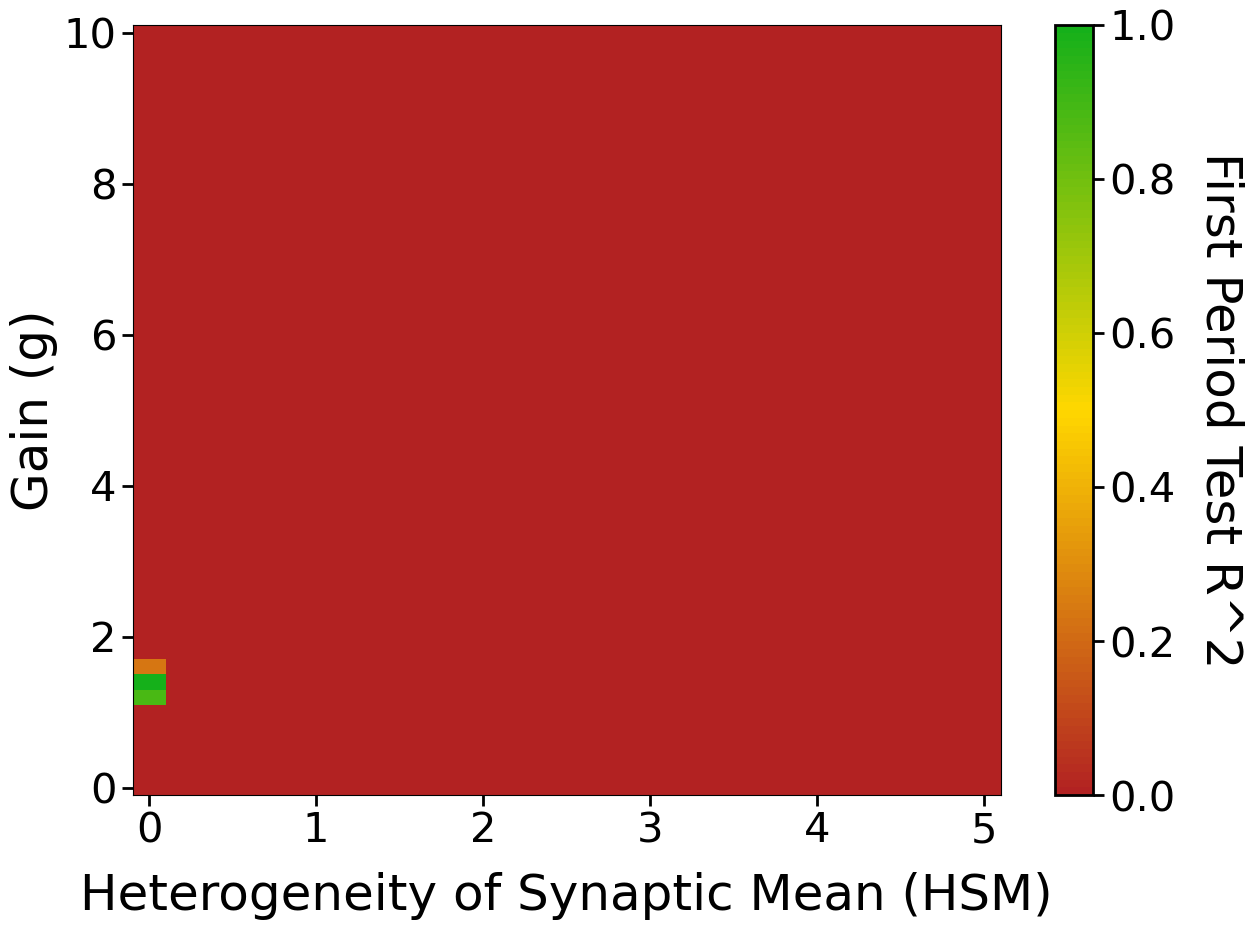


✓ Saved heatmap to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot zoomed in HSM 0-0.1\Zoomed_in_W_first_period_Rsquared_testing_Heatmap_Gain_MSH_2026-03-23_13-54-11.png


In [13]:
# ============================================================================
# CREATE HEATMAP for multiple trial from TR1
# ============================================================================

from matplotlib.ticker import MaxNLocator

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2


# Custom colormap
dark_red = "#8B0000"
white = "white"
dark_green = "#013220"

dark_red      = "#8B0000"
firebrick     = "#B22222"
crimson       = "#DC143C"
indian_red    = "#CD5C5C"
light_coral   = "#F08080"
salmon        = "#FA8072"
tomato        = "#FF6347"
red           = "#FF0000"

gold          = "#FFD700"
dark_golden   = "#B8860B"
lemon         = "#FFF44F"

dark_orange     = "#FF8C00"
burnt_orange    = "#CC5500"
chocolate       = "#D2691E"
sienna          = "#A0522D"
coral           = "#FF7F50"
orange_red      = "#FF4500"
orange          = "#FFA500"


dark_green    = "#013220"
forest_green  = "#228B22"
sea_green     = "#2E8B57"
olive         = "#808000"
olive_drab    = "#6B8E23"
lime_green    = "#32CD32"
lime          = "#00FF00"
light_green   = "#90EE90"

####################CHANGING COLORS#############################
colors = [firebrick, gold, "xkcd:green"]  # for test after training
colors_averages = [red, lemon, dark_green] #for during training performance plot

n_bins = 100
cmap_name = 'custom_seismic'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

n_bins = 100
cmap_name = 'custom_seismic'
cm_averages = LinearSegmentedColormap.from_list(cmap_name, colors_averages, N=n_bins)

#cm = 'summer'

# Create DataFrame
df = pd.DataFrame({
    'G': gains,
    'W': weights_seeds,
    'I': init_seeds,
    'MSH': MSHs,
    'Rsquareds': Rsquareds
})

# Remove any NaN values
df = df[~np.isnan(df['Rsquareds'])]

# print(f"\nDataFrame shape: {df.shape}")
# print(f"First few rows:")
# print(df.head(10))

# Average over W (seeds) for each (G, MSH) combination
df_mean = df.groupby(['G', 'W', 'MSH', 'I'], as_index=False)['Rsquareds'].mean()

# Create pivot table for heatmap
heatmap_data = df_mean.pivot_table(index='G', columns='MSH', values='Rsquareds', aggfunc='mean')

# print(f"\nHeatmap data shape: {heatmap_data.shape}")
# print(f"Heatmap data:")
# print(heatmap_data)


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_mean['Rsquareds'].min()
GLOBAL_VMAX = df_mean['Rsquareds'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

# Create heatmap
plt.figure(figsize=(14, 10))

# Use pcolormesh for heatmap
im = plt.pcolormesh(
    heatmap_data.columns, 
    heatmap_data.index, 
    heatmap_data.values,
    shading='auto', 
    cmap=cm, 
    vmin=0.0,
    vmax=1.0
)

#for average during training
#Use pcolormesh for heatmap
# im = plt.pcolormesh(
#     heatmap_data.columns, 
#     heatmap_data.index, 
#     heatmap_data.values,
#     shading='auto', 
#     cmap=cm_averages, 
#     vmin=0, 
#     vmax=1.00
# )



# Add colorbar
cbar = plt.colorbar(im, label='First Period Test R^2')
# cbar = plt.colorbar(im, label='First Period Training R^2')

#cbar = plt.colorbar(im, label='Average Performance Testing R^2')
#cbar = plt.colorbar(im, label='Average Performance Training R^2')

cbar.set_label('First Period Test R^2', rotation=270, labelpad=50)

# # Add values as text on heatmap (optional)
# for i, gain_val in enumerate(heatmap_data.index):
#     for j, msh_val in enumerate(heatmap_data.columns):
#         value = heatmap_data.iloc[i, j]
#         if value < 0.01:
#             if not np.isnan(value):
#                 plt.text(msh_val, gain_val, f'', 
#                         ha='center', va='center', fontsize=8, 
#                         color='black',
#                         rotation=270)

#         else:             
#             # value = heatmap_data.iloc[i, j]
#             if not np.isnan(value):
#                 plt.text(msh_val, gain_val, f'{value:.2f}', 
#                         ha='center', va='center', fontsize=10, 
#                         color='white',
#                         rotation=270)
#                         # color='white' if value > heatmap_data.values.mean() else 'black')



plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad=15)
plt.ylabel('Gain (g)')
#plt.title('First Period Test R^2: Gain vs HSM')
#plt.title('First Period Training R^2: Gain vs HSM')

#plt.title('Average R^2 testing: Gain vs HSM')
#plt.title('Average R^2 training: Gain vs HSM')



# Save figure
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = f"Zoomed_in_W_first_period_Rsquared_testing_Heatmap_Gain_MSH_{timestamp}.png"
#filename = f"First_period_Rsquared_training_Heatmap_Gain_MSH_{timestamp}.png"

#filename = f"Averages_performance_after_training_Heatmap_Gain_MSH_{timestamp}.png"
#filename = f"Averages_performance_during_training_Heatmap_Gain_MSH_{timestamp}.png"



#testing
# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot intended W matrix or HSM",
#     filename
# )

#for zoomed in HSM
filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot zoomed in HSM 0-0.1",
    filename
)

# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages during training heatmap performance",
#     filename
# )

# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages after training heatmap performance",
#     filename
# )


#for increasing the width of the plot edge line
# ax = plt.gca()
# ax.tick_params(axis='x', rotation=300)


for spine in ax.spines.values():
    spine.set_linewidth(2)

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))


plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved heatmap to: {filepath}")



<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24176\1938998021.py:73: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('standard deviation ($\sigma$) of Rsquareds', rotation=270, labelpad=20)


7.720635916211923 0.0


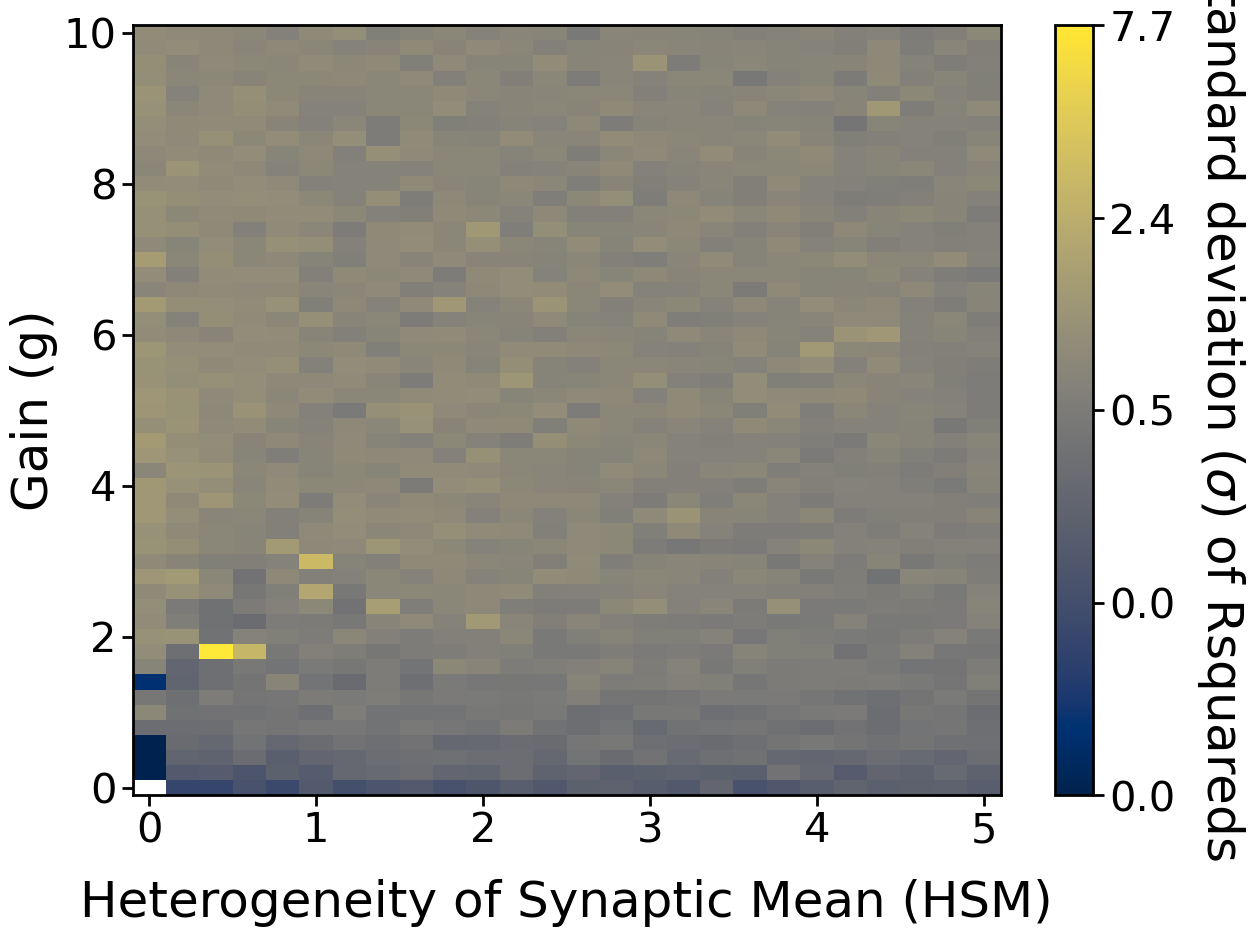

In [15]:
#Std heatmap

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2



# Create DataFrame
df = pd.DataFrame({
    'G': gains,
    'W': weights_seeds,
    'I': init_seeds,
    'MSH': MSHs,
    'Rsquareds': Rsquareds
})



# Average over W and I for each (G, MSH) combination
# (If you want to ignore W and I completely, comment the line below and uncomment the next one)
#df_mean = df.groupby(['G', 'MSH'], as_index=False)['L'].mean()
df_mean = df.groupby(['G', 'W', 'I', 'MSH'], as_index=False)['Rsquareds'].mean()
df_std = df_mean.groupby(['G', 'MSH'], as_index=False)['Rsquareds'].std()


heatmap_data = df_std.pivot_table(index='G', columns='MSH', values='Rsquareds', aggfunc='mean')


# Set the (G=0, MSH=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_std['Rsquareds'].min()
GLOBAL_VMAX = df_std['Rsquareds'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

plt.figure(figsize=(14,10))

# Use GLOBAL vmin/vmax instead of data-specific min/max
norm = PowerNorm(
    gamma=0.25,
    vmin=GLOBAL_VMIN,  # Changed
    vmax=GLOBAL_VMAX   # Changed
)

cmap = plt.get_cmap('cividis').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    shading='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('standard deviation ($\sigma$) of Rsquareds', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)  # Adjust position if needed


cbar.ax.minorticks_off()

n_ticks = 5  
tick_positions = np.linspace(0, 1, n_ticks)

# Use GLOBAL values for tick calculation
data_min = GLOBAL_VMIN  # Changed
data_max = GLOBAL_VMAX  # Changed
gamma = 0.25
tick_values = data_min + (data_max - data_min) * (tick_positions ** (1/gamma))

rounded_labels = [f"{v:.01f}" for v in tick_values]

cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)



# plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
#                shading='auto', cmap='inferno')
# plt.colorbar(label='$\sigma$ of PR')
plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad = 20)
plt.ylabel('Gain (g)')
# plt.title('Uncertainty of PR')
# plt.title('Heatmap of MLEs vs MSHs per Gains')


#for increasing the width of the plot edge line
# ax = plt.gca()
# ax.tick_params(axis='x', rotation=300)


#for increasing the width of the plot edge line
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"LLE_1000N_0.2s_shortened_uncertainty_{timestamp}.png"
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\ALL trials performance plot zoomed in HSM 0-0.1", filename)
plt.savefig(filepath, dpi=300)

plt.show()

[1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ]
[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1  ]
[9]
[0 1 2 3]


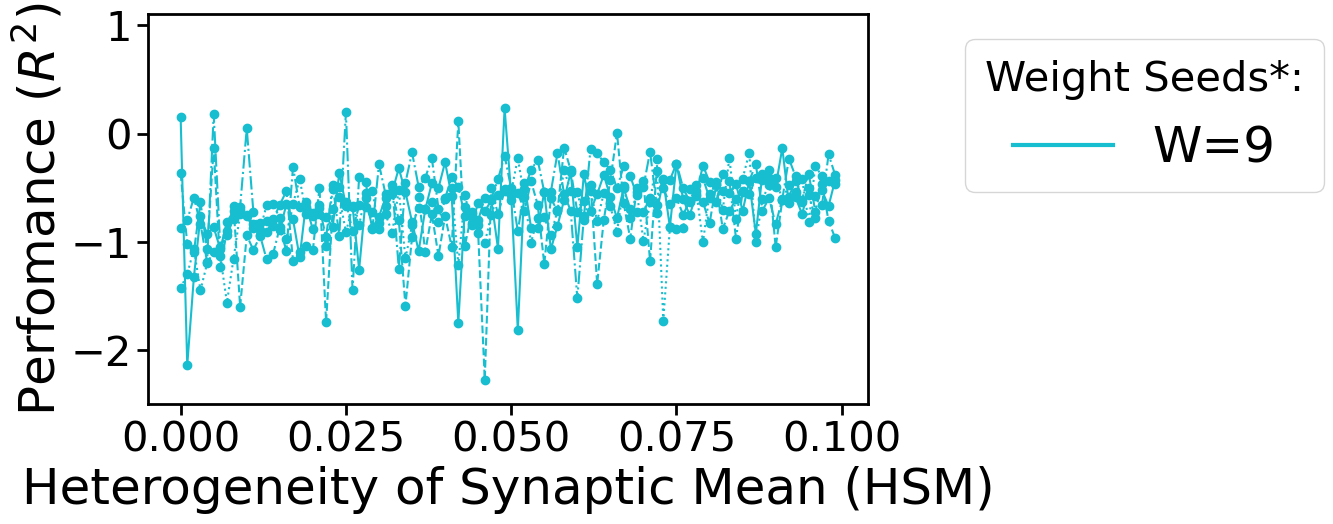

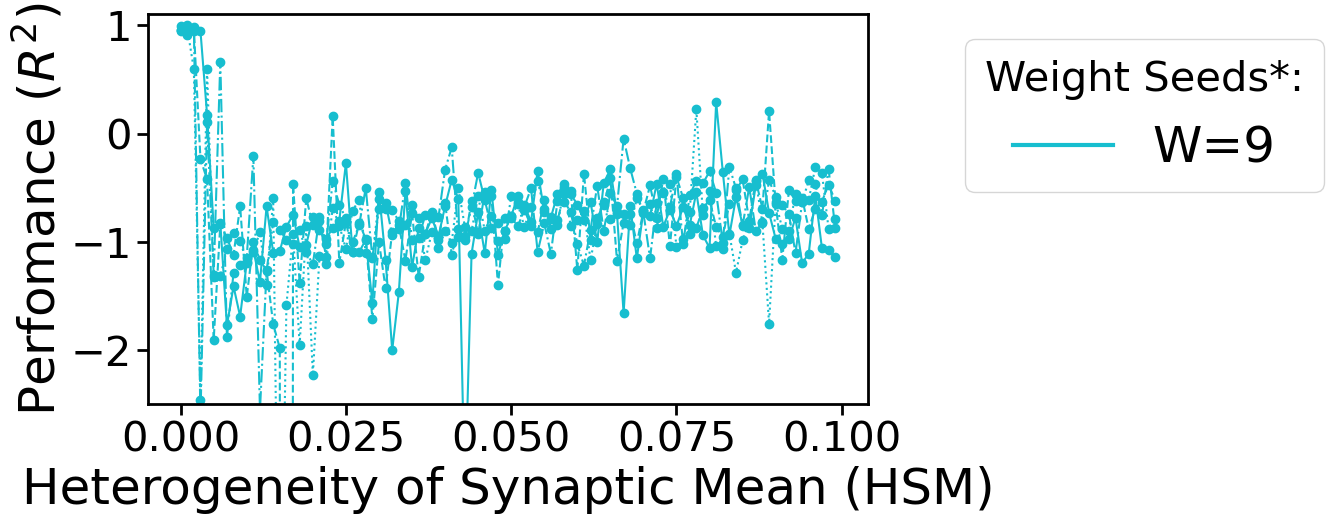

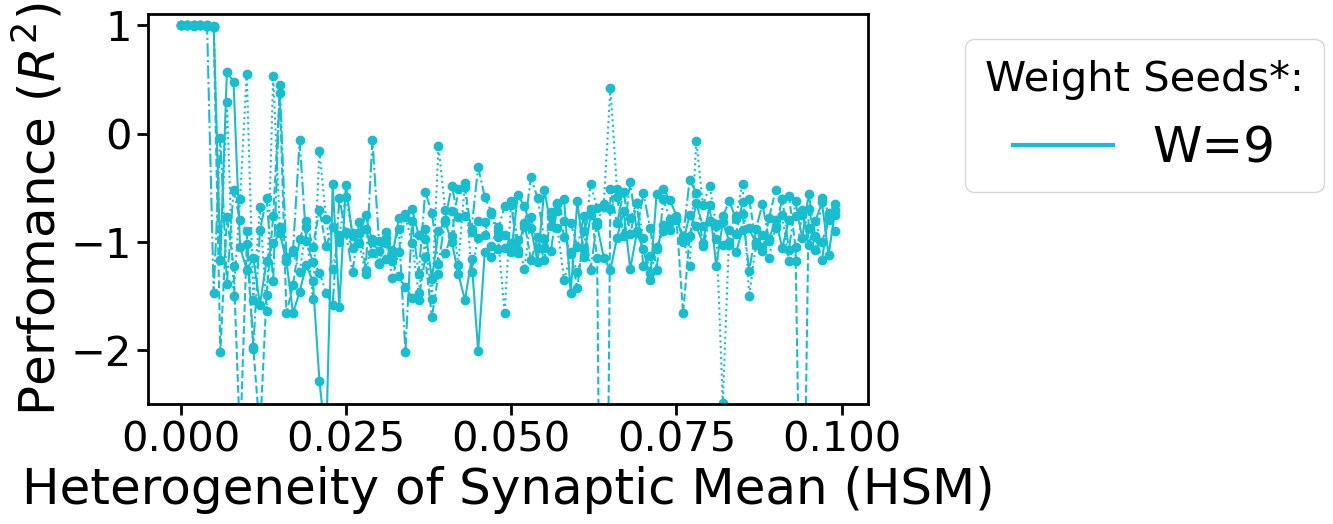

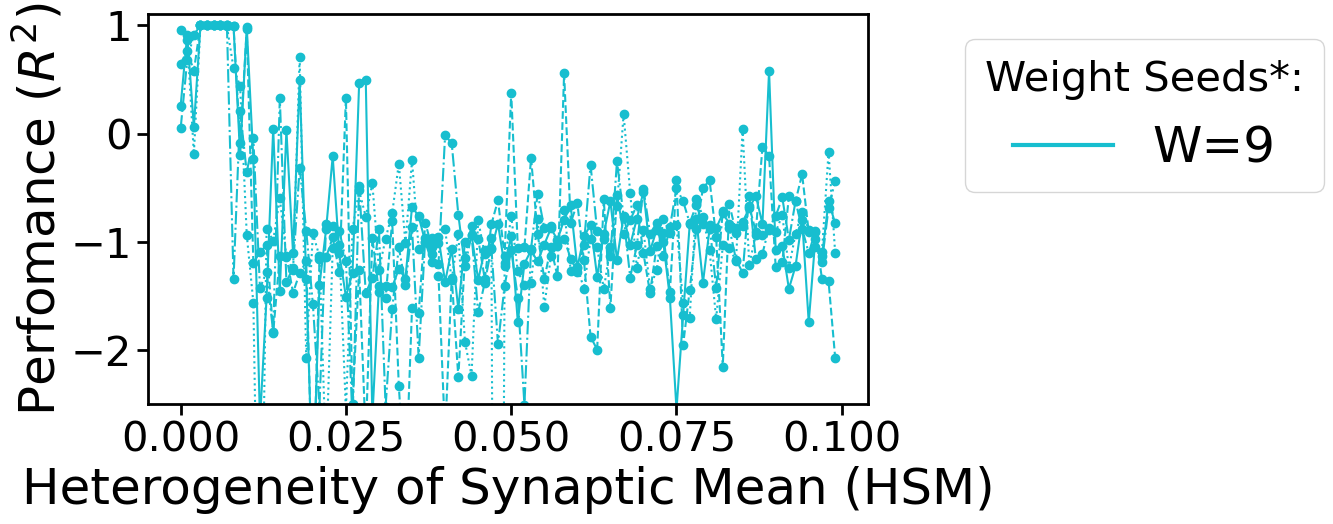

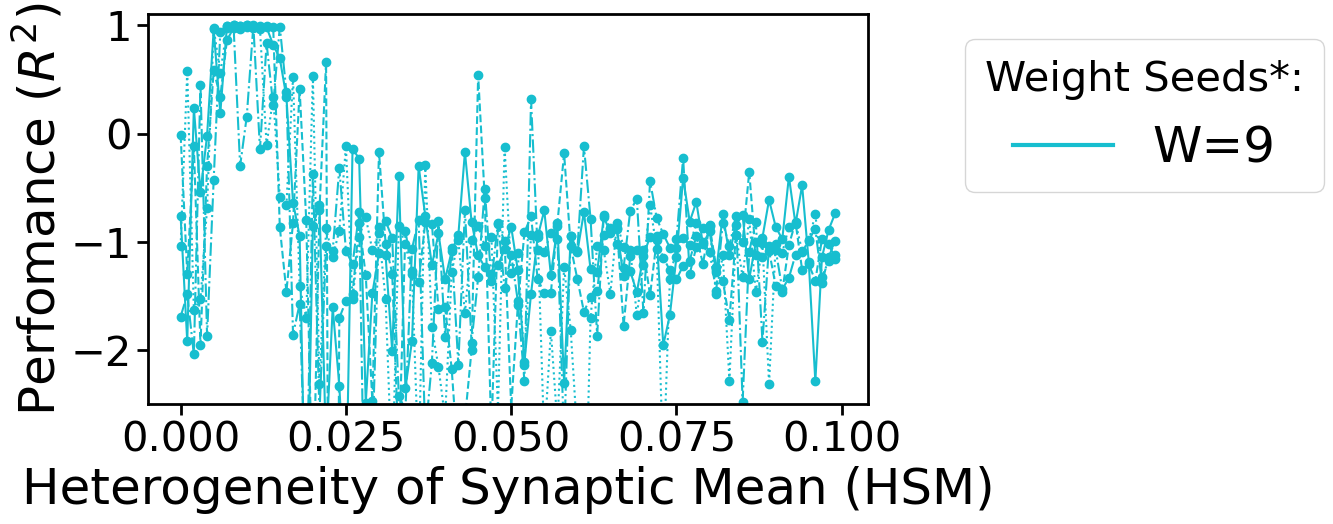

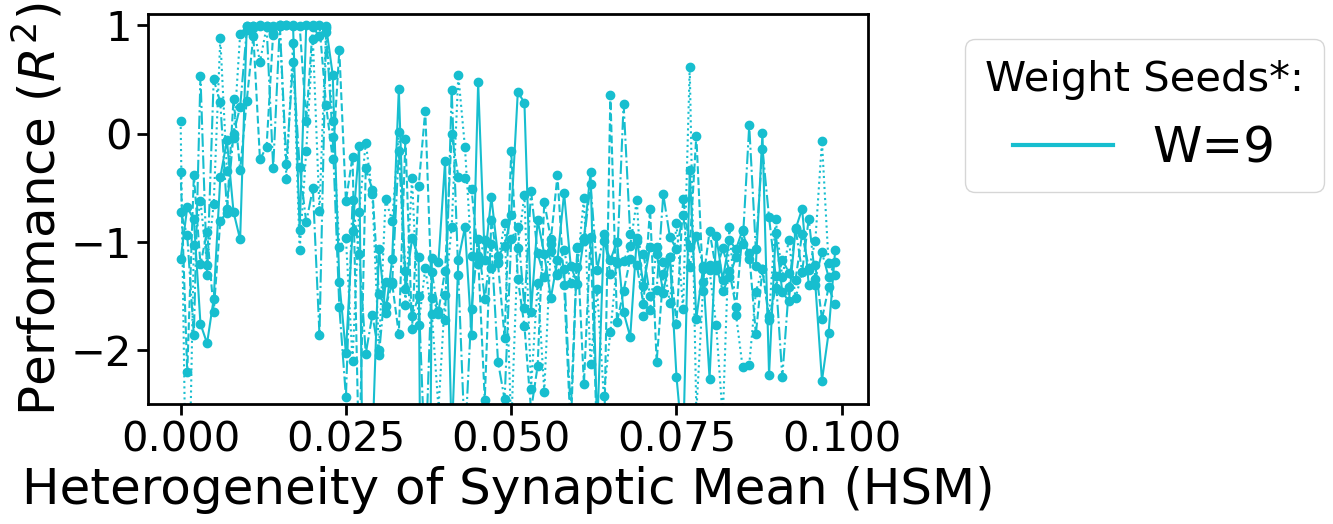

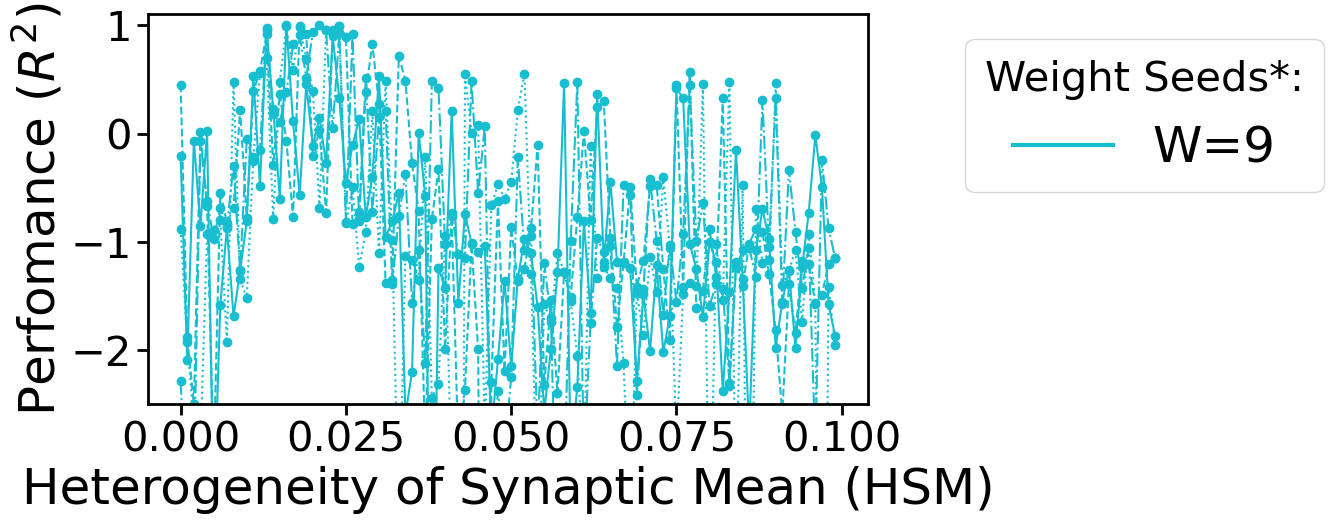

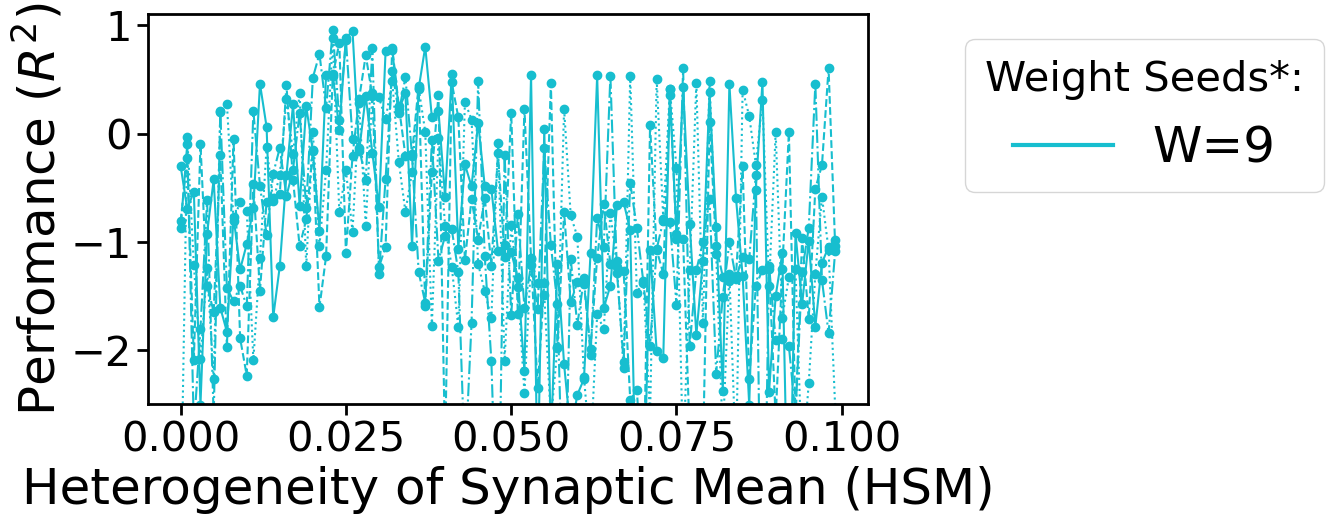

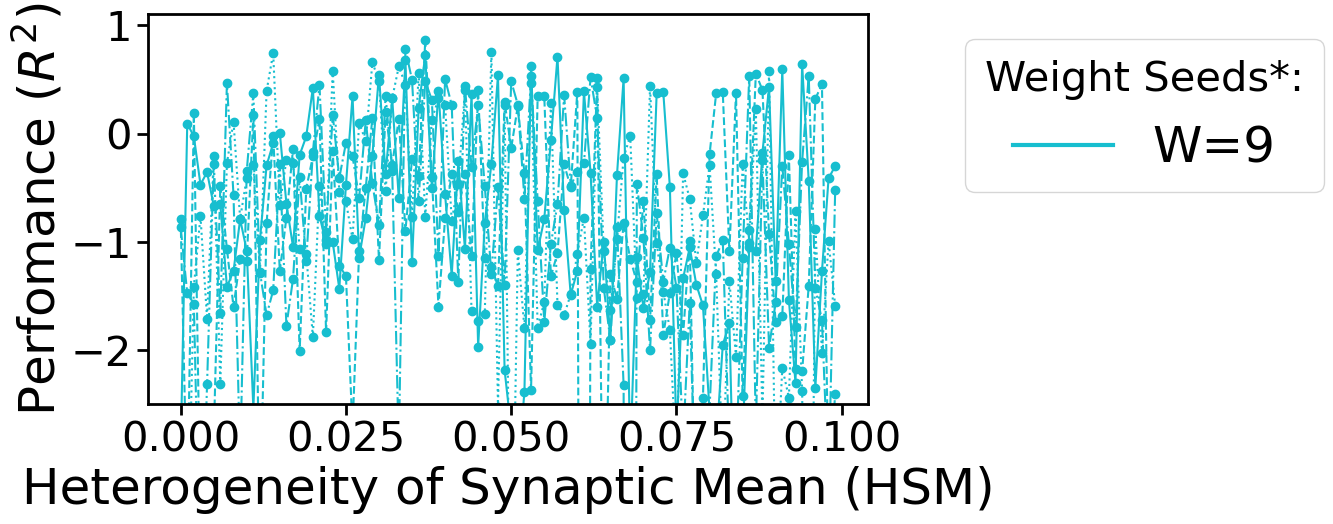

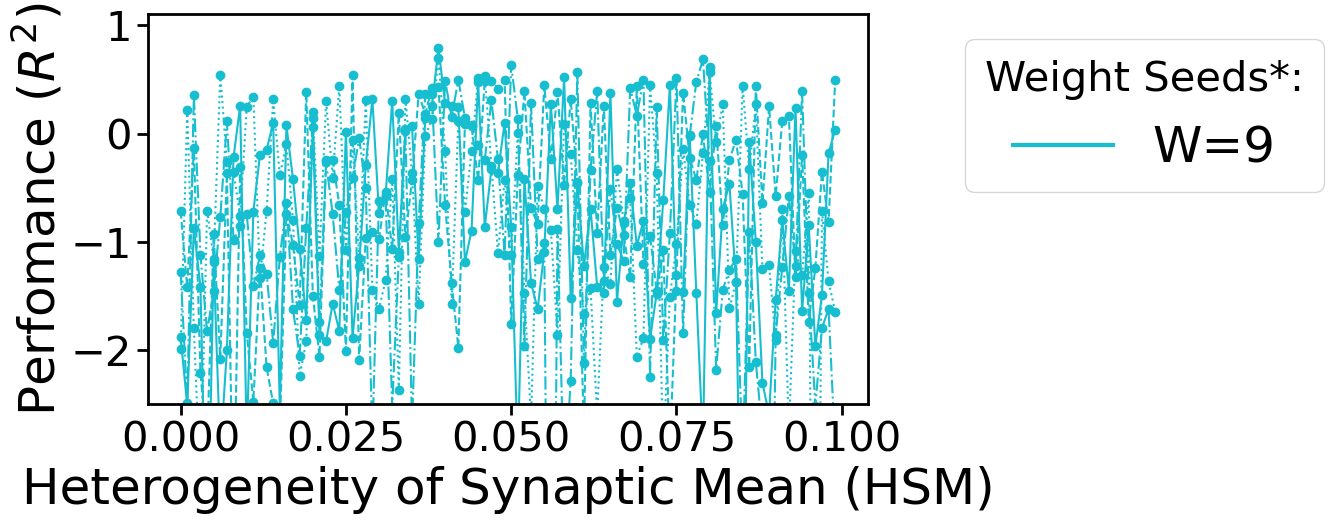

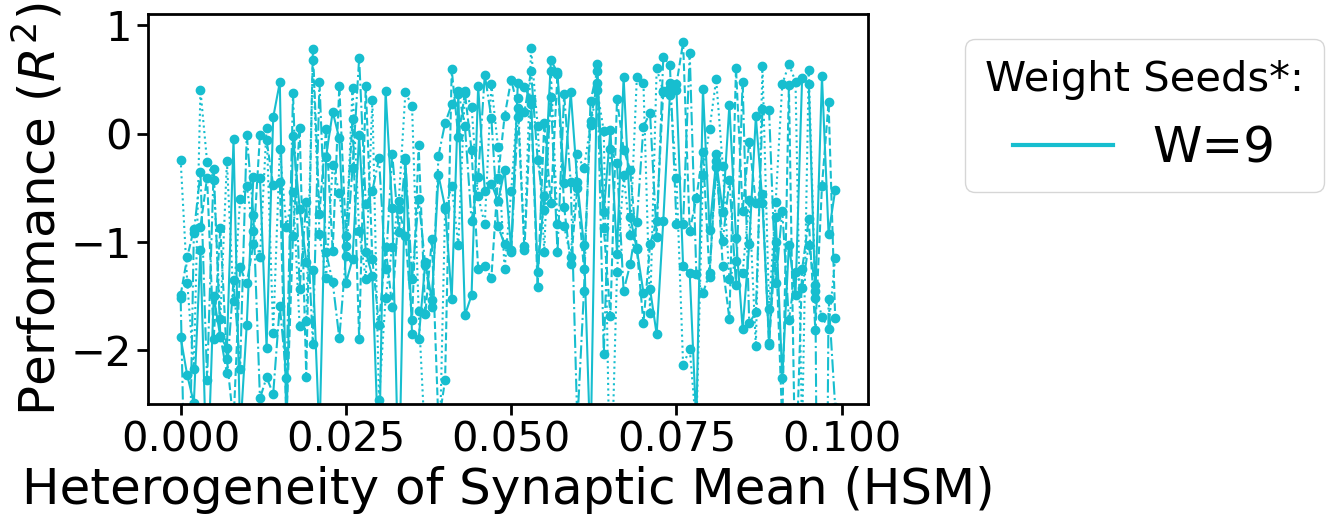

In [17]:
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2

# # Create DataFrame
# df = pd.DataFrame({
#     'G': gains,
#     'W': weights_seeds,
#     'I': init_seeds,
#     'MSH': MSHs,
#     'Rsquareds': Rsquareds
# })


unique_Gains = np.unique(gains)
print(unique_Gains)

unique_MSHs = np.unique(MSHs)

print(unique_MSHs)

# Colors for weight seeds


unique_weights_seeds = np.unique(weights_seeds)
unique_weights_seeds = np.array([9])
print(unique_weights_seeds)

color_map = {ws: plt.cm.tab10(i % 10) for i, ws in enumerate(weights_seeds)}

# Linestyles for initialisation seeds
init_seeds_unique = np.unique(init_seeds)
print(init_seeds_unique)

linestyle_tuple = [
    ('solid', 'solid'),
    ('dotted', 'dotted'),
    ('dashed', 'dashed'),
    ('dashdot', 'dashdot'),
    ('loosely dotted', (0, (1, 10))),
    ('densely dotted', (0, (1, 1))),
    ('loosely dashed', (0, (5, 10))),
    ('densely dashed', (0, (5, 1))),
    ('dashdotted', (0, (3, 5, 1, 5))),
    ('densely dashdotted', (0, (3, 1, 1, 1)))
]
linestyle_map = {is_: linestyle_tuple[i % len(linestyle_tuple)][1]
                 for i, is_ in enumerate(init_seeds_unique)} #not completely sure how this works, but I know what it gives qua result



# Loop over all combinations of seeds and gains
for i, gain in enumerate(unique_Gains):
    
    plt.figure(figsize=(12,5))
    for w_seed in unique_weights_seeds:

        if w_seed in unique_weights_seeds:
        
            for i_seed in init_seeds_unique:
                # Find indices matching this combination
                mask = (weights_seeds == w_seed) & (init_seeds == i_seed) & (gains == gain)
                if not np.any(mask):
                    continue
        
                # Extract LLEs for this pair
                rsquareds = np.array(Rsquareds)[mask]
        
                # Sanity check: must align with unique_bounds length
                if len(rsquareds) != len(unique_MSHs):
                    print(f"Skipping w={w_seed}, i={i_seed}, wrong length {len(rsquareds)}")
                    continue
        
                # Plot
                
                plt.plot(unique_MSHs[:-1], rsquareds[:-1],
                         color=color_map[w_seed],
                         linestyle=linestyle_map[i_seed],
                         marker='o')
                         #label=f"W={w_seed}, I={i_seed}") put this line back if you wanna see all the init seeds in the legend as well

    #Create legend handles only for weight seeds (colours)
    handles = [plt.Line2D([0], [0], color=color_map[w], lw=3, label=f"W={w}") for w in unique_weights_seeds]

    
    
    plt.xlabel("Heterogeneity of Synaptic Mean (HSM)")
    plt.ylabel(f"Perfomance ($R^2$)")
    plt.ylim(-2.5, 1.1)
    #plt.title(f"Maximal Lyapunov Exponent for 1000 N RNN and gain of {gain:.1f}")
    #plt.grid(True)
    plt.legend(handles=handles, title="Weight Seeds*:", bbox_to_anchor=(1.10, 1))
    # plt.tight_layout()

     #for increasing the width of the plot edge line
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    
    #for increasing the width of the edge line of the colour bar
    cbar.outline.set_linewidth(2)
    
    filename = f"R^2 Figure {i} for gain {gain:.1f}.png"
    #change path depending on 10% connectivity or not
    filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Individual R2 for separate trials", filename)
    plt.subplots_adjust(left = 0.2, right=0.8, top = 0.9, bottom = 0.12) #leaving space for legend
    plt.savefig(filepath, dpi = 300, bbox_inches='tight')
    #plt.savefig(filepath, dpi=300, bbox_inches='tight') #save each figure
    
    plt.show()

In [87]:
MSHs = np.arange(0, 5.2, 0.2)
gains = np.arange(0, 10.2, 0.2)
print(len(MSHs))
print(len(gains))
print(len(MSHs)*len(gains))

26
51
1326


In [129]:
MSHs = np.arange(0, 0.101, 0.001)
gains = np.arange(1, 3.2, 0.2)
print(MSHs, len(MSHs))
print(gains, len(gains))
print(len(MSHs)*len(gains))

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1  ] 101
[1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ] 11
1111


In [71]:
# ============================================================================
# CREATE HEATMAP for single trial
# ============================================================================

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['legend.title_fontsize'] = 14

# Custom colormap
dark_red = "#8B0000"
white = "white"
dark_green = "#013220"

dark_red      = "#8B0000"
firebrick     = "#B22222"
crimson       = "#DC143C"
indian_red    = "#CD5C5C"
light_coral   = "#F08080"
salmon        = "#FA8072"
tomato        = "#FF6347"
red           = "#FF0000"

gold          = "#FFD700"
dark_golden   = "#B8860B"
lemon         = "#FFF44F"

dark_orange     = "#FF8C00"
burnt_orange    = "#CC5500"
chocolate       = "#D2691E"
sienna          = "#A0522D"
coral           = "#FF7F50"
orange_red      = "#FF4500"
orange          = "#FFA500"


dark_green    = "#013220"
forest_green  = "#228B22"
sea_green     = "#2E8B57"
olive         = "#808000"
olive_drab    = "#6B8E23"
lime_green    = "#32CD32"
lime          = "#00FF00"
light_green   = "#90EE90"

####################CHANGING COLORS#############################
colors = [firebrick, gold, "xkcd:green"]  # for test after training
colors_averages = [red, lemon, dark_green] #for during training performance plot

n_bins = 100
cmap_name = 'custom_seismic'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

n_bins = 100
cmap_name = 'custom_seismic'
cm_averages = LinearSegmentedColormap.from_list(cmap_name, colors_averages, N=n_bins)

#cm = 'summer'

# Create DataFrame
df = pd.DataFrame({
    'G': gains,
    'W': weights_seeds,
    'I': init_seeds
    'MSH': MSHs,
    'Rsquareds': Rsquareds
})

# Remove any NaN values
df = df[~np.isnan(df['Rsquareds'])]

# print(f"\nDataFrame shape: {df.shape}")
# print(f"First few rows:")
# print(df.head(10))

# Average over W (seeds) for each (G, MSH) combination
df_mean = df.groupby(['G', 'MSH'], as_index=False)['Rsquareds'].mean()

# print(f"\nGrouped data shape: {df_mean.shape}")
# print(f"Grouped data:")
# print(df_mean)

# Create pivot table for heatmap
heatmap_data = df_mean.pivot_table(index='G', columns='MSH', values='Rsquareds', aggfunc='mean')

# print(f"\nHeatmap data shape: {heatmap_data.shape}")
# print(f"Heatmap data:")
# print(heatmap_data)

# Create heatmap
plt.figure(figsize=(8, 6))

# Use pcolormesh for heatmap
# im = plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
#                     shading='auto', cmap=cm, vmin=heatmap_data.values.min(), 
#                     vmax=heatmap_data.values.max())

#for average during training
#Use pcolormesh for heatmap
im = plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
                    shading='auto', cmap=cm_averages, vmin=0, 
                    vmax=1.00)



# Add colorbar
#cbar = plt.colorbar(im, label='First Period Test R^2')
# cbar = plt.colorbar(im, label='First Period Training R^2')

cbar = plt.colorbar(im, label='Average Performance Testing R^2')
#cbar = plt.colorbar(im, label='Average Performance Training R^2')



# Add values as text on heatmap (optional)
for i, gain_val in enumerate(heatmap_data.index):
    for j, msh_val in enumerate(heatmap_data.columns):
        value = heatmap_data.iloc[i, j]
        if value < 0:
            if not np.isnan(value):
                plt.text(msh_val, gain_val, f'', 
                        ha='center', va='center', fontsize=8, 
                        color='black')

        else:             
            # value = heatmap_data.iloc[i, j]
            if not np.isnan(value):
                plt.text(msh_val, gain_val, f'{value:.2f}', 
                        ha='center', va='center', fontsize=8, 
                        color='white')
                        # color='white' if value > heatmap_data.values.mean() else 'black')



plt.xlabel('Heterogeneity of Synaptic Mean (HSM)')
plt.ylabel('Gain')
#plt.title('First Period Test R^2: Gain vs HSM')
#plt.title('First Period Training R^2: Gain vs HSM')

plt.title('Average R^2 testing: Gain vs HSM')
#plt.title('Average R^2 training: Gain vs HSM')



# Save figure
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
#filename = f"First_period_Rsquared_testing_Heatmap_Gain_MSH_{timestamp}.png"
#filename = f"First_period_Rsquared_training_Heatmap_Gain_MSH_{timestamp}.png"

filename = f"Averages_performance_after_training_Heatmap_Gain_MSH_{timestamp}.png"
#filename = f"Averages_performance_during_training_Heatmap_Gain_MSH_{timestamp}.png"



# #testing
# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM after training heatmap performance",
#     filename
# )

# filepath = os.path.join(
#     r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages during training heatmap performance",
#     filename
# )

filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gains HSM averages after training heatmap performance",
    filename
)

plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved heatmap to: {filepath}")



SyntaxError: invalid syntax (290232825.py, line 68)

# J matrix comparison between initial and after training

In [230]:
# ============================================================================
# DIFFERENCES BEFORE AND AFTER TRAINING, INDIVIDUAL CASES
# ============================================================================

 


foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\VScode gainHSM zs vs sussillos target and Rsquareds during and after training"

#get all idx*.npz files
file_path = os.path.join(foldername, "idx013_gain1.2_MSH0.2_eta1.000_Dt0.2_20260201_193626.npz")


data = np.load(file_path)
J_initial = data['J_initial']
J_trained = data['J_trained']
w_out_initial = data['w_out_initial']
w_out_trained = data['w_out_trained']
gain = data['gain']
HSM = data['MSH']


# print(filepath, J_initial, J_initial.shape)
# print(filepath, J_trained, J_initial.shape)
# print(filepath, w_out_initial, w_out_initial.shape)
# print(filepath, w_out_trained, w_out_trained.shape)

mus_initial    = np.mean(J_initial, axis=1)
sigmas_initial = np.std(J_initial, axis=1)

mus_trained    = np.mean(J_trained, axis=1)
sigmas_trained = np.std(J_trained, axis=1)

mus_difference    = mus_trained - mus_initial
sigmas_difference = sigmas_trained - sigmas_initial
        
neuron_lin = np.linspace(1, 1000, 1000)

############## Plotting 
fig, axes = plt.subplots(3, 1, figsize=(24, 24))

# initial
axes[0].plot(neuron_lin, mus_initial, 'o', linewidth=2, label='Mean weight')
axes[0].set_xlabel('# of Neuron')
axes[0].set_ylabel('Mean ($\mu$)')
axes[0].set_title(f'mus initial with Gain={gain:.1f} and HSM={HSM:.1f}')
#axes[0].set_title(f'Training: gain={gain:.1f}, MSH={MSH:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# after training
axes[1].plot(neuron_lin, mus_trained, 'o', linewidth=2, label='Mean weight')
axes[1].set_xlabel('# of Neuron')
axes[1].set_ylabel('Mean ($\mu$)')
axes[1].set_title(f'mus trained with Gain={gain:.1f} and HSM={HSM:.1f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Difference
axes[2].plot(neuron_lin, mus_difference, 'k-', linewidth=2, label='Target')
axes[2].set_xlabel('# of Neuron')
axes[2].set_ylabel('shift in mean')
axes[1].set_title(f'mus difference')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
#fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
fig_filename = f"Mus_before_after_training_Gain={gain:.1f}_HSM={HSM:.1f}.png"
#######################CHECK THIS FILE PATH############################
fig_filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gain HSM J matrix plots",
    fig_filename
)
plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
plt.close()


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24944\4020510966.py:45: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Mean ($\mu$)')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24944\4020510966.py:54: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel('Mean ($\mu$)')


In [7]:
# ============================================================================
# DIFFERENCES BEFORE AND AFTER TRAINING w_out, ALL CASES
# ============================================================================
 
# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 32,
    'axes.labelsize': 28,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 20,
    'figure.titlesize': 32,
    'legend.title_fontsize': 28
})

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Zoomed HSM 0-0.1 performance plots\for differences in J plots"

files = glob.glob(os.path.join(foldername, "idx*.npz"))
files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

for i, filepath in enumerate(files):

    data = np.load(filepath)
    J_initial       = data['J_initial']
    J_trained       = data['J_trained']
    w_out_initial   = data['w_out_initial']
    w_out_trained   = data['w_out_trained']
    gain            = data['gain']
    HSM             = data['MSH']

    print(J_initial.shape)

    mus_initial    = np.mean(w_out_initial, axis=1)
    sigmas_initial = np.std(w_out_initial, axis=1)
    mus_trained    = np.mean(w_out_trained, axis=1)
    sigmas_trained = np.std(w_out_trained, axis=1)
    mus_difference    = np.abs(mus_trained - mus_initial)
    sigmas_difference = np.abs(sigmas_trained - sigmas_initial)

    neuron_lin = np.linspace(1, 1000, 1000)

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # === Top plot ===
    axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Initial $\mu_i$')
    axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='After training $\mu_i$')
    axes[0].set_xlabel('# of Neuron')
    axes[0].set_ylabel('Mean per neuron $\mu_i$')
    #axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[0].grid(True, alpha=0.3)
    #axes[0].set_ylim(-0.02, 0.02)

    # === Bottom plot ===
    axes[1].plot(neuron_lin, mus_difference, 'ko', linewidth=2, label='Difference')
    axes[1].set_xlabel('# of Neuron')
    axes[1].set_ylabel('absolute difference of $\mu_i$')
    axes[1].grid(True, alpha=0.3)
    #axes[1].yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    #axes[1].set_ylim(0.0016, 0.0042)

    plt.tight_layout()
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    fig_filename = f"idx{i:03d}_w_out_difference_gain{gain:.1f}_MSH{HSM}_{timestamp}.png"
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\w_output matrix difference training thesis",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()

print(f"Processed {len(files)} files")

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20428\3449790257.py:45: SyntaxWarning: invalid escape sequence '\m'
  axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Initial $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20428\3449790257.py:46: SyntaxWarning: invalid escape sequence '\m'
  axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='After training $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20428\3449790257.py:48: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Mean per neuron $\mu_i$')
C:\Users\Lenovo\AppData\Local\

(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
Processed 10 files


In [22]:
# ============================================================================
# DIFFERENCES BEFORE AND AFTER TRAINING J, ALL CASES
# ============================================================================
 
# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 32,
    'axes.labelsize': 28,        # x/y labels
    'xtick.labelsize': 24,       # x ticks
    'ytick.labelsize': 24,       # y ticks
    'legend.fontsize': 20,       # legend text
    'figure.titlesize': 32,      # suptitle (global title)
    'legend.title_fontsize': 28  # legend title
})


foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Zoomed HSM 0-0.1 performance plots"

files = glob.glob(os.path.join(foldername, "idx*.npz"))
#files = glob.glob(os.path.join(foldername, "idx000_gain1.4_MSH0.00_w_seed9_i_seed0_20260325_120919.npz"))

files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

for i, filepath in enumerate(files):

    data = np.load(filepath)
    J_initial       = data['J_initial']
    J_trained       = data['J_trained']
    w_out_initial   = data['w_out_initial']
    w_out_trained   = data['w_out_trained']
    gain            = data['gain']
    HSM             = data['MSH']

    print(J_initial.shape)

    mus_initial    = np.mean(J_initial, axis=1)
    sigmas_initial = np.std(J_initial, axis=1)
    mus_trained    = np.mean(J_trained, axis=1)
    sigmas_trained = np.std(J_trained, axis=1)
    mus_difference    = np.abs(mus_trained - mus_initial)
    sigmas_difference = np.abs(sigmas_trained - sigmas_initial)

    neuron_lin = np.linspace(1, 1000, 1000)

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Initial $\mu_i$')
    axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='After training $\mu_i$')
    axes[0].set_xlabel('# of Neuron')
    axes[0].set_ylabel('Mean per neuron $\mu_i$')
    #axes[0].set_title('mus initial')
    axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-0.02, 0.02)

    # axes[1].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='Means trained')
    # axes[1].set_xlabel('# of Neuron')
    # axes[1].set_ylabel('Mean (mu)')
    # axes[1].set_title('mus trained')
    # axes[1].legend()
    # axes[1].grid(True, alpha=0.3)

    axes[1].plot(neuron_lin, mus_difference, 'ko', linewidth=2, label='Difference')
    axes[1].set_xlabel('# of Neuron')
    axes[1].set_ylabel('Absolute difference of $\mu_i$')
    #axes[1].set_title('mus difference')   # <-- was axes[1] by mistake in your original
    #axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    axes[1].set_ylim(0.0015, 0.003)

    plt.tight_layout()
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    fig_filename = f"idx{i:03d}_J_difference_gain{gain:.1f}_MSH{HSM}_{timestamp}.png"
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\THESIS J matrices differences",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()

print(f"Processed {len(files)} files")

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26636\2638882147.py:47: SyntaxWarning: invalid escape sequence '\m'
  axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Initial $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26636\2638882147.py:48: SyntaxWarning: invalid escape sequence '\m'
  axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='After training $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26636\2638882147.py:50: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Mean per neuron $\mu_i$')
C:\Users\Lenovo\AppData\Local\

(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)
Processed 46 files


In [50]:
# ============================================================================
# DIFFERENCES BEFORE AND AFTER TRAINING w, ALL CASES
# ============================================================================
 
# === Global plot style ===
plt.rcParams.update({
    'axes.titlesize': 32,
    'axes.labelsize': 28,        # x/y labels
    'xtick.labelsize': 24,       # x ticks
    'ytick.labelsize': 24,       # y ticks
    'legend.fontsize': 20,       # legend text
    'figure.titlesize': 32,      # suptitle (global title)
    'legend.title_fontsize': 28  # legend title
})


foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\Zoomed HSM 0-0.1 performance plots"

# files = glob.glob(os.path.join(foldername, "idx*.npz"))

files = glob.glob(os.path.join(foldername, "idx000_gain1.4_MSH0.01_w_seed9_i_seed0_20260325_120919.npz"))
files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

for i, filepath in enumerate(files):

    data = np.load(filepath)
    J_initial       = data['J_initial']
    J_trained       = data['J_trained']
    w_out_initial   = data['w_out_initial']
    w_out_trained   = data['w_out_trained']
    gain            = data['gain']
    HSM             = data['MSH']

    print(J_initial.shape)

    mus_initial    = np.mean(w_out_initial, axis=1)
    sigmas_initial = np.std(w_out_initial, axis=1)
    mus_trained    = np.mean(w_out_trained, axis=1)
    sigmas_trained = np.std(w_out_trained, axis=1)
    mus_difference    = np.abs(mus_trained - mus_initial)
    sigmas_difference = np.abs(sigmas_trained - sigmas_initial)

    neuron_lin = np.linspace(1, 1000, 1000)

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    axes[0].plot(neuron_lin, mus_initial, 'ro', linewidth=2, label='Means initial')
    axes[0].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='Means trained')
    axes[0].set_xlabel('# of Neuron')
    axes[0].set_ylabel('Mean per neuron $\mu_i$')
    #axes[0].set_title('mus initial')
    #axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-0.08, 0.08)

    # axes[1].plot(neuron_lin, mus_trained, 'go', linewidth=2, label='Means trained')
    # axes[1].set_xlabel('# of Neuron')
    # axes[1].set_ylabel('Mean (mu)')
    # axes[1].set_title('mus trained')
    # axes[1].legend()
    # axes[1].grid(True, alpha=0.3)

    axes[1].plot(neuron_lin, mus_difference, 'ko', linewidth=2, label='Difference')
    axes[1].set_xlabel('# of Neuron')
    axes[1].set_ylabel('Absolute difference of $\mu_i$')
    #axes[1].set_title('mus difference')   # <-- was axes[1] by mistake in your original
    #axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    #axes[1].yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    axes[1].set_ylim(-0.01, 0.085)

    plt.tight_layout()
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    fig_filename = f"idx{i:03d}_w_out_difference_gain{gain:.1f}_MSH{HSM}_{timestamp}.png"
    fig_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\second w_output matrices differences",
        fig_filename
    )
    plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
    plt.close()

print(f"Processed {len(files)} files")

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15184\712601099.py:50: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel('Mean per neuron $\mu_i$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15184\712601099.py:65: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel('Absolute difference of $\mu_i$')


(1000, 1000)
Processed 1 files


In [37]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\Changing gain and HSM periodic target\VScode gainHSM0.0-5.0 zs vs sussillos target and Rsquareds during and after training"

files = glob.glob(os.path.join(foldername, "idx*.npz"))
#files = glob.glob(os.path.join(foldername, "idx053_gain2.0_MSH3.2_eta1.000_Dt0.2_20260204_215027.npz"))

files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

save_dir = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gain HSM J matrix plots"

for filepath in tqdm(files):
    data = np.load(filepath)

    J_initial = data['J_initial']
    J_trained = data['J_trained']
    gain = data['gain']
    HSM = data['MSH']

    mus_initial = np.mean(J_initial, axis=1)
    sigmas_initial = np.std(J_initial, axis=1)
    mus_trained = np.mean(J_trained, axis=1)
    sigmas_trained = np.std(J_trained, axis=1)

    mus_difference = mus_trained - mus_initial

    neuron_lin = np.arange(1, 1001)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8))

    axes[0].plot(neuron_lin, mus_initial, 'o')
    axes[0].set_title("mus initial")

    axes[1].plot(neuron_lin, mus_trained, 'o')
    axes[1].set_title("mus trained")

    axes[2].plot(neuron_lin, mus_difference, 'k-')
    axes[2].set_title("mus difference")

    plt.tight_layout()

    # Extract idx from filename
    idx = os.path.basename(filepath)[:6]   # "idx000"

    fig_filename = f"g={gain:.2f}_HSM={HSM}_mus.png"
    fig_filepath = os.path.join(save_dir, fig_filename)

    plt.savefig(fig_filepath, dpi=300, bbox_inches="tight")
    plt.close()

    plt.show()
    # print(mus_difference)
    


100%|██████████| 1348/1348 [19:41<00:00,  1.14it/s]


In [ ]:
print(mus_difference)

In [ ]:

  filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\Periodic target zs vs target, RMSEs data"
    os.makedirs(filepath, exist_ok=True)
    
    filename = f"idx{i:03d}_gain{gain:.1f}_MSH{MSH:.1f}_eta{eta:.3f}_Dt{Dt:.1f}_{timestamp}.npz"
    full_path = os.path.join(filepath, filename)
    
    np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        MSH=MSH,
        eta=eta,
        Dt=Dt,
        weights_seed=weights_seed,
        mean_test_mae=mean_mae,
        std_test_mae=std_mae,
        # Save ONLY first period test RMSE
        first_period_test_rmse=RMSE_first_period,
        # Also save all training RMSEs (for all periods)
        RMSEs_train=np.array(RMSEs_train),
        RMSEs_time_train=np.array(RMSEs_time_train),
        # Save all test RMSEs (for all periods) - for reference
        RMSEs_test_all_periods=np.array(RMSEs_test),
        RMSEs_time_test_all_periods=np.array(RMSEs_time_test)
    )
    




# previous code (old code)

[ 0.2  1.   1.5 10. ]


100%|██████████| 20000/20000 [01:12<00:00, 277.25it/s]


✓ Saved to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\0force_best_params_Dt1.981_eta0.708_20260123_163753.npz


<Figure size 1000x500 with 0 Axes>

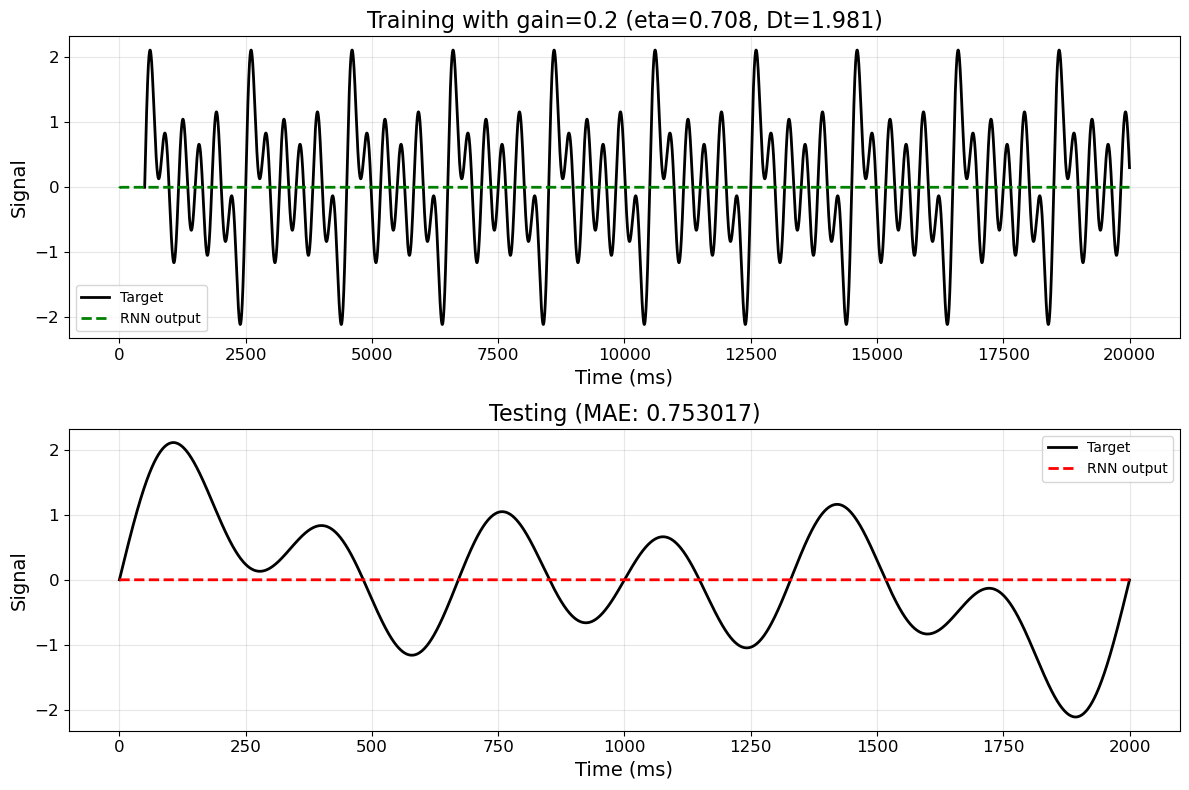

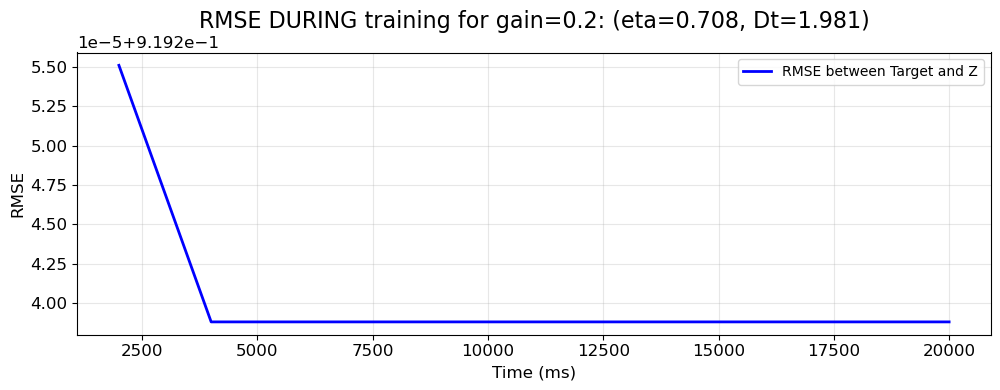

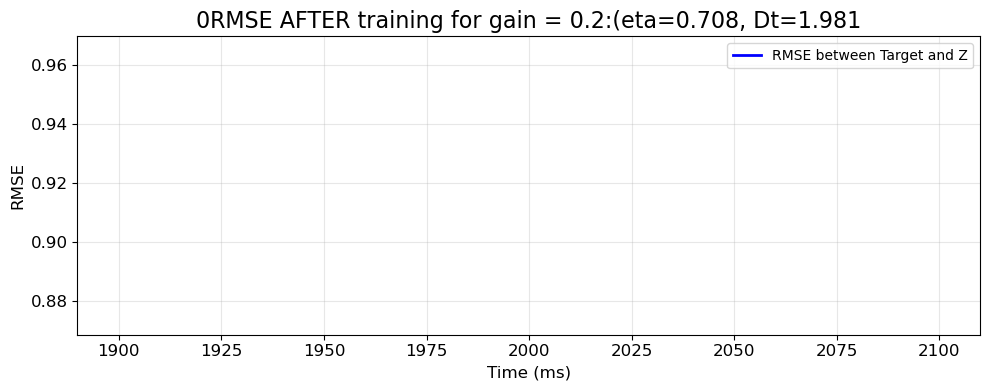

100%|██████████| 20000/20000 [00:05<00:00, 3997.92it/s]


✓ Saved to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\1force_best_params_Dt0.633_eta0.027_20260123_164853.npz


<Figure size 1000x500 with 0 Axes>

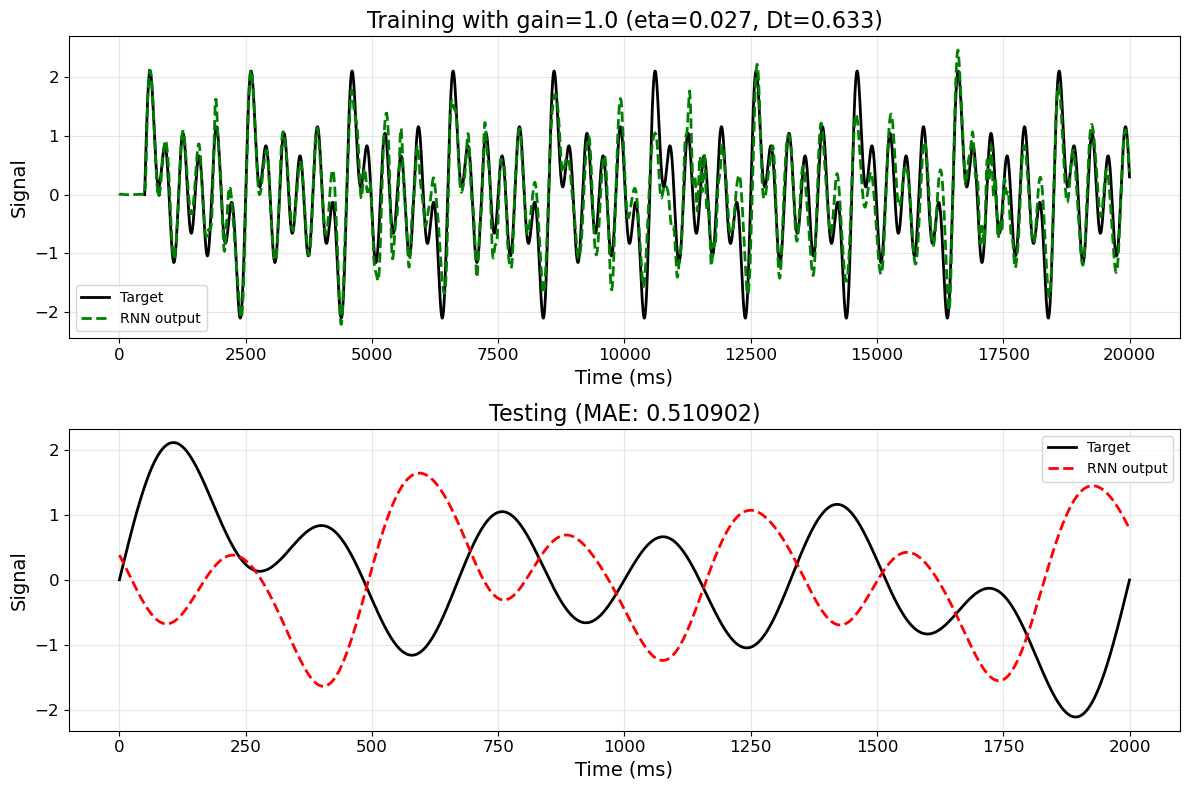

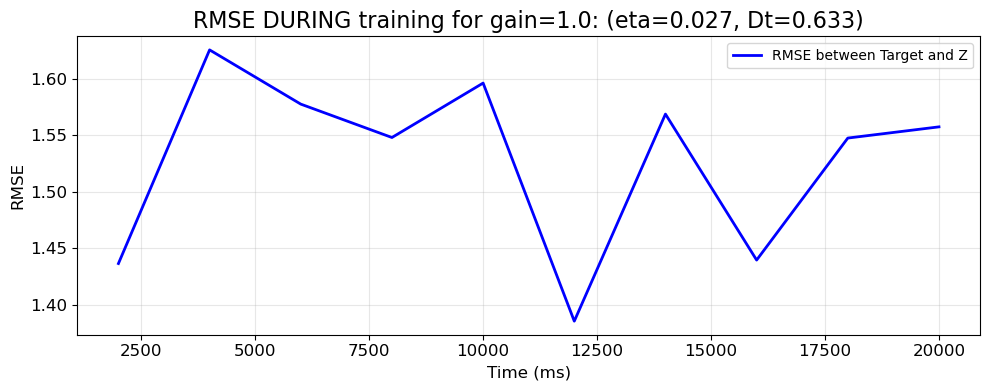

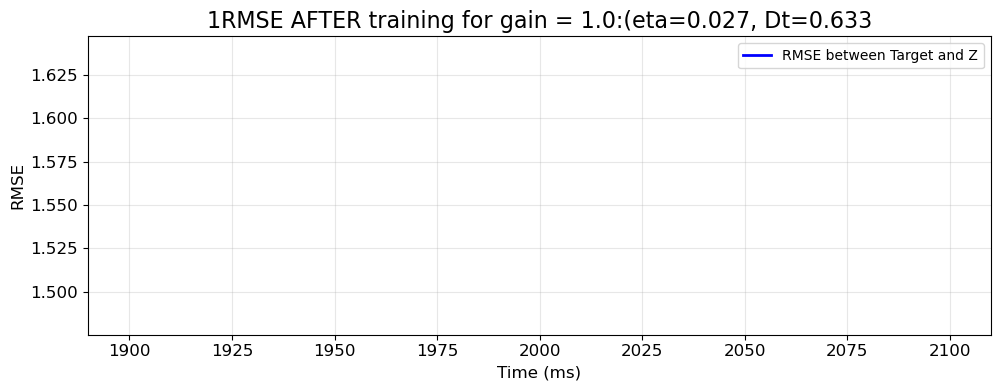

100%|██████████| 20000/20000 [00:06<00:00, 2900.98it/s]


✓ Saved to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt0.801_eta0.558_20260123_165756.npz


<Figure size 1000x500 with 0 Axes>

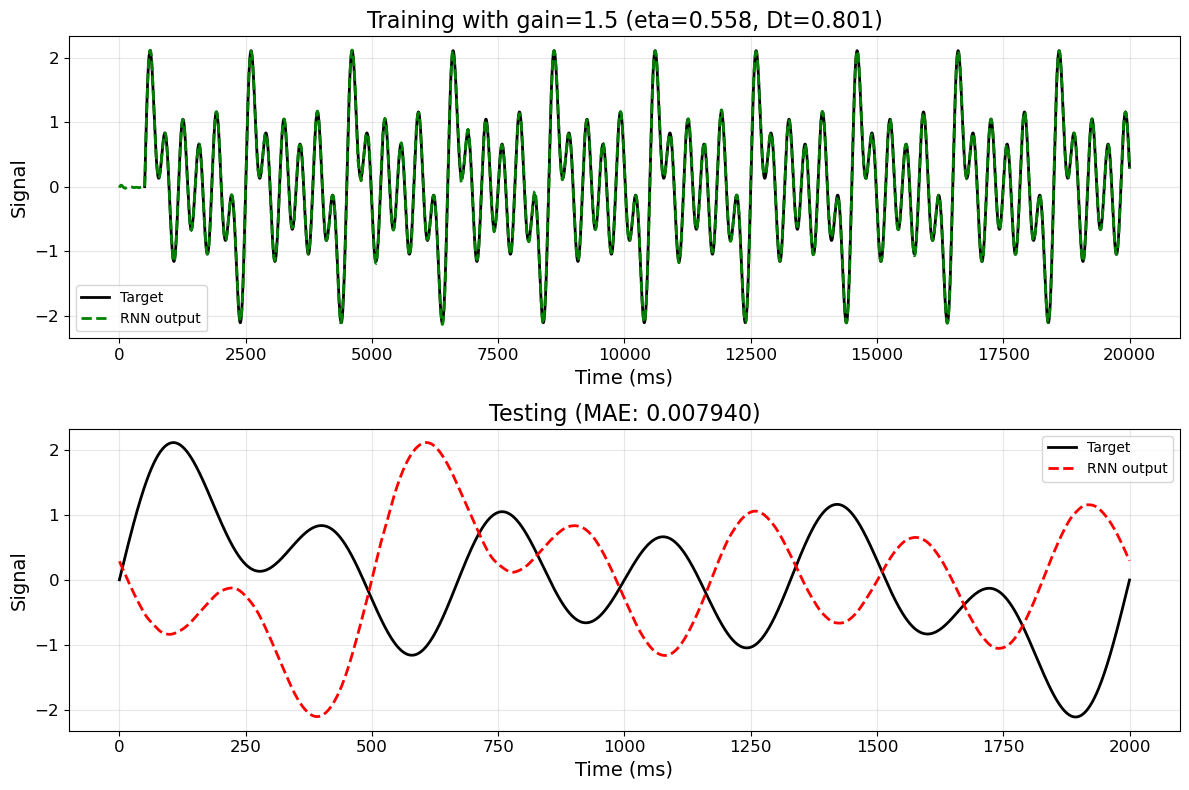

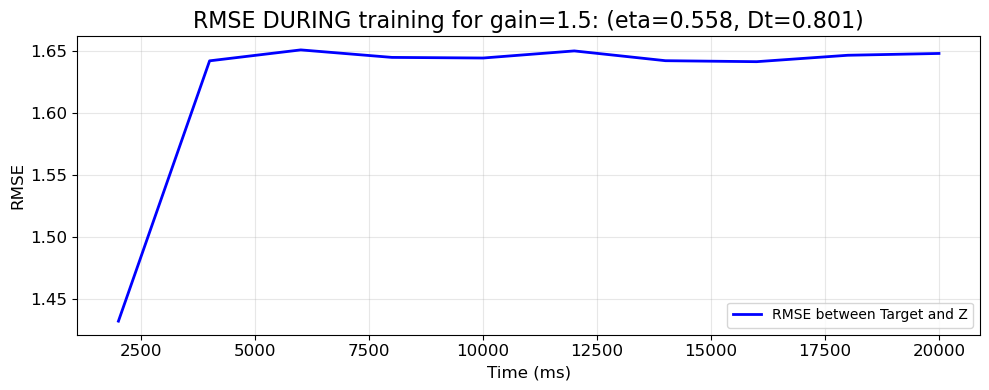

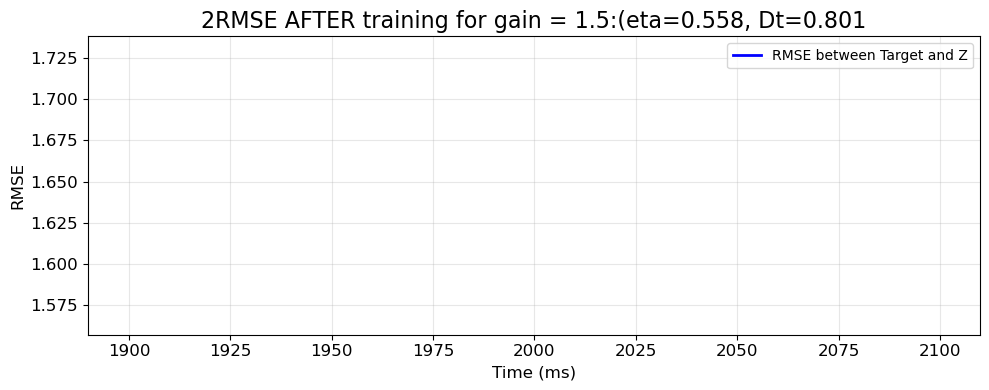

100%|██████████| 20000/20000 [00:05<00:00, 3643.32it/s]


✓ Saved to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\3force_best_params_Dt3.257_eta0.176_20260123_170115.npz


<Figure size 1000x500 with 0 Axes>

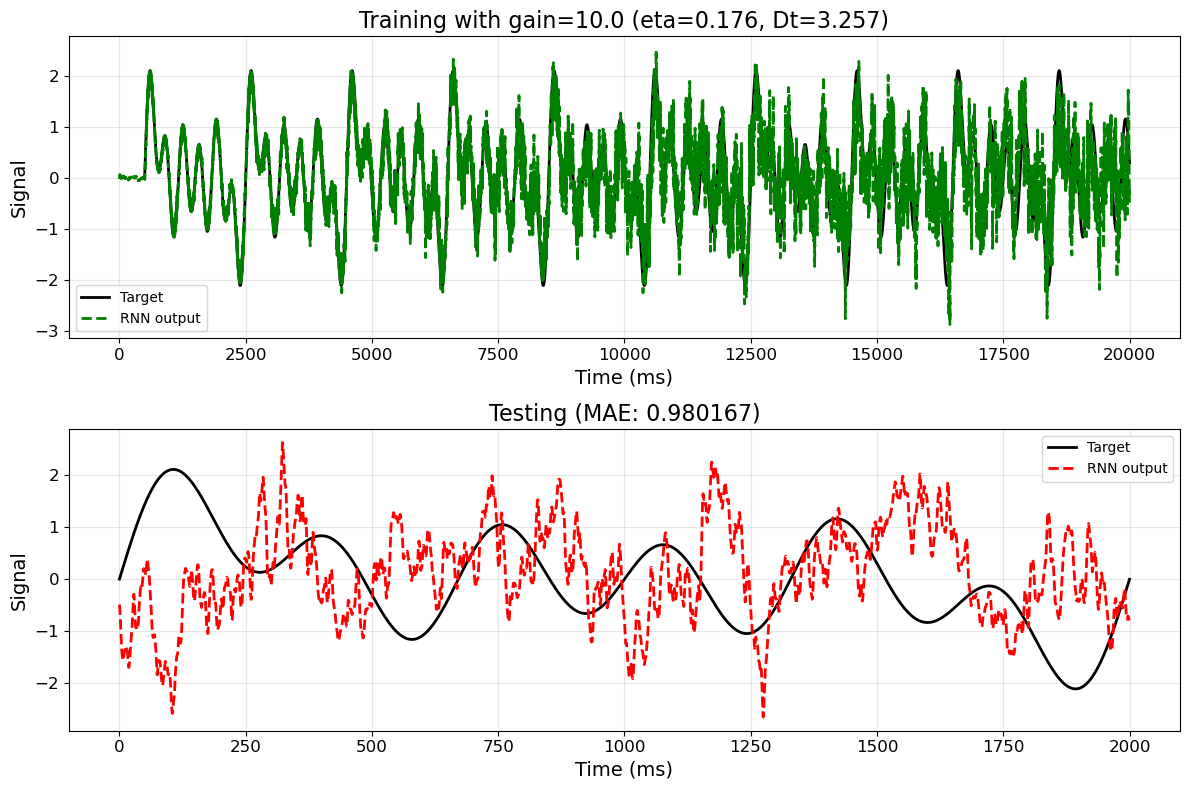

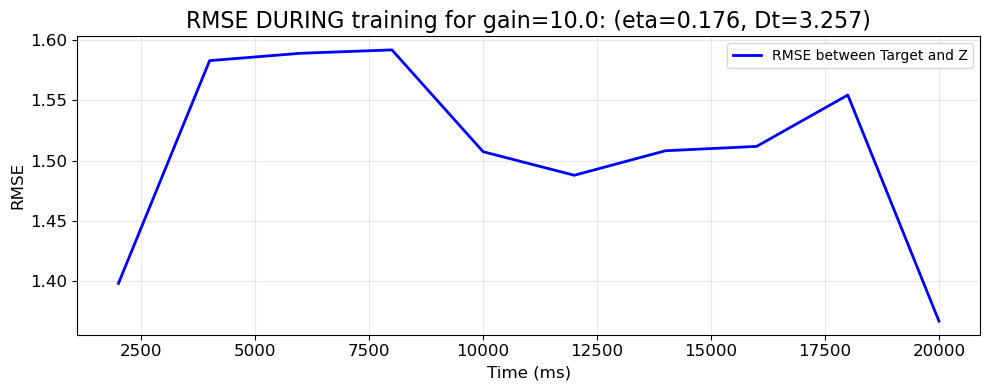

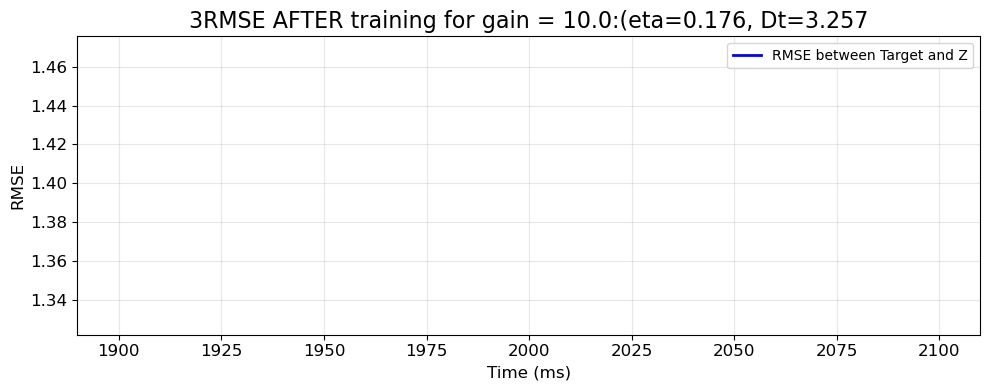

Duration of running:  2396.605 seconds


In [101]:
# Test best configuration
start = time.time()

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14    # x/y labels
plt.rcParams['xtick.labelsize'] = 12   # x ticks
plt.rcParams['ytick.labelsize'] = 12   # y ticks
plt.rcParams['legend.fontsize'] = 10   # legend text
plt.rcParams['figure.titlesize'] = 16  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 14 # legend title

print(results['Etas'][0])

unique_Gains = np.unique(results['Gains'])
print(unique_Gains)

unique_HSMs = np.unique(results['MSHs'])
print(unique_MSHs)

#weights_seeds = np.unique(Weights_Seeds_sorted)

learn_start = 10 ##########################################CHECK THIS#####################################
dt = 0.1
learn_start_idx = int(learn_start / dt) 


# def __init__(self, N=1000, p=1.0, gain=1.5, HSM=0, 
#                  tau=10.0, dt=0.1, Dt=2.0, alpha=10.0, eta=0.1,
#                  weights_seed=1, initialisation_seed=1):

# Loop over all combinations of seeds and gains
for i, gain in enumerate(unique_Gains):

    for i_HSM, HSM in enumerate(unique_HSMs):
        plt.figure(figsize=(10,5))
    
            
        trainer = FORCETrainer(
            N=1000,
            p=1.0,
            gain=gain,
            HSM=HSM,
            #HSM=HSMs_sorted[i],
            tau=10.0,
            dt=0.1,
            Dt=Dts_sorted[i],
            alpha=10,
            eta=Etas_sorted[i],
            weights_seed=Weights_Seeds_sorted[i],
            initialisation_seed=1
        )
        
        ############## Train
        train_time = 20
        running_time = np.arange(0, train_time, 0.1)
        target_train = create_complex_target(running_time, 0.1)
        train_zs = trainer.train(target_train, running_time, verbose=True)
    
            
        target_shifted = np.full_like(target_train, np.nan)
        target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]
    
        
        ############## Test
        after_training_time = 20
        test_time_arr = np.arange(0, after_training_time, 0.1)
        target_test = create_complex_target(test_time_arr, 0.1)
        test_zs = trainer.test(target_test, test_time_arr, verbose=True)
            
        ###############saving it all
    
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
        filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Complex periodic training and testing data" 
        
        # Create the folder if it doesn't exist
        os.makedirs(filepath, exist_ok=True)
        
        # Define filename
        #filename = f"force_best_params_alpha{best_params['alpha']}_Dt{best_params['Dt']}_eta{best_params['eta']}_{timestamp}.npz"
        filename = f"{i}force_best_params_Dt{Dts_sorted[i]:.3f}_eta{Etas_sorted[i]:.3f}_{timestamp}.npz"
        # Combine path and filename
        full_path = os.path.join(filepath, filename)
        
        # Save the data
        np.savez(
        full_path,
        J_initial=trainer.J_initial,
        w_out_initial=trainer.w_out_initial,
        J_trained=trainer.J_trained,
        w_out_trained=trainer.w_out_trained,
        z_out_training=train_zs['all_z_out'],
        z_out_test=test_zs['z_out'],
        running_time=running_time,
        test_time=test_time_arr,
        target_train=target_train,
        target_test=target_test,
        #alpha=best_params['alpha'],
        alpha=trainer.alpha,
        p=trainer.p,
        N=trainer.N,
        gain=gain,
        eta=Etas_sorted[i],
        Dt=Dts_sorted[i],
        # trial_test_maes = best_params['test_mae'],
        # trial_train_maes=best_params['train_mae'],
        mean_test_mae=mean_mae_sorted[i],
        std_test_mae=std_mae_sorted[i]
        )
        
        print(f"✓ Saved to: {full_path}")
    
        #plotting and saving plots of training and testing trajectories
    
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
        # Training
        axes[0].plot(running_time, target_shifted, 'k-', linewidth=2, label='Target')
        axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output', alpha=1)
        # axes[0].set_xlim([0, 10000])
        axes[0].set_xlabel('Time (ms)')
        axes[0].set_ylabel('Signal')
        #axes[0].set_title(f'Training (alpha={best_params["alpha"]:.3f}, eta={best_params["eta"]:.3f}, Dt={best_params["Dt"]:.1f})')
        axes[0].set_title(f'Training with gain={gain} (eta={Etas_sorted[i]:.3f}, Dt={Dts_sorted[i]:.3f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Testing
        axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
        axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output', alpha=1)
        axes[1].set_xlabel('Time (ms)')
        axes[1].set_ylabel('Signal')
        axes[1].set_title(f'Testing (MAE: {mean_mae_sorted[i,0]:.6f})')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
        
        # Save figure
        filename = f"{i}, gain={gain}, time={timestamp}.png"
        
        #change path depending on 10% connectivity or not
        filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\Optimized_zs_vs_target_during_after_FORCE", filename)
        #plt.subplots_adjust(right=0.8) #leaving space for legend
        plt.savefig(filepath, dpi = 300)
        plt.show()
    
        #plottting rmse during and after training
    
            # Parameters
        dt = trainer.dt  # 0.1
        freq = 0.5
        T_period = (1/freq) * 1000  # 1000 because in ms
        steps_per_period = int(T_period / dt)
        total_time_steps = len(running_time)
        
        # Storage for RMSE
        RMSEs = []
        RMSEs_time = []
        
        # Calculate RMSE per period
        for idx in range(0, total_time_steps, steps_per_period):
            # Get data for this period
            time_per_period = running_time[idx:idx+steps_per_period]
            target_per_period = target_train[idx:idx+steps_per_period]
            z_per_period = train_zs['all_z_out'][idx:idx+steps_per_period]
            
            # Only calculate if we have a full period
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                
                # RMSE formula: sqrt(mean(squared_errors))
                sum_SE = ((target_per_period - z_per_period)**2).sum()
                RMSE = np.sqrt(sum_SE / steps_per_period)
                
                RMSEs.append(RMSE)
                RMSEs_time.append(end_time_step)
        
        # Plot RMSE during training
        plt.figure(figsize=(10, 4))
        plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
        plt.xlabel('Time (ms)', fontsize=12)
        plt.ylabel('RMSE', fontsize=12)
        plt.legend()
        plt.title(f'RMSE DURING training for gain={gain}: (eta={Etas_sorted[i]:.3f}, Dt={Dts_sorted[i]:.3f})')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
        
        # Save figure
        filename = f"{i}RMSE_z_vs_target_during_FORCE, gain{gain}, {timestamp}.png"
        
        #change path depending on 10% connectivity or not
        filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE DURING FORCE", filename)
        #plt.subplots_adjust(right=0.8) #leaving space for legend
        plt.savefig(filepath, dpi = 300)
        
        plt.show()
    
    
    
    
        # Parameters
        dt = trainer.dt  # 0.1
        freq = 0.5
        T_period = (1/freq) * 1000  # 1000 because in ms
        steps_per_period = int(T_period / dt)
        total_time_steps = len(test_time_arr)
        
        # Storage for RMSE
        RMSEs = []
        RMSEs_time = []
        
        # Calculate RMSE per period
        for idx in range(0, total_time_steps, steps_per_period):
            # Get data for this period
            time_per_period = running_time[idx:idx+steps_per_period]
            target_per_period = target_train[idx:idx+steps_per_period]
            z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
            
            # Only calculate if we have a full period
            if len(z_per_period) == steps_per_period:
                end_time_step = time_per_period[-1]
                
                # RMSE formula: sqrt(mean(squared_errors))
                sum_SE = ((target_per_period - z_per_period)**2).sum()
                RMSE = np.sqrt(sum_SE / steps_per_period)
                
                RMSEs.append(RMSE)
                RMSEs_time.append(end_time_step)
        
        # Plot RMSE during training
        plt.figure(figsize=(10, 4))
        plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
        plt.xlabel('Time (ms)', fontsize=12)
        plt.ylabel('RMSE', fontsize=12)
        plt.legend()
        plt.title(f'{i}RMSE AFTER training for gain = {gain}:(eta={Etas_sorted[i]:.3f}, Dt={Dts_sorted[i]:.3f}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
        
        # Save figure
        filename = f"{i}RMSE_z_vs_target_after_FORCE, gain{gain}, {timestamp}.png"
        
        #change path depending on 10% connectivity or not
        filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE AFTER FORCE", filename)
        #plt.subplots_adjust(right=0.8) #leaving space for legend
        plt.savefig(filepath, dpi = 300)
        
        plt.show()


end = time.time()
print(f"Duration of running: {end - start: .3f} seconds")

In [226]:
#to access .npz files:import numpy as np

# Load the file
data = np.load('C:python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt19.010_eta0.624_20260122_174845.npz')

# Access individual values
N = data['N']
gain = data['gain']
eta = data['eta']
alpha = data['alpha']
Dt = data['Dt']
tau = data['tau']

print(f"N = {N}")
print(f"gain = {gain}")
print(f"eta = {eta}")
print(f"alpha = {alpha}")
print(f"Dt = {Dt}")
print(f"tau = {tau}")

<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18616\2832940521.py:4: SyntaxWarning: invalid escape sequence '\F'
  data = np.load('C:python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt19.010_eta0.624_20260122_174845.npz')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18616\2832940521.py:4: SyntaxWarning: invalid escape sequence '\F'
  data = np.load('C:python code blocks for MPI4py\FORCE results\Complex periodic training and testing data\2force_best_params_Dt19.010_eta0.624_20260122_174845.npz')


OSError: [Errno 22] Invalid argument: 'C:python code blocks for MPI4py\\FORCE results\\Complex periodic training and testing data\x02force_best_params_Dt19.010_eta0.624_20260122_174845.npz'

### plotting zs vs target during and after training and RMSE during and after training

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Training
axes[0].plot(running_time, target_train, 'k-', linewidth=2, label='Target')
axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output', alpha=1)
# axes[0].set_xlim([0, 10000])
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Signal')
#axes[0].set_title(f'Training (alpha={best_params["alpha"]:.3f}, eta={best_params["eta"]:.3f}, Dt={best_params["Dt"]:.1f})')
axes[0].set_title(f'Training with gain={gain} (eta={best_params["eta"]:.3f}, Dt={Dt})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing
axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output', alpha=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Signal')
axes[1].set_title(f'Testing (MAE: {test_zs["mae"]:.6f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"z_vs_target_during_and_after_FORCE{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\zs_vs_target_during_FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()


In [ ]:

#RMSE during training

# Parameters
dt = trainer.dt  # 0.1
freq = 0.5
T_period = (1/freq) * 1000  # 1000 because in ms
steps_per_period = int(T_period / dt)
total_time_steps = len(running_time)

# Storage for RMSE
RMSEs = []
RMSEs_time = []

# Calculate RMSE per period
for i in range(0, total_time_steps, steps_per_period):
    # Get data for this period
    time_per_period = running_time[i:i+steps_per_period]
    target_per_period = target_train[i:i+steps_per_period]
    z_per_period = train_results['all_z_out'][i:i+steps_per_period]
    
    # Only calculate if we have a full period
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        
        # RMSE formula: sqrt(mean(squared_errors))
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        
        RMSEs.append(RMSE)
        RMSEs_time.append(end_time_step)

# Plot RMSE during training
plt.figure(figsize=(10, 4))
plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.title(f'RMSE DURING training for gain={gain}: (eta={trainer.eta:.3f}, alpha={trainer.alpha:.1f}, Dt={trainer.Dt:.1f}, tau={trainer.tau:.1f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"RMSE_z_vs_target_during_FORCE, gain{gain}, {timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE DURING FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)

plt.show()

In [ ]:

#RMSE after training

# Parameters
dt = trainer.dt  # 0.1
freq = 0.5
T_period = (1/freq) * 1000  # 1000 because in ms
steps_per_period = int(T_period / dt)
total_time_steps = len(running_time)

# Storage for RMSE
RMSEs = []
RMSEs_time = []

# Calculate RMSE per period
for i in range(0, total_time_steps, steps_per_period):
    # Get data for this period
    time_per_period = running_time[i:i+steps_per_period]
    target_per_period = target_train[i:i+steps_per_period]
    z_per_period = test_results['z_out'][i:i+steps_per_period]
    
    # Only calculate if we have a full period
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        
        # RMSE formula: sqrt(mean(squared_errors))
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        
        RMSEs.append(RMSE)
        RMSEs_time.append(end_time_step)

# Plot RMSE during training
plt.figure(figsize=(10, 4))
plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.title(f'RMSE AFTER training for gain = {gain}:(eta={trainer.eta:.3f}, alpha={trainer.alpha:.1f}, Dt={trainer.Dt:.1f}, tau={trainer.tau:.1f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"RMSE_z_vs_target_after_FORCE, gain{gain}, {timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE AFTER FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)

plt.show()


## Analyses of J before and after training

In [ ]:
foldername = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE results\test\Periodic target zs vs target, RMSEs data"

#get all idx*.npz files
files = glob.glob(os.path.join(foldername, "idx*.npz"))

#sorting them by idx number, if necessary
files.sort(key=lambda f: int(os.path.basename(f)[3:6]))

for filepath in files:
    for i in range(66):
    
        data = np.load(filepath)
        J_initial = data['J_initial']
        J_trained = data['J_trained']
        w_out_initial = data['w_out_initial']
        w_out_trained = data['w_out_trained']
    
        # print(filepath, J_initial, J_initial.shape)
        # print(filepath, J_trained, J_initial.shape)
        # print(filepath, w_out_initial, w_out_initial.shape)
        # print(filepath, w_out_trained, w_out_trained.shape)
    
        mus_initial    = np.mean(J_initial, axis=1)
        sigmas_initial = np.std(J_initial, axis=1)
        
        mus_trained    = np.mean(J_trained, axis=1)
        sigmas_trained = np.std(J_trained, axis=1)
        
        mus_difference    = mus_trained - mus_initial
        sigmas_difference = sigmas_trained - sigmas_initial
                
        neuron_lin = np.linspace(1, 1000, 1000)
        
        ############## Plotting 
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        
        # initial
        axes[0].plot(neuron_lin, mus_initial, 'o', linewidth=2, label='Target')
        axes[0].set_xlabel('# of Neuron')
        axes[0].set_ylabel('Mean (mu)')
        axes[0].set_title(f'mus initial')
        #axes[0].set_title(f'Training: gain={gain:.1f}, MSH={MSH:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # after training
        axes[1].plot(neuron_lin, mus_trained, 'o', linewidth=2, label='Target')
        axes[1].set_xlabel('# of Neuron')
        axes[1].set_ylabel('Mean (mu)')
        axes[1].set_title(f'mus trained')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
        # Difference
        axes[2].plot(neuron_lin, mus_difference, 'k-', linewidth=2, label='Target')
        axes[2].set_xlabel('# of Neuron')
        axes[2].set_ylabel('shift in mean')
        axes[1].set_title(f'mus difference')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        #fig_filename = f"idx{i:03d}_trajectories_gain{gain:.1f}_MSH{MSH:.1f}_{timestamp}.png"
        fig_filename = f"idx{i:03d}.png"
        #######################CHECK THIS FILE PATH############################
        fig_filepath = os.path.join(
            r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\FORCE\FORCE figures\Gains HSM plots\Gain HSM J matrix plots",
            fig_filename
        )
        plt.savefig(fig_filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
    

print(f"Loaded {len(rmses)} configurations")
print(f"Gains: {np.unique(gains)}")
print(f"MSHs: {np.unique(MSHs)}")

In [ ]:
J_initial = trainer.J_initial
print(J_initial.shape)
w_out_initial = trainer.w_out_initial
print(w_out_initial.shape)

In [ ]:
#plt.hist(masked_Ws, bins = 1000, alpha = 0.7, edgecolor = "black")

mus_neurons = []
sigmas_neurons = []
for i in tqdm(range(0,1000,10)):
    mean_neuron = np.mean(J_trained[i,:])
    std_neuron = np.std(J_trained[i,:])

    mus_neurons.append(mean_neuron)
    sigmas_neurons.append(std_neuron)
    
    plt.hist(J_trained[i,:].ravel(), bins = 100, alpha = 0.7, edgecolor = "tab:blue")#.ravel() flattens the 2D Ws[i,:,:] to an 1D array so it can plot all the values in the histogram
    plt.title(f"Presynaptic weights distribution to neuron {i} with mu {mean_neuron} and sigma {std_neuron}")
    plt.show()

mus_neurons = np.array(mus_neurons)
sigmas_neurons = np.array(sigmas_neurons)

In [ ]:
#plt.hist(masked_Ws, bins = 1000, alpha = 0.7, edgecolor = "black")

mus_neurons = []
sigmas_neurons = []
for i in tqdm(range(1000)):
    mean_neuron = np.mean(J_trained[i,:])
    std_neuron = np.std(J_trained[i,:])

    mus_neurons.append(mean_neuron)
    sigmas_neurons.append(std_neuron)
    
    # plt.hist(J[i,:].ravel(), bins = 100, alpha = 0.7, edgecolor = "tab:blue")#.ravel() flattens the 2D Ws[i,:,:] to an 1D array so it can plot all the values in the histogram
    # plt.title(f"Presynaptic weights distribution to neuron {i} with mu {mean_neuron} and sigma {std_neuron}")
    # plt.show()

mus_neurons = np.array(mus_neurons)
sigmas_neurons = np.array(sigmas_neurons)

In [ ]:
mus_neurons = np.array(mus_neurons)

mean_mus = np.mean(mus_neurons)
sigma_mus = np.std(mus_neurons)

plt.hist(mus_neurons.ravel(), bins = 100, alpha = 0.7, color = "tab:red", edgecolor = "tab:red");
plt.title(f"Presynaptic weights Means distribution to all neurons, with mean {mean_mus}, and sigma {sigma_mus}")

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"Mus_distribution_J_trained{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\Distribution of mus for J_trained", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()


In [ ]:
sigmas_neurons = np.array(sigmas_neurons)

mean_sigmas = np.mean(sigmas_neurons)
sigma_sigmas = np.std(sigmas_neurons)

plt.hist(sigmas_neurons.ravel(), bins = 100, alpha = 0.7, color = "black", edgecolor = "black");
plt.title(f"Presynaptic weights Sigmas distribution for all neurons, with mean {mean_sigmas}, and sigma {sigma_sigmas}")


timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"Sigmas_distribution_J_trained{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\Distribution of sigmas for J_trained", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()


# Execution cells for hyperparameter optimization for different targets **on this computer**

In [176]:
#random search
start = time.time()

gain = 1.5

print("\n--- RANDOM SEARCH EXAMPLE ---")
param_ranges = {
    'eta': (0.01, 1),
    #'alpha': (1.0, 50.0),
    'Dt': (0.5, 20.0),
    #'tau': (0.1, 30.0)
}

random_results = random_search(
    param_ranges,
    gain = gain,
    n_iterations=10,  # Try 20 random configurations
    n_trials=1, #number of seeds it will try, but I am only interested in one seed for now so one trial
    train_time=1000,
    test_time=100,
    verbose=True
)

print("\n" + "="*60)
print(f"TOP 5 CONFIGURATIONS for gain={gain}:")
print("="*60)
for i, result in enumerate(random_results[:5]):
    print(f"  eta={result['eta']:.4f}, Dt={result['Dt']:.4f}")
    #print(f"  eta={result['eta']:.4f}, Dt={result['Dt']:.4f}, alpha={result['alpha']:.4f}, tau={result['tau']:.4f} ")
    print(f"  Test MAE: {result['mean_test_mae']:.6f} ± {result['std_test_mae']:.6f}")
    print(f"  Train MAE: {result['mean_train_mae']:.6f}")


end = time.time()
print(f"Duration of running: {end - start: .3f} seconds")


--- RANDOM SEARCH EXAMPLE ---

Iteration 1/10: {'eta': 0.3289678585253949, 'Dt': 9.77006572242783}
  Trial 1/1: Train MAE=0.442562, Test MAE=0.824235
  Average: Train=0.442562, Test=0.824235 ± 0.000000

Iteration 2/10: {'eta': 0.2911055456680692, 'Dt': 1.0087408247282956}
  Trial 1/1: Train MAE=0.436517, Test MAE=0.861255
  Average: Train=0.436517, Test=0.861255 ± 0.000000

Iteration 3/10: {'eta': 0.9286337431792171, 'Dt': 0.616503185142282}
  Trial 1/1: Train MAE=0.436138, Test MAE=1.174767
  Average: Train=0.436138, Test=1.174767 ± 0.000000

Iteration 4/10: {'eta': 0.31030232669540947, 'Dt': 2.6107880115009667}
  Trial 1/1: Train MAE=0.437777, Test MAE=0.845717
  Average: Train=0.437777, Test=0.845717 ± 0.000000

Iteration 5/10: {'eta': 0.15103595509303114, 'Dt': 1.0327302639900842}
  Trial 1/1: Train MAE=0.436159, Test MAE=0.857925
  Average: Train=0.436159, Test=0.857925 ± 0.000000

Iteration 6/10: {'eta': 0.19999661014292075, 'Dt': 4.81328371312617}
  Trial 1/1: Train MAE=0.43912

In [134]:
# Test best configuration
start = time.time()

print("\n" + "="*60)
print("TESTING BEST CONFIGURATION")
print("="*60)
best_params = random_results[0]

gain=1.5

trainer = FORCETrainer(
    N=1000,
    p=1.0,
    gain=gain,
    tau=10.0,
    dt=0.1,
    #Dt = 20,
    Dt=best_params['Dt'],
    #alpha=best_params['alpha'],
    eta=best_params['eta'],
    weights_seed=1,
    initialisation_seed=1
)

# Train
train_time = 50000
running_time = np.arange(0, train_time, 0.1)
target_train = create_complex_target(running_time, 0.1)
train_zs = trainer.train(target_train, running_time, verbose=True)

# Test
test_time_arr = np.arange(0, 10000, 0.1)
target_test = create_complex_target(test_time_arr, 0.1)
test_zs = trainer.test(target_test, test_time_arr, verbose=True)


end = time.time()
print(f"Duration of running: {end - start: .3f} seconds")


TESTING BEST CONFIGURATION


100%|██████████| 100000/100000 [00:30<00:00, 3274.96it/s]

Duration of running:  249.473 seconds


In [180]:
#saving best params

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

filepath = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Best params for specific targets" 

# Create the folder if it doesn't exist
os.makedirs(filepath, exist_ok=True)



# Define filename
#filename = f"force_best_params_alpha{best_params['alpha']}_Dt{best_params['Dt']}_eta{best_params['eta']}_{timestamp}.npz"
filename = f"force_best_params_Dt{best_params['Dt']:.3f}_eta{best_params['eta']:.3f}_{timestamp}.npz"
# Combine path and filename
full_path = os.path.join(filepath, filename)

best_params = random_results[0]

# Save the data
np.savez(
    full_path,
    J_initial=trainer.J_initial,
    w_out_initial=trainer.w_out_initial,
    J_trained=trainer.J_trained,
    w_out_trained=trainer.w_out_trained,
    z_out_training=train_zs['all_z_out'],
    z_out_test=test_zs['z_out'],
    running_time=running_time,
    test_time=test_time_arr,
    target_train=target_train,
    target_test=target_test,
    #alpha=best_params['alpha'],
    alpha=trainer.alpha,
    p=trainer.p,
    N=trainer.N,
    gain=gain,
    eta=best_params['eta'],
    Dt=best_params['Dt'],
    trial_test_maes = best_params['test_maes'], #I do not even need this because it prints already maus per trial and iteration in the output.log in TR1
    trial_train_maes=best_params['train_maes'],
    mean_test_mae=best_params['mean_test_mae'],
    std_test_mae=best_params['std_test_mae']
)

print(f"✓ Saved to: {full_path}")

✓ Saved to: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\python code blocks for MPI4py\FORCE results\Best params for specific targets\force_best_params_Dt0.626_eta0.583_20260122_160455.npz


In [192]:
#to access .npz files:import numpy as np

# Load the file
data = np.load("python code blocks for MPI4py/FORCE results/Best params for specific targets/force_best_params_Dt0.626_eta0.583_20260122_160455.npz")

# Access individual values
N = data['N']
gain = data['gain']
eta = data['eta']
alpha = data['alpha']
Dt = data['Dt']
trial_test_maes = data['trial_test_maes']
trial_train_maes = data['trial_train_maes']

print(f"N = {N}")
print(f"gain = {gain}")
print(f"eta = {eta}")
print(f"alpha = {alpha}")
print(f"Dt = {Dt}")
print(f"trial_test_maes={trial_test_maes}")
print(f"trial_train_maes={trial_train_maes}")

N = 1000
gain = 1.5
eta = 0.3289678585253949
alpha = 10.0
Dt = 9.77006572242783
trial_test_maes=[0.82423466]
trial_train_maes=[0.44256195]


## plotting results

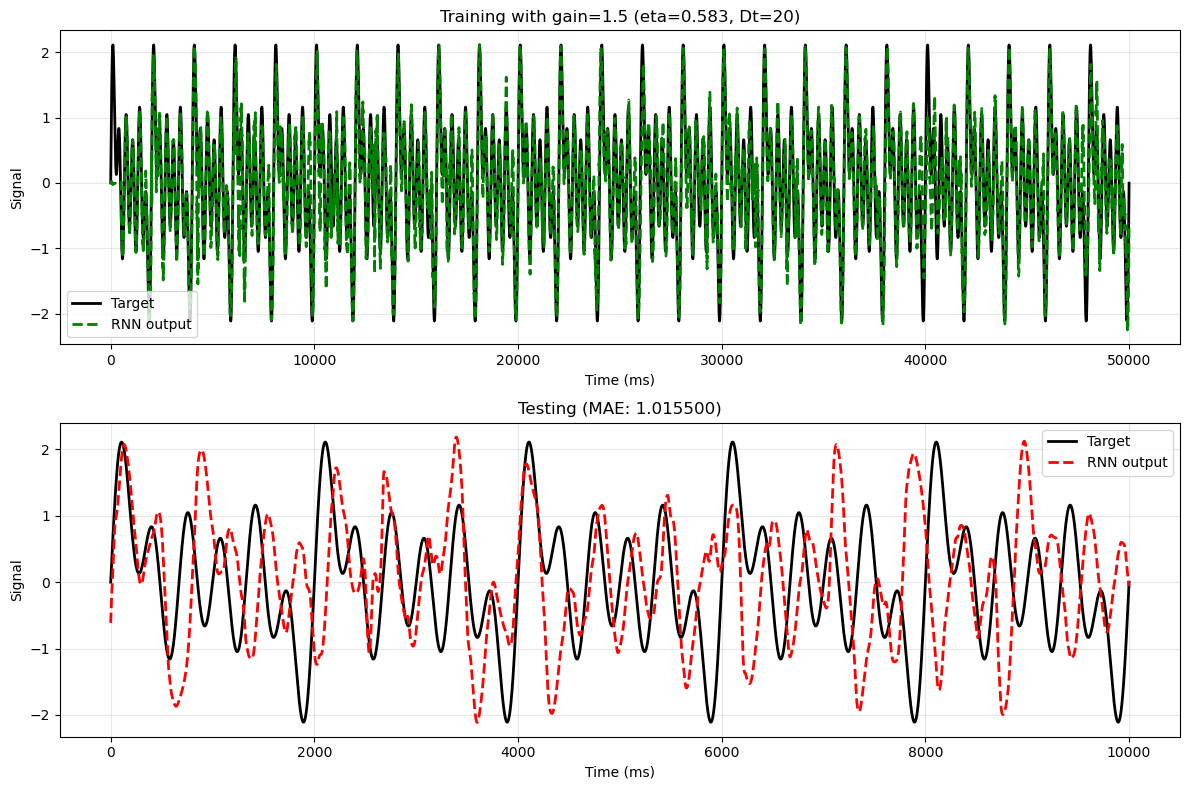

In [136]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
Dt=20
# Training
axes[0].plot(running_time, target_train, 'k-', linewidth=2, label='Target')
axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output', alpha=1)
# axes[0].set_xlim([0, 10000])
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Signal')
#axes[0].set_title(f'Training (alpha={best_params["alpha"]:.3f}, eta={best_params["eta"]:.3f}, Dt={best_params["Dt"]:.1f})')
axes[0].set_title(f'Training with gain={gain} (eta={best_params["eta"]:.3f}, Dt={Dt})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Testing
axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output', alpha=1)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Signal')
axes[1].set_title(f'Testing (MAE: {test_zs["mae"]:.6f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"z_vs_target_during_and_after_FORCE{timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\zs_vs_target_during_FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)
plt.show()



In [ ]:

# Parameters
dt = trainer.dt  # 0.1
freq = 0.5
T_period = (1/freq) * 1000  # 1000 because in ms
steps_per_period = int(T_period / dt)
total_time_steps = len(running_time)

# Storage for RMSE
RMSEs = []
RMSEs_time = []

# Calculate RMSE per period
for i in range(0, total_time_steps, steps_per_period):
    # Get data for this period
    time_per_period = running_time[i:i+steps_per_period]
    target_per_period = target_train[i:i+steps_per_period]
    z_per_period = train_results['all_z_out'][i:i+steps_per_period]
    
    # Only calculate if we have a full period
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        
        # RMSE formula: sqrt(mean(squared_errors))
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        
        RMSEs.append(RMSE)
        RMSEs_time.append(end_time_step)

# Plot RMSE during training
plt.figure(figsize=(10, 4))
plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.title(f'RMSE DURING training for gain={gain}: (eta={trainer.eta:.3f}, alpha={trainer.alpha:.1f}, Dt={trainer.Dt:.1f}, tau={trainer.tau:.1f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"RMSE_z_vs_target_during_FORCE, gain{gain}, {timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE DURING FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)

plt.show()

In [ ]:

# Parameters
dt = trainer.dt  # 0.1
freq = 0.5
T_period = (1/freq) * 1000  # 1000 because in ms
steps_per_period = int(T_period / dt)
total_time_steps = len(running_time)

# Storage for RMSE
RMSEs = []
RMSEs_time = []

# Calculate RMSE per period
for i in range(0, total_time_steps, steps_per_period):
    # Get data for this period
    time_per_period = running_time[i:i+steps_per_period]
    target_per_period = target_train[i:i+steps_per_period]
    z_per_period = test_results['z_out'][i:i+steps_per_period]
    
    # Only calculate if we have a full period
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        
        # RMSE formula: sqrt(mean(squared_errors))
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        
        RMSEs.append(RMSE)
        RMSEs_time.append(end_time_step)

# Plot RMSE during training
plt.figure(figsize=(10, 4))
plt.plot(RMSEs_time, RMSEs, 'b-', linewidth=2, label='RMSE between Target and Z')
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.title(f'RMSE AFTER training for gain = {gain}:(eta={trainer.eta:.3f}, alpha={trainer.alpha:.1f}, Dt={trainer.Dt:.1f}, tau={trainer.tau:.1f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

# Save figure
filename = f"RMSE_z_vs_target_after_FORCE, gain{gain}, {timestamp}.png"

#change path depending on 10% connectivity or not
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\figures\RMSE AFTER FORCE", filename)
#plt.subplots_adjust(right=0.8) #leaving space for legend
plt.savefig(filepath, dpi = 300)

plt.show()


In [ ]:

# Step 1: Find all result files
files = sorted(glob.glob("python code blocks for MPI4py/FORCE_complex_periodic_1seed_W_and_Init/FORCE_complex_periodic_1seed_W_and_Init*.npz"))

Etas_sorted, Dts_sorted, Gains_sorted, mean_mae_sorted, std_mae_sorted, Weights_Seeds_sorted = gains_combined_sorted_FORCE_optimized(files)

#checking dimensions

print(f"{Weights_Seeds_sorted}, shape weights_seed: {Weights_Seeds_sorted.shape}")
print(f"{Etas_sorted}, shape of etas: {Etas_sorted.shape}")
print(f" {Dts_sorted}, shape of Dts: {Dts_sorted.shape}")
print(f"{Gains_sorted}, shape of Gains: {Gains_sorted.shape}")
print(f"{mean_mae_sorted}, shape of mean_mae: {mean_mae_sorted.shape}")
print(f"{std_mae_sorted}, shape of std_mae: {std_mae_sorted.shape}")

for i,Dt in enumerate(Dts_sorted):
    print(Dts_sorted[i])
    print(Dt)

for i,value in enumerate(mean_mae_sorted): 
    print(f'Testing (MAE: {mean_mae_sorted[i,0]:.6f})')

## OLD code

In [ ]:
##TESTING for particular cases

# Test best configuration
start = time.time()

Dt = 2
eta = 10
MSH = 0
gain = 10
dt = 0.1




freq = 0.5 #######################CHECK THIS############################
T_period = (1/freq) * 1000  # #######################CHECK THIS############################
steps_per_period = int(T_period / dt)  # 20000 steps

# Storage for first-period test RMSEs (across all configurations)
all_first_period_test_rmse = []

# Loop over all entries (each entry is a unique gain/MSH/seed combination)


print(f"\n{'='*60}")
print(f"Processing configuration {i+1}/{len(Etas)}")
print(f"  gain={gain:.1f}, MSH={MSH:.1f}, seed={weights_seed}")
print(f"  eta={eta:.4f}, Dt={Dt:.1f}")
print(f"  Expected MAE: {mean_mae:.6f}")
print(f"{'='*60}")

# Create trainer with parameters from this configuration
trainer = FORCETrainer(
    N=1000,
    p=1.0,
    gain=gain,
    HSM=MSH,
    tau=10.0,
    dt=dt,
    Dt=Dt,
    alpha=10,
    eta=eta,
    weights_seed=weights_seed,
    initialisation_seed=1
)

#Train
train_time = 4000 + learn_start  #######################CHECK THIS############################
running_time = np.arange(0, train_time, dt)
target_train = create_complex_target(running_time, dt)
train_zs = trainer.train(target_train, running_time, verbose=False)

# Shift target for plotting
target_shifted = np.full_like(target_train, np.nan)
target_shifted[learn_start_idx:] = target_train[:-learn_start_idx]

#Test
after_training_time = 1440  # Can be changed to 4000, 6000, etc. #######################CHECK THIS############################
test_time_arr = np.arange(0, after_training_time, dt)
target_test = create_complex_target(test_time_arr, dt)
test_zs = trainer.test(target_test, test_time_arr, verbose=False)

############## Plotting training and testing trajectories
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Training
axes[0].plot(running_time, target_shifted, 'k-', linewidth=2, label='Target')
axes[0].plot(running_time, train_zs['all_z_out'], 'g--', linewidth=2, label='RNN output')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Signal')
axes[0].set_title(f'Training: gain={gain:.1f}, MSH={MSH:.1f} (η={eta:.3f}, Δt={Dt:.1f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


RMSEs_test = []
RMSEs_time_test = []

for idx in range(0, len(test_time_arr), steps_per_period):
    time_per_period = test_time_arr[idx:idx+steps_per_period]
    target_per_period = target_test[idx:idx+steps_per_period]
    z_per_period = test_zs['z_out'][idx:idx+steps_per_period]
    
    if len(z_per_period) == steps_per_period:
        end_time_step = time_per_period[-1]
        sum_SE = ((target_per_period - z_per_period)**2).sum()
        RMSE = np.sqrt(sum_SE / steps_per_period)
        RMSEs_test.append(RMSE)
        RMSEs_time_test.append(end_time_step)


# Testing
axes[1].plot(test_time_arr, target_test, 'k-', linewidth=2, label='Target')
axes[1].plot(test_time_arr, test_zs['z_out'], 'r--', linewidth=2, label='RNN output')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Signal')
axes[1].set_title(f'Testing (1st period RMSE: {RMSEs_time_test[0]:.6f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


end = time.time()
print(f"\nTotal duration: {end - start:.3f} seconds")
print(f"Processed {len(Etas)} configurations")

